# belief eye neural analysis


## imports

In [ ]:
%reload_ext autoreload
%autoreload 2
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
# misc
import pickle
from collections import defaultdict
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

## load standard data


In [6]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [7]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [8]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [9]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [10]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

In [11]:
timedf.columns                                                           

Index(['timer', 'rawcov', 'belief', 'state', 'eye', 'timeratio', 'mv', 'mw',
       'belief_heading', 'countdown', 'belief_angle_from_start', 'PPC',
       'uncertainty', 'density', 'fullon', 'error', 'dbelief', 'deye',
       'dneural'],
      dtype='object')

## load iti data

In [12]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [13]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# Regression and residual regression

## binning by time (time ratio) and space (abs diff, diff in derivative)

Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,), TimeRatio=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,), TimeRatio=(399510,)

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Time-Binned Analysis Comparison (50 bins) ---

Processing Bin 1/50 (TimeRatio: 0.00 to 0.02)...
  Samples in bin: 9346
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.3592, p=1.03e-282
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson r (Independent): 0.3589, p=4.42e-282

Processing Bin 2/50

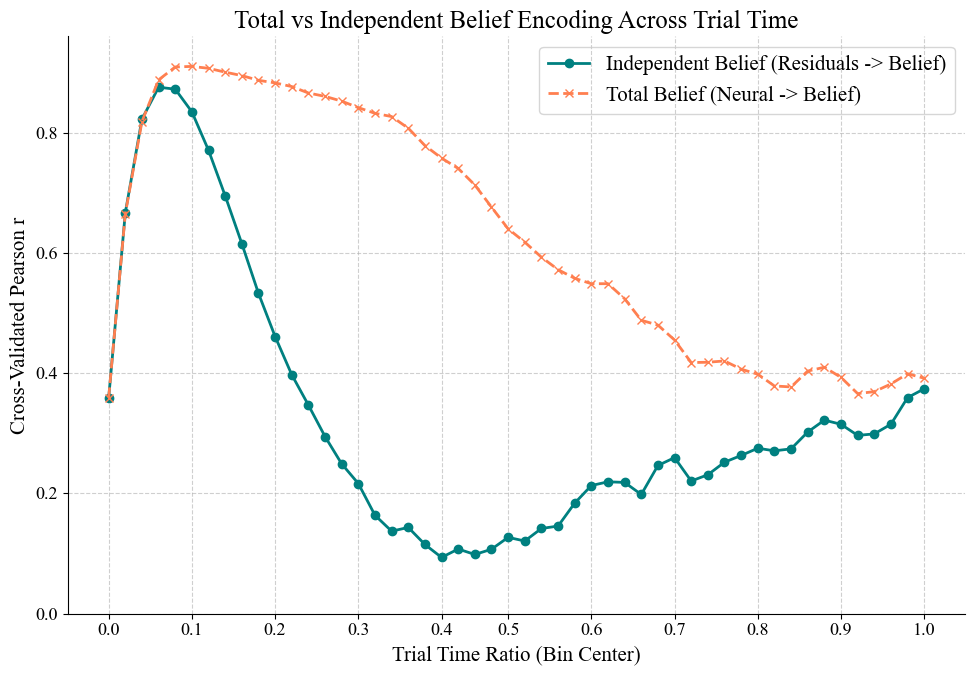


Time-Binned Comparison Analysis Complete.


In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', 'eye', and 'timeratio'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Need more samples for binning
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     samples_per_trial = 100
     n_trials = n_samples_orig // samples_per_trial
     n_samples_orig = n_trials * samples_per_trial # Adjust total samples
     timeratio_signal = np.tile(np.linspace(0, 1, samples_per_trial, endpoint=False), n_trials)

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     correlation_factor = 0.3 + 0.4 * np.sin(timeratio_signal * np.pi)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated,
         'timeratio': timeratio_signal
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_time_bins = 50 # Number of bins for timeratio (Adjust if needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    timeratio_raw = timedf['timeratio'].to_numpy() # Extract timeratio
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}, TimeRatio={timeratio_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0] == timeratio_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, eye, or timeratio data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye', and 'timeratio' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]
timeratio_present = timeratio_raw[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}, TimeRatio={timeratio_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Time-Binned Analysis Comparison
# =============================================================================
print(f"\n--- Time-Binned Analysis Comparison ({n_time_bins} bins) ---")

# Define time bins
bin_edges = np.linspace(0, 1, n_time_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_time_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    is_last_bin = (i == n_time_bins - 1)
    if is_last_bin:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present <= bin_end)
    else:
        bin_mask = (timeratio_present >= bin_start) & (timeratio_present < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_time_bins} (TimeRatio: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin, p_total_bin = np.nan, np.nan
    else:
        r_total_bin, p_total_bin = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}, p={p_total_bin:.2e}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    # a. Get CV predictions for Neural ~ Eye within bin
    predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
    # b. Calculate Residuals within bin
    residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
    # c. Get CV predictions for Belief ~ Residuals within bin
    predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
    # d. Evaluate Belief prediction for this bin
    valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
    if np.sum(valid_indices_independent) < 2:
        r_independent_bin, p_independent_bin = np.nan, np.nan
    else:
        r_independent_bin, p_independent_bin = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])
    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}, p={p_independent_bin:.2e}")
    results_r_independent.append(r_independent_bin)

    # Store bin center if calculations were successful
    actual_bin_centers.append(bin_centers[i])


# =============================================================================
# Plotting the Time-Binned Comparison
# =============================================================================
print("\n--- Plotting Time-Binned Comparison ---")
fig_timebin_comp, ax_timebin_comp = plt.subplots(figsize=(10, 7)) # Slightly wider plot

# Filter out NaN results if bins were skipped
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total) # Ensure both are valid
plot_centers = np.array(actual_bin_centers)
plot_r_independent = np.array(results_r_independent)[valid_results_mask]
plot_r_total = np.array(results_r_total)[valid_results_mask]

if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_timebin_comp.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(results_r_independent) - 0.05, np.nanmin(results_r_total) - 0.05)
    max_y = max(0.1, np.nanmax(results_r_independent) + 0.05, np.nanmax(results_r_total) + 0.05)
    ax_timebin_comp.set_ylim(bottom=min_y, top=max_y)
    ax_timebin_comp.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_timebin_comp.axhline(0, color='black', linewidth=0.5, linestyle='--')
    # Set x-ticks to be bin centers (maybe fewer ticks if too cluttered)
    tick_indices = np.round(np.linspace(0, len(bin_centers)-1, 11)).astype(int) # Show ~11 ticks
    ax_timebin_comp.set_xticks(bin_centers[tick_indices])
    ax_timebin_comp.set_xticklabels([f"{c:.1f}" for c in bin_centers[tick_indices]])
    ax_timebin_comp.legend()

else:
    ax_timebin_comp.text(0.5, 0.5, 'No valid data bins found for plotting.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_timebin_comp.transAxes)
    ax_timebin_comp.set_xlabel('Trial Time Ratio (Bin Center)')
    ax_timebin_comp.set_ylabel('Cross-Validated Pearson r')
    ax_timebin_comp.set_title('Total vs Independent Belief Encoding Across Trial Time')


plt.tight_layout()
plt.show()

print("\nTime-Binned Comparison Analysis Complete.")


Using provided 'timedf' DataFrame.
--- Extracting Raw Data from DataFrame ---
Initial shapes: Neural=(400117, 112), Belief=(400117,), Eye=(400117,)

--- Normalizing Behavioral Data (Globally) ---

--- Removing Outliers (Threshold: +/- 4 std dev for Belief & Eye) ---
Removed 607 outlier trials/samples (0.15%).
Data shape after cleaning: Neural=(399510, 112), Belief=(399510,), Eye=(399510,)

--- Calculating Absolute Belief-Eye Difference ---
  Range of difference: 0.00 to 5.53

--- Applying Gaussian Smoothing (sigma = 5 samples) ---
Gaussian smoothing complete.
Z-scoring smoothed data per channel (Globally)...
Z-scoring complete.
Processed neural data shape: (399510, 112)

--- Belief-Eye Difference Binned Analysis Comparison (20 bins) ---

Processing Bin 1/20 (Belief-Eye Diff: 0.00 to 0.28)...
  Samples in bin: 110931
  Calculating Total Belief Encoding (Neural -> Belief)...
    CV Pearson r (Total): 0.5937
  Calculating Independent Belief Encoding (Residuals -> Belief)...
    CV Pearson

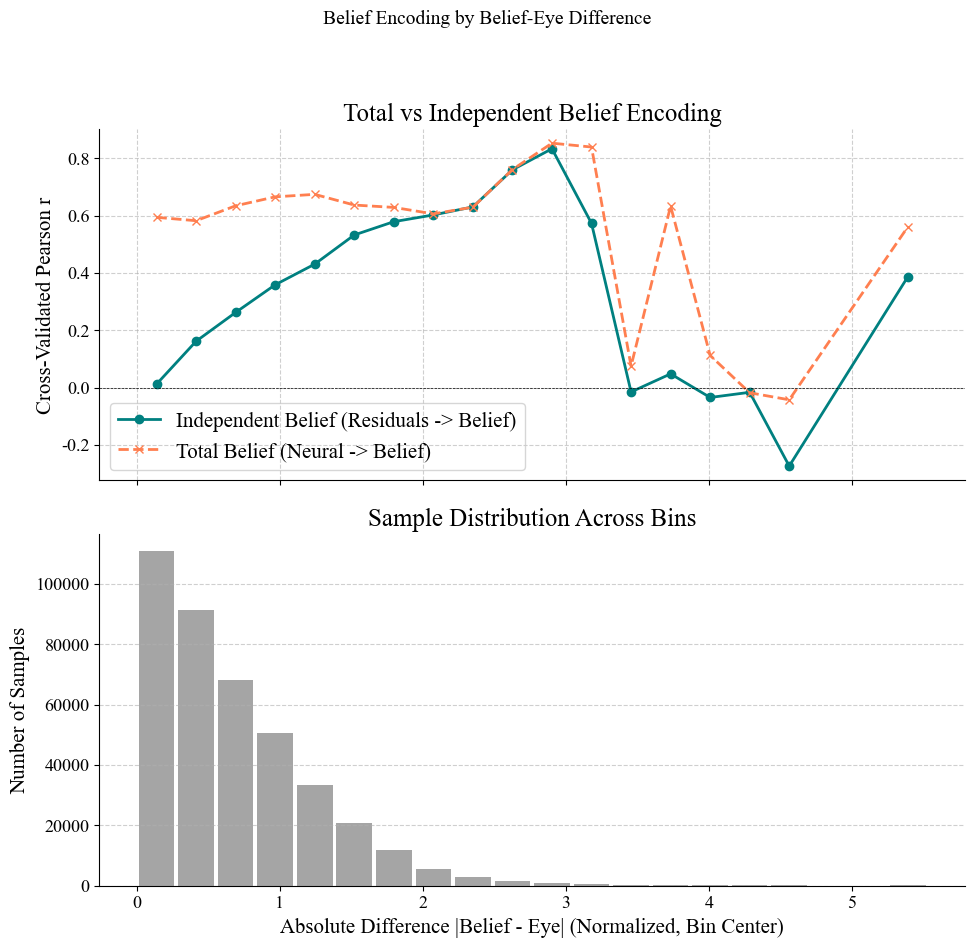


Belief-Eye Difference Binned Analysis Complete.


In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d # For Gaussian smoothing

# --- Load Your Actual Data ---
# Assume 'timedf' is a pandas DataFrame already loaded in your environment
# It should contain columns like 'PPC', 'belief', and 'eye'.

# Example check (replace with your actual DataFrame name if different)
if 'timedf' not in locals():
     # Try to load placeholder if actual data not found
     print("Warning: DataFrame 'timedf' not found. Using placeholder data.")
     # --- Placeholder Data (REPLACE WITH YOUR ACTUAL DATA LOADING) ---
     rng = np.random.default_rng(42)
     n_samples_orig = 50000 # Use a decent number of samples
     n_features = 50      # Number of channels/neurons
     sampling_rate = 166 # Hz

     belief_signal_true = normalize_z(rng.random(n_samples_orig) * 10)
     eye_signal_true = normalize_z(rng.random(n_samples_orig) * 5)
     # Simulate varying correlation - let's make it random per sample for simplicity here
     correlation_factor = rng.uniform(0.1, 0.8, n_samples_orig)
     belief_signal_correlated = normalize_z( (1-correlation_factor) * belief_signal_true + correlation_factor * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))
     eye_signal_correlated = normalize_z( correlation_factor * belief_signal_true + (1-correlation_factor) * eye_signal_true + rng.normal(0, 0.5, n_samples_orig))

     voltage_noise = rng.normal(0, 1.0, (n_samples_orig, n_features))
     belief_mod = belief_signal_correlated[:, np.newaxis] * 0.1
     eye_mod = eye_signal_correlated[:, np.newaxis] * 0.3
     neural_data_raw_voltage_sim = voltage_noise + belief_mod + eye_mod

     timedf = pd.DataFrame({
         'PPC': list(neural_data_raw_voltage_sim),
         'belief': belief_signal_correlated,
         'eye': eye_signal_correlated
         # No timeratio needed for this version
     })
     # --- End Placeholder Data ---
else:
    print("Using provided 'timedf' DataFrame.")


# --- Parameters ---
sampling_rate = 166 # Hz - IMPORTANT: Set this to your actual sampling rate
outlier_threshold_std = 4 # Z-score threshold for removing outliers
gaussian_sigma_samples = 5 # Std deviation of Gaussian kernel in SAMPLES
n_diff_bins = 20 # Number of bins for belief-eye difference (Adjust as needed)
min_samples_per_bin = 50 # Minimum samples required in a bin for analysis

# --- Extract Raw Data ---
print("--- Extracting Raw Data from DataFrame ---")
try:
    neural_data_raw_voltage = np.stack(timedf['PPC'].to_numpy())
    belief_data_present_raw = timedf['belief'].to_numpy()
    eye_data_present_raw = timedf['eye'].to_numpy()
    print(f"Initial shapes: Neural={neural_data_raw_voltage.shape}, Belief={belief_data_present_raw.shape}, Eye={eye_data_present_raw.shape}")

    if not (neural_data_raw_voltage.shape[0] == belief_data_present_raw.shape[0] == eye_data_present_raw.shape[0]):
        raise ValueError("Mismatch in number of samples between neural ('PPC'), belief, or eye data.")

except KeyError as e:
    raise KeyError(f"Column not found in timedf: {e}. Ensure columns 'PPC', 'belief', 'eye' exist.")
except Exception as e:
    raise TypeError(f"Error processing data columns. Ensure they contain stackable numerical data. Error: {e}")


# --- Helper function for Z-scoring ---
def normalize_z(data):
    """Applies z-score normalization to a 1D array."""
    if isinstance(data, pd.Series):
        data = data.to_numpy()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0) # Replace NaN/Inf with 0 before scaling
    scaler = StandardScaler()
    if np.std(data) < 1e-9:
        print("Warning: Standard deviation is zero during normalization. Returning zeros.")
        return np.zeros_like(data)
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

# --- Normalize Behavioral Data Globally ---
print("\n--- Normalizing Behavioral Data (Globally) ---")
belief_data_normalized = normalize_z(belief_data_present_raw)
eye_data_normalized = normalize_z(eye_data_present_raw)

# --- Outlier Removal (Based on Normalized Belief & Eye) ---
print(f"\n--- Removing Outliers (Threshold: +/- {outlier_threshold_std} std dev for Belief & Eye) ---")
task_vars_normalized = np.vstack([belief_data_normalized, eye_data_normalized]).T
mask_outliers = (np.abs(task_vars_normalized) < outlier_threshold_std).all(axis=1)

# Apply mask to all data types that need to stay aligned
neural_data_raw_voltage_cleaned = neural_data_raw_voltage[mask_outliers, :]
belief_data_present = belief_data_normalized[mask_outliers]
eye_data_present = eye_data_normalized[mask_outliers]

n_removed = len(belief_data_present_raw) - len(belief_data_present)
print(f"Removed {n_removed} outlier trials/samples ({n_removed / len(belief_data_present_raw) * 100:.2f}%).")
print(f"Data shape after cleaning: Neural={neural_data_raw_voltage_cleaned.shape}, Belief={belief_data_present.shape}, Eye={eye_data_present.shape}")

if len(belief_data_present) == 0:
    raise ValueError("All data removed as outliers. Check data or threshold.")

# =============================================================================
# Calculate Belief-Eye Difference
# =============================================================================
print("\n--- Calculating Absolute Belief-Eye Difference ---")
belief_eye_diff = np.abs(belief_data_present - eye_data_present)
print(f"  Range of difference: {np.min(belief_eye_diff):.2f} to {np.max(belief_eye_diff):.2f}")

# =============================================================================
# Gaussian Smoothing of Cleaned Raw Voltage Data
# =============================================================================
print(f"\n--- Applying Gaussian Smoothing (sigma = {gaussian_sigma_samples} samples) ---")
neural_data_smoothed = gaussian_filter1d(neural_data_raw_voltage_cleaned,
                                         sigma=gaussian_sigma_samples,
                                         axis=0,
                                         mode='reflect')
print("Gaussian smoothing complete.")

# =============================================================================
# Z-score Smoothed Data Per Channel Globally
# =============================================================================
print("Z-scoring smoothed data per channel (Globally)...")
scaler_smooth = StandardScaler()
neural_data_processed = np.zeros_like(neural_data_smoothed)
for i in range(neural_data_smoothed.shape[1]):
    channel_data = neural_data_smoothed[:, i].reshape(-1, 1)
    if np.std(channel_data) > 1e-9:
        neural_data_processed[:, i] = scaler_smooth.fit_transform(channel_data).flatten()
    else:
        print(f"Warning: Channel {i} has zero standard deviation after smoothing. Outputting zeros.")
print("Z-scoring complete.")
print(f"Processed neural data shape: {neural_data_processed.shape}")


# =============================================================================
# Belief-Eye Difference Binned Analysis Comparison
# =============================================================================
print(f"\n--- Belief-Eye Difference Binned Analysis Comparison ({n_diff_bins} bins) ---")

# Define difference bins (linear spacing)
min_diff = np.min(belief_eye_diff)
max_diff = np.max(belief_eye_diff)
# Add a small epsilon to max_diff to ensure the max value is included
bin_edges = np.linspace(min_diff, max_diff + 1e-9, n_diff_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

results_r_independent = [] # Pearson r for Residuals -> Belief
results_r_total = []       # Pearson r for Neural -> Belief
actual_bin_centers = []    # Store centers only for bins with enough data
samples_in_bins = []       # Store sample count per bin

# Initialize the base model and CV strategy
lr_model = LinearRegression()
n_splits = 5 # CV folds within each bin

for i in range(n_diff_bins):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i+1]
    # Mask based on belief_eye_diff
    bin_mask = (belief_eye_diff >= bin_start) & (belief_eye_diff < bin_end)

    print(f"\nProcessing Bin {i+1}/{n_diff_bins} (Belief-Eye Diff: {bin_start:.2f} to {bin_end:.2f})...")

    # Select data for the current bin
    neural_bin = neural_data_processed[bin_mask]
    belief_bin = belief_data_present[bin_mask]
    eye_bin = eye_data_present[bin_mask]
    n_samples_in_bin = len(belief_bin)
    samples_in_bins.append(n_samples_in_bin) # Store sample count regardless of whether bin is processed
    print(f"  Samples in bin: {n_samples_in_bin}")

    # Check if enough samples for analysis and CV
    if n_samples_in_bin < max(min_samples_per_bin, n_splits):
        print(f"  Skipping bin {i+1} due to insufficient samples (required: {max(min_samples_per_bin, n_splits)}).")
        results_r_independent.append(np.nan)
        results_r_total.append(np.nan)
        continue # Skip to next bin

    # --- Perform CV analyses within the bin ---
    eye_bin_2d = eye_bin.reshape(-1, 1)

    # Adjust n_splits if samples < 5 but >= 2
    current_n_splits = n_splits
    if n_samples_in_bin < current_n_splits:
        current_n_splits = max(2, n_samples_in_bin)
        print(f"  Adjusting CV folds to {current_n_splits} for this bin.")
    cv_bin = KFold(n_splits=current_n_splits, shuffle=True, random_state=42)

    # --- 1. Total Belief Encoding (Neural -> Belief) ---
    print("  Calculating Total Belief Encoding (Neural -> Belief)...")
    predicted_belief_total_cv_bin = cross_val_predict(lr_model, neural_bin, belief_bin, cv=cv_bin)
    valid_indices_total = np.isfinite(belief_bin) & np.isfinite(predicted_belief_total_cv_bin)
    if np.sum(valid_indices_total) < 2:
        r_total_bin = np.nan # Assign NaN if correlation cannot be computed
    else:
        # Use try-except for pearsonr as it can fail with constant arrays
        try:
            r_total_bin, _ = pearsonr(belief_bin[valid_indices_total], predicted_belief_total_cv_bin[valid_indices_total])
        except ValueError:
             r_total_bin = np.nan
    print(f"    CV Pearson r (Total): {r_total_bin:.4f}")
    results_r_total.append(r_total_bin)


    # --- 2. Independent Belief Encoding (Residuals -> Belief) ---
    print("  Calculating Independent Belief Encoding (Residuals -> Belief)...")
    try:
        # a. Get CV predictions for Neural ~ Eye within bin
        predicted_neural_from_eye_cv_bin = cross_val_predict(lr_model, eye_bin_2d, neural_bin, cv=cv_bin)
        # b. Calculate Residuals within bin
        residuals_bin = neural_bin - predicted_neural_from_eye_cv_bin
        # c. Get CV predictions for Belief ~ Residuals within bin
        predicted_belief_independent_cv_bin = cross_val_predict(lr_model, residuals_bin, belief_bin, cv=cv_bin)
        # d. Evaluate Belief prediction for this bin
        valid_indices_independent = np.isfinite(belief_bin) & np.isfinite(predicted_belief_independent_cv_bin)
        if np.sum(valid_indices_independent) < 2:
            r_independent_bin = np.nan
        else:
            r_independent_bin, _ = pearsonr(belief_bin[valid_indices_independent], predicted_belief_independent_cv_bin[valid_indices_independent])

    except ValueError as e:
        # Catch potential errors during CV or correlation if data in bin is problematic
        print(f"    Error during independent calculation for bin {i+1}: {e}. Assigning NaN.")
        r_independent_bin = np.nan

    print(f"    CV Pearson r (Independent): {r_independent_bin:.4f}")
    results_r_independent.append(r_independent_bin)

    # Store bin center only if both calculations were successful (not NaN)
    if not np.isnan(r_total_bin) and not np.isnan(r_independent_bin):
        actual_bin_centers.append(bin_centers[i])
    else:
        # If one failed, ensure the corresponding value in the other list is also NaN for plotting alignment
        if np.isnan(r_total_bin) and not np.isnan(r_independent_bin): results_r_independent[-1] = np.nan
        if not np.isnan(r_total_bin) and np.isnan(r_independent_bin): results_r_total[-1] = np.nan


# =============================================================================
# Plotting the Belief-Eye Difference Binned Comparison (Separate Plots)
# =============================================================================
print("\n--- Plotting Belief-Eye Difference Binned Comparison (Separate Plots) ---")
# Create figure with 2 subplots, sharing the x-axis
fig_diffbin_sep, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig_diffbin_sep.suptitle('Belief Encoding by Belief-Eye Difference', fontsize=14)

# --- Plot 1: Correlation Curves ---
ax_corr = axes[0]

# Filter out NaN results from skipped or failed bins for plotting
valid_results_mask = ~np.isnan(results_r_independent) & ~np.isnan(results_r_total)
# Ensure actual_bin_centers only contains centers where results are valid
# Note: actual_bin_centers is already built correctly based on successful calculations
plot_centers = np.array(actual_bin_centers)
# Filter the results arrays using the mask derived *before* appending NaNs for skipped bins
# Need to re-filter results based on the valid centers we have
plot_r_independent = np.array([r for r, mask in zip(results_r_independent, ~np.isnan(results_r_independent)) if mask])
plot_r_total = np.array([r for r, mask in zip(results_r_total, ~np.isnan(results_r_total)) if mask])

# Ensure lengths match after filtering potential NaNs from calculation errors
min_len = min(len(plot_centers), len(plot_r_independent), len(plot_r_total))
plot_centers = plot_centers[:min_len]
plot_r_independent = plot_r_independent[:min_len]
plot_r_total = plot_r_total[:min_len]


if len(plot_centers) > 0:
    # Plot Independent Belief Encoding (Residuals -> Belief)
    ax_corr.plot(plot_centers, plot_r_independent, marker='o', linestyle='-', color='teal', label='Independent Belief (Residuals -> Belief)')
    # Plot Total Belief Encoding (Neural -> Belief)
    ax_corr.plot(plot_centers, plot_r_total, marker='x', linestyle='--', color='coral', label='Total Belief (Neural -> Belief)')

    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')
    # Adjust y-limits based on the range of both plots
    min_y = min(0, np.nanmin(plot_r_independent) - 0.05, np.nanmin(plot_r_total) - 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0
    max_y = max(0.1, np.nanmax(plot_r_independent) + 0.05, np.nanmax(plot_r_total) + 0.05) if len(plot_r_independent)>0 and len(plot_r_total)>0 else 0.1
    ax_corr.set_ylim(bottom=min_y, top=max_y)
    ax_corr.grid(True, linestyle='--', alpha=0.6)
    # Add horizontal line at 0
    ax_corr.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax_corr.legend()

else:
    ax_corr.text(0.5, 0.5, 'No valid data bins found for plotting correlations.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_corr.transAxes)
    ax_corr.set_ylabel('Cross-Validated Pearson r')
    ax_corr.set_title('Total vs Independent Belief Encoding')


# --- Plot 2: Sample Count Histogram ---
ax_hist = axes[1]

if len(samples_in_bins) > 0:
    ax_hist.bar(bin_centers, samples_in_bins, width=(bin_edges[1]-bin_edges[0])*0.9, color='gray', alpha=0.7)
    ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
    ax_hist.set_ylabel('Number of Samples')
    ax_hist.set_title('Sample Distribution Across Bins')
    ax_hist.set_ylim(bottom=0) # Start samples axis at 0
    ax_hist.grid(True, axis='y', linestyle='--', alpha=0.6) # Grid only on y-axis
else:
     ax_hist.text(0.5, 0.5, 'No bins processed.',
                    horizontalalignment='center', verticalalignment='center', transform=ax_hist.transAxes)
     ax_hist.set_xlabel('Absolute Difference |Belief - Eye| (Normalized, Bin Center)')
     ax_hist.set_ylabel('Number of Samples')
     ax_hist.set_title('Sample Distribution Across Bins')


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nBelief-Eye Difference Binned Analysis Complete.")



--- Running uncertainty binning analysis with 20 equal-sample bins ---
Total samples: 400117
Target samples per bin: 20005
Bin edges:
  Bin 1: 0.0000 - 0.0000
  Bin 2: 0.0000 - 0.0000
  Bin 3: 0.0000 - 18.9425
  Bin 4: 18.9425 - 22.8464
  Bin 5: 22.8464 - 26.8285
  Bin 6: 26.8285 - 30.8357
  Bin 7: 30.8357 - 34.9019
  Bin 8: 34.9019 - 38.9834
  Bin 9: 38.9834 - 43.1356
  Bin 10: 43.1356 - 47.4088
  Bin 11: 47.4088 - 51.8172
  Bin 12: 51.8172 - 56.4220
  Bin 13: 56.4220 - 61.2915
  Bin 14: 61.2915 - 66.5168
  Bin 15: 66.5168 - 72.1968
  Bin 16: 72.1968 - 78.5244
  Bin 17: 78.5244 - 85.8543
  Bin 18: 85.8543 - 94.8370
  Bin 19: 94.8370 - 107.7973
  Bin 20: 107.7973 - 201.3527
Bin 1: Range 0.0000 - 0.0000, Samples: 0
  Skipping bin 1 - insufficient samples for 5 folds
Bin 2: Range 0.0000 - 0.0000, Samples: 0
  Skipping bin 2 - insufficient samples for 5 folds
Bin 3: Range 0.0000 - 18.9425, Samples: 60009
  Total Encoding: r = 0.4538 ± 0.0012
  Independent Encoding: r = 0.3246 ± 0.0019
Bi

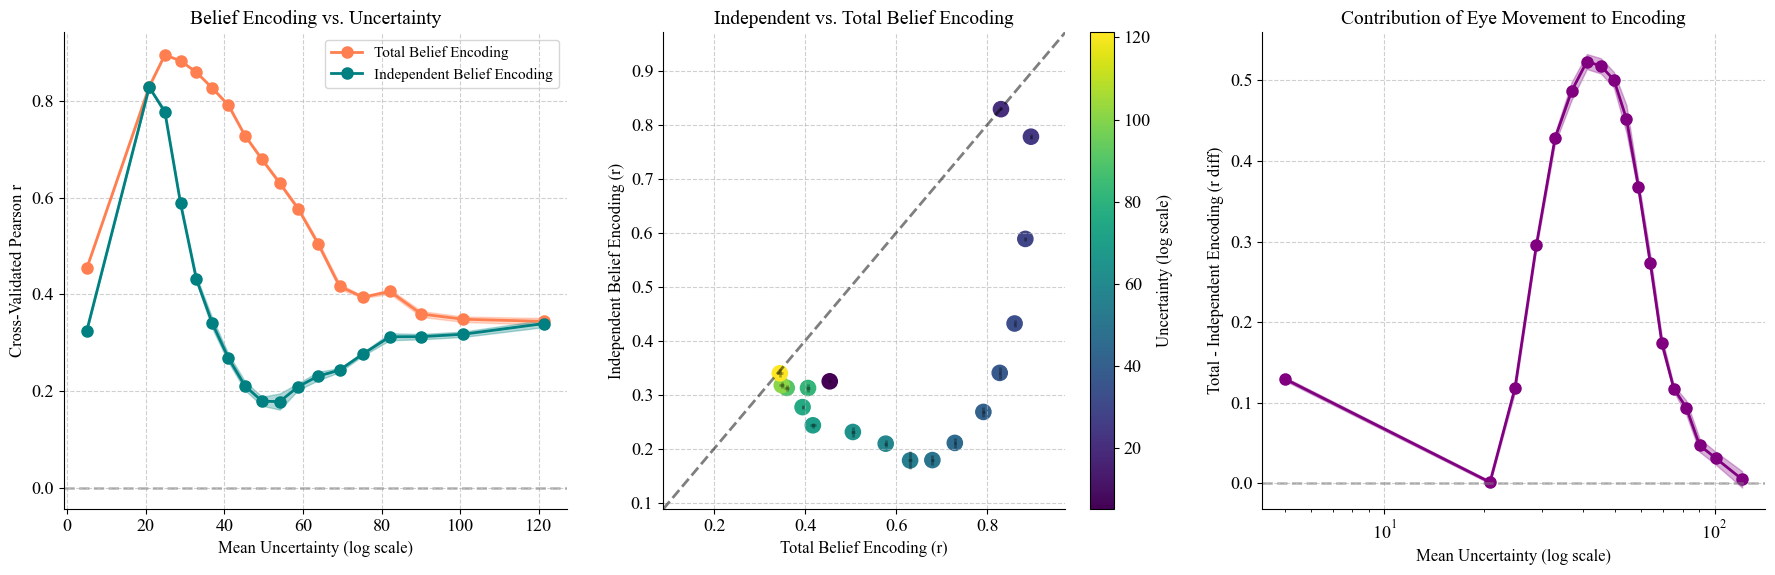


--- Running time-based uncertainty analysis ---


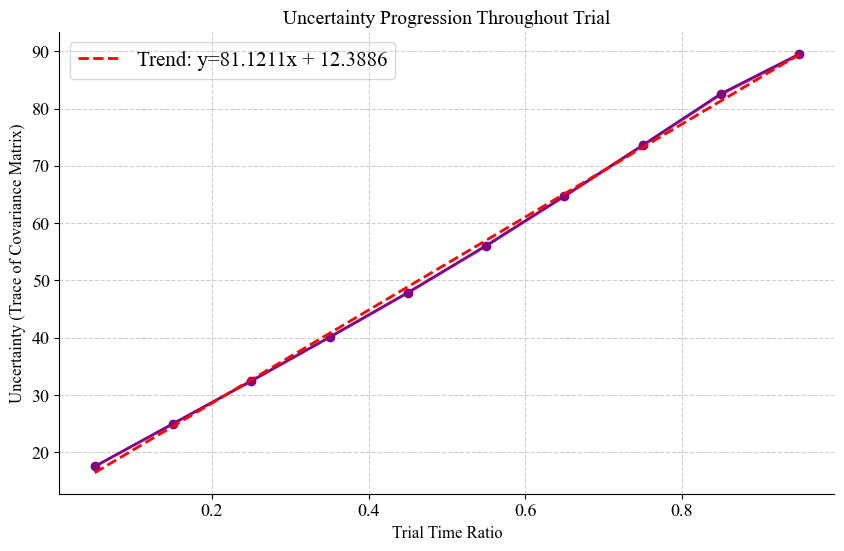


Uncertainty Analysis Results:
Bin 1: Mean Uncertainty = nan, Total r = nan ± nan, Independent r = nan ± nan, n = 0
Bin 2: Mean Uncertainty = nan, Total r = nan ± nan, Independent r = nan ± nan, n = 0
Bin 3: Mean Uncertainty = 5.0074, Total r = 0.4538 ± 0.0012, Independent r = 0.3246 ± 0.0019, n = 60009
Bin 4: Mean Uncertainty = 20.8959, Total r = 0.8301 ± 0.0011, Independent r = 0.8290 ± 0.0013, n = 20011
Bin 5: Mean Uncertainty = 24.8713, Total r = 0.8960 ± 0.0018, Independent r = 0.7780 ± 0.0047, n = 20005
Bin 6: Mean Uncertainty = 28.8609, Total r = 0.8836 ± 0.0006, Independent r = 0.5885 ± 0.0040, n = 20005
Bin 7: Mean Uncertainty = 32.8770, Total r = 0.8600 ± 0.0016, Independent r = 0.4318 ± 0.0063, n = 20005
Bin 8: Mean Uncertainty = 36.9370, Total r = 0.8274 ± 0.0014, Independent r = 0.3403 ± 0.0110, n = 20005
Bin 9: Mean Uncertainty = 41.0548, Total r = 0.7914 ± 0.0034, Independent r = 0.2679 ± 0.0087, n = 20005
Bin 10: Mean Uncertainty = 45.2617, Total r = 0.7286 ± 0.0023, In

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

# Function to bin data by uncertainty and analyze neural encoding
def analyze_uncertainty_encoding(timedf, n_bins=20):
    """
    Analyze how belief encoding varies across different levels of uncertainty
    using percentile-based binning to ensure equal sample sizes
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of uncertainty bins to create
    
    Returns:
    --------
    dict with results
    """
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    uncertainty_data = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    
    # Calculate total sample count and bin size
    total_samples = len(uncertainty_data)
    samples_per_bin = total_samples // n_bins
    print(f"Total samples: {total_samples}")
    print(f"Target samples per bin: {samples_per_bin}")
    
    # Sort data by uncertainty
    sort_idx = np.argsort(uncertainty_data)
    uncertainty_sorted = uncertainty_data[sort_idx]
    neural_sorted = neural_data[sort_idx]
    belief_sorted = belief_data[sort_idx]
    eye_sorted = eye_data[sort_idx]
    
    # Create bin edges to ensure equal sample counts
    bin_edges = [uncertainty_sorted[0]]
    for i in range(1, n_bins):
        idx = i * samples_per_bin
        bin_edges.append((uncertainty_sorted[idx-1] + uncertainty_sorted[idx]) / 2)
    bin_edges.append(uncertainty_sorted[-1])
    
    # Print bin edges and expected counts
    print("Bin edges:")
    for i in range(len(bin_edges)-1):
        print(f"  Bin {i+1}: {bin_edges[i]:.4f} - {bin_edges[i+1]:.4f}")
    
    # Initialize results
    results = {
        'bin_centers': [],
        'r_total': [],
        'r_independent': [],
        'r_total_se': [],  # Standard errors
        'r_independent_se': [],
        'mean_uncertainty': [],
        'sample_counts': []
    }
    
    # Configure cross-validation
    n_folds = 5
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Analyze each uncertainty bin
    for i in range(n_bins):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:  # Include upper bound in last bin
            bin_mask = (uncertainty_data >= bin_start) & (uncertainty_data <= bin_end)
        else:
            bin_mask = (uncertainty_data >= bin_start) & (uncertainty_data < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        uncertainty_bin = uncertainty_data[bin_mask]
        
        n_samples = len(belief_bin)
        print(f"Bin {i+1}: Range {bin_start:.4f} - {bin_end:.4f}, Samples: {n_samples}")
        
        # Skip if not enough samples
        if n_samples < n_folds * 4:  # Need enough samples per fold
            print(f"  Skipping bin {i+1} - insufficient samples for {n_folds} folds")
            results['bin_centers'].append((bin_start + bin_end) / 2)
            results['r_total'].append(np.nan)
            results['r_independent'].append(np.nan)
            results['r_total_se'].append(np.nan)
            results['r_independent_se'].append(np.nan)
            results['mean_uncertainty'].append(np.nan if n_samples == 0 else np.mean(uncertainty_bin))
            results['sample_counts'].append(n_samples)
            continue
        
        # --- Perform cross-validation with per-fold metrics ---
        
        # Initialize arrays to store per-fold results
        r_total_folds = np.zeros(n_folds)
        r_independent_folds = np.zeros(n_folds)
        
        # Perform cross-validation
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(neural_bin)):
            # Split data for this fold
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # 1. Total Belief Encoding: Neural -> Belief
            model_total = LinearRegression().fit(X_train, y_train)
            y_pred_total = model_total.predict(X_test)
            
            # Calculate correlation for this fold
            r_total_fold, _ = pearsonr(y_test, y_pred_total)
            r_total_folds[fold_idx] = r_total_fold
            
            # 2. Independent Belief Encoding: 
            # First, train model to predict neural from eye
            model_eye = LinearRegression().fit(eye_train, X_train)
            
            # Get neural predictions from eye
            X_pred_from_eye_test = model_eye.predict(eye_test)
            
            # Calculate residuals (neural activity not explained by eye)
            X_residual_test = X_test - X_pred_from_eye_test
            
            # Use residuals to predict belief
            model_independent = LinearRegression().fit(
                X_train - model_eye.predict(eye_train), y_train)
            y_pred_independent = model_independent.predict(X_residual_test)
            
            # Calculate correlation for this fold
            r_independent_fold, _ = pearsonr(y_test, y_pred_independent)
            r_independent_folds[fold_idx] = r_independent_fold
        
        # Calculate mean and standard error across folds
        r_total_mean = np.mean(r_total_folds)
        r_independent_mean = np.mean(r_independent_folds)
        r_total_se = np.std(r_total_folds) / np.sqrt(n_folds)
        r_independent_se = np.std(r_independent_folds) / np.sqrt(n_folds)
        
        print(f"  Total Encoding: r = {r_total_mean:.4f} ± {r_total_se:.4f}")
        print(f"  Independent Encoding: r = {r_independent_mean:.4f} ± {r_independent_se:.4f}")
        
        # Store results
        results['bin_centers'].append((bin_start + bin_end) / 2)
        results['r_total'].append(r_total_mean)
        results['r_independent'].append(r_independent_mean)
        results['r_total_se'].append(r_total_se)
        results['r_independent_se'].append(r_independent_se)
        results['mean_uncertainty'].append(np.mean(uncertainty_bin))
        results['sample_counts'].append(n_samples)
    
    return results

# Function to visualize results
def plot_uncertainty_analysis(results):
    """
    Plot results of uncertainty encoding analysis with shaded error bars
    
    Parameters:
    -----------
    results : dict
        Results from analyze_uncertainty_encoding function
    """
    # Convert lists to arrays for easier manipulation
    bin_centers = np.array(results['bin_centers'])
    r_total = np.array(results['r_total'])
    r_independent = np.array(results['r_independent'])
    r_total_se = np.array(results['r_total_se'])
    r_independent_se = np.array(results['r_independent_se'])
    mean_uncertainty = np.array(results['mean_uncertainty'])
    sample_counts = np.array(results['sample_counts'])
    
    # Filter out NaN values for plotting
    valid_mask = ~np.isnan(r_total) & ~np.isnan(r_independent) & ~np.isnan(mean_uncertainty)
    
    if np.sum(valid_mask) < 2:
        print("Not enough valid data points for plotting")
        return None
    
    bin_centers = bin_centers[valid_mask]
    r_total = r_total[valid_mask]
    r_independent = r_independent[valid_mask]
    r_total_se = r_total_se[valid_mask]
    r_independent_se = r_independent_se[valid_mask]
    mean_uncertainty = mean_uncertainty[valid_mask]
    sample_counts = sample_counts[valid_mask]
    
    # Create figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Sort data points by uncertainty for line plots
    sort_idx = np.argsort(mean_uncertainty)
    sorted_uncertainty = mean_uncertainty[sort_idx]
    sorted_r_total = r_total[sort_idx]
    sorted_r_total_se = r_total_se[sort_idx]
    sorted_r_independent = r_independent[sort_idx]
    sorted_r_independent_se = r_independent_se[sort_idx]
    sorted_sample_counts = sample_counts[sort_idx]
    
    # Plot 1: Encoding strength vs uncertainty (with log scale)
    ax1.plot(sorted_uncertainty, sorted_r_total, 'o-', color='coral', 
             label='Total Belief Encoding', markersize=8)
    ax1.fill_between(sorted_uncertainty, 
                    sorted_r_total - sorted_r_total_se, 
                    sorted_r_total + sorted_r_total_se, 
                    color='coral', alpha=0.3)
    
    ax1.plot(sorted_uncertainty, sorted_r_independent, 'o-', color='teal', 
             label='Independent Belief Encoding', markersize=8)
    ax1.fill_between(sorted_uncertainty, 
                    sorted_r_independent - sorted_r_independent_se, 
                    sorted_r_independent + sorted_r_independent_se, 
                    color='teal', alpha=0.3)
    
    # Add reference line at r=0
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Set log scale for x-axis
    # ax1.set_xscale('log')
    
    ax1.set_xlabel('Mean Uncertainty (log scale)', fontsize=12)
    ax1.set_ylabel('Cross-Validated Pearson r', fontsize=12)
    ax1.set_title('Belief Encoding vs. Uncertainty', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot 2: Independent vs total encoding
    scatter = ax2.scatter(r_total, r_independent, c=mean_uncertainty, cmap='viridis', s=120)
    
    # Add error bars
    for i in range(len(r_total)):
        ax2.errorbar(r_total[i], r_independent[i], 
                    xerr=r_total_se[i], yerr=r_independent_se[i],
                    fmt='none', ecolor='black', alpha=0.3)
    
    # Add colorbar with log scale
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Uncertainty (log scale)', fontsize=12)
    
    # Add reference line for y=x
    min_val = min(np.nanmin(r_total - r_total_se), np.nanmin(r_independent - r_independent_se))
    max_val = max(np.nanmax(r_total + r_total_se), np.nanmax(r_independent + r_independent_se))
    buffer = (max_val - min_val) * 0.1  # Add some buffer
    plot_min = min_val - buffer
    plot_max = max_val + buffer
    ax2.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', alpha=0.5)
    ax2.set_xlim(plot_min, plot_max)
    ax2.set_ylim(plot_min, plot_max)
    
    ax2.set_xlabel('Total Belief Encoding (r)', fontsize=12)
    ax2.set_ylabel('Independent Belief Encoding (r)', fontsize=12)
    ax2.set_title('Independent vs. Total Belief Encoding', fontsize=14)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # Plot 3: Difference between total and independent encoding
    encoding_diff = sorted_r_total - sorted_r_independent
    # Calculate standard error of the difference
    diff_se = np.sqrt(sorted_r_total_se**2 + sorted_r_independent_se**2)
    
    ax3.plot(sorted_uncertainty, encoding_diff, 'o-', color='purple', 
             markersize=8)
    ax3.fill_between(sorted_uncertainty, 
                    encoding_diff - diff_se, 
                    encoding_diff + diff_se, 
                    color='purple', alpha=0.3)
    
    # Add reference line at diff=0
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    # Set log scale for x-axis
    ax3.set_xscale('log')
    
    ax3.set_xlabel('Mean Uncertainty (log scale)', fontsize=12)
    ax3.set_ylabel('Total - Independent Encoding (r diff)', fontsize=12)
    ax3.set_title('Contribution of Eye Movement to Encoding', fontsize=14)
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    return fig

# Add a function to analyze and visualize the uncertainty over time
def analyze_uncertainty_by_time(timedf, n_time_bins=10):
    """
    Analyze how uncertainty changes over trial time
    """
    # Extract time ratio and uncertainty
    time_ratio = timedf['timeratio'].to_numpy()
    uncertainty = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_time_bins + 1)
    time_bin_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2
    
    # Initialize results
    mean_uncertainty = np.zeros(n_time_bins)
    std_uncertainty = np.zeros(n_time_bins)
    counts = np.zeros(n_time_bins)
    
    # Bin data by time
    for i in range(n_time_bins):
        if i == n_time_bins - 1:
            bin_mask = (time_ratio >= time_bin_edges[i]) & (time_ratio <= time_bin_edges[i+1])
        else:
            bin_mask = (time_ratio >= time_bin_edges[i]) & (time_ratio < time_bin_edges[i+1])
            
        uncertainty_bin = uncertainty[bin_mask]
        
        if len(uncertainty_bin) > 0:
            mean_uncertainty[i] = np.mean(uncertainty_bin)
            std_uncertainty[i] = np.std(uncertainty_bin)
            counts[i] = len(uncertainty_bin)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot mean uncertainty with error bands
    ax.plot(time_bin_centers, mean_uncertainty, 'o-', color='purple')
    ax.fill_between(time_bin_centers, 
                   mean_uncertainty - std_uncertainty/np.sqrt(counts), 
                   mean_uncertainty + std_uncertainty/np.sqrt(counts), 
                   color='purple', alpha=0.3)
    
    # Add trend line
    z = np.polyfit(time_bin_centers, mean_uncertainty, 1)
    p = np.poly1d(z)
    ax.plot(time_bin_centers, p(time_bin_centers), "r--", 
            label=f'Trend: y={z[0]:.4f}x + {z[1]:.4f}')
    
    ax.set_xlabel('Trial Time Ratio', fontsize=12)
    ax.set_ylabel('Uncertainty (Trace of Covariance Matrix)', fontsize=12)
    ax.set_title('Uncertainty Progression Throughout Trial', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    
    return fig, (mean_uncertainty, std_uncertainty, time_bin_centers, counts)

# Run the percentile-based uncertainty analysis
print("\n--- Running uncertainty binning analysis with 20 equal-sample bins ---")
uncertainty_results = analyze_uncertainty_encoding(timedf, n_bins=20)
fig1 = plot_uncertainty_analysis(uncertainty_results)
if fig1:
    plt.figure(fig1.number)
    plt.savefig('uncertainty_encoding_analysis_equal_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n--- Running time-based uncertainty analysis ---")
time_fig, time_results = analyze_uncertainty_by_time(timedf)
plt.figure(time_fig.number)
plt.savefig('uncertainty_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numerical results
print("\nUncertainty Analysis Results:")
for i in range(len(uncertainty_results['bin_centers'])):
    print(f"Bin {i+1}: Mean Uncertainty = {uncertainty_results['mean_uncertainty'][i]:.4f}, "
          f"Total r = {uncertainty_results['r_total'][i]:.4f} ± {uncertainty_results['r_total_se'][i]:.4f}, "
          f"Independent r = {uncertainty_results['r_independent'][i]:.4f} ± {uncertainty_results['r_independent_se'][i]:.4f}, "
          f"n = {uncertainty_results['sample_counts'][i]}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from scipy.interpolate import griddata
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D


This pattern suggests a strategic shift in how the brain allocates neural resources during the decision phase. As the animal gets closer to making its final decision, it appears to selectively enhance the independent belief encoding in response to uncertainty, perhaps to ensure that its final decision is based on its internal model rather than just relying on current sensory (eye) information.
This could represent a computational strategy where, under high uncertainty near decision points, the system places greater weight on its internal model to compensate for the unreliability of immediate sensory evidence.

In [ ]:

def partial_correlation_analysis(timedf, n_time_bins=5):
    """
    Analyze partial correlation between uncertainty and encoding strength,
    controlling for time ratio
    """
    print("\n--- Partial Correlation Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    uncertainty_data = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Define time bins
    time_percentiles = np.linspace(0, 100, n_time_bins+1)
    time_bin_edges = np.percentile(time_ratio, time_percentiles)
    
    # Initialize results array
    partial_corr_results = {
        'time_bin': [],
        'uncertainty_partial_r_total': [],
        'uncertainty_partial_r_independent': [],
        'time_bin_center': []
    }
    
    # Analyze each time bin to control for time
    for i in range(n_time_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_time_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        uncertainty_bin = uncertainty_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 50:  # Skip bins with too few samples
            continue
            
        print(f"Time Bin {i+1}: {bin_start:.2f}-{bin_end:.2f}, n={n_samples}")
        
        # Instead of per-point calculations, partition by uncertainty quartiles
        n_quartiles = 5  # Divide bin into uncertainty quartiles
        quartile_edges = np.percentile(uncertainty_bin, np.linspace(0, 100, n_quartiles+1))
        
        total_r_values = []
        indep_r_values = []
        quartile_uncertainties = []
        
        # Calculate encoding strength for each quartile
        for j in range(n_quartiles):
            q_start = quartile_edges[j]
            q_end = quartile_edges[j+1]
            
            # Create quartile mask
            if j == n_quartiles - 1:
                q_mask = (uncertainty_bin >= q_start) & (uncertainty_bin <= q_end)
            else:
                q_mask = (uncertainty_bin >= q_start) & (uncertainty_bin < q_end)
                
            # Get data for this quartile
            X_q = neural_bin[q_mask]
            y_q = belief_bin[q_mask]
            eye_q = eye_bin[q_mask]
            
            # Skip if too few samples
            if len(y_q) < 20:
                continue
                
            # Calculate encoding strength for this quartile
            # Total encoding
            model_total = LinearRegression().fit(X_q, y_q)
            y_pred_total = model_total.predict(X_q)
            
            # Calculate correlation
            r_total, _ = pearsonr(y_q, y_pred_total)
            
            # Independent encoding
            model_eye = LinearRegression().fit(eye_q, X_q)
            X_residual = X_q - model_eye.predict(eye_q)
            model_indep = LinearRegression().fit(X_residual, y_q)
            y_pred_indep = model_indep.predict(X_residual)
            r_indep, _ = pearsonr(y_q, y_pred_indep)
            
            # Store values
            total_r_values.append(r_total)
            indep_r_values.append(r_indep)
            quartile_uncertainties.append(np.mean(uncertainty_bin[q_mask]))
        
        # Now correlate encoding strength with uncertainty across quartiles
        if len(quartile_uncertainties) < 3:
            continue
            
        r_total_vs_uncertainty, p_total = spearmanr(quartile_uncertainties, total_r_values)
        r_indep_vs_uncertainty, p_indep = spearmanr(quartile_uncertainties, indep_r_values)
        
        print(f"  Partial correlation with uncertainty:")
        print(f"    Total encoding: {r_total_vs_uncertainty:.4f}, p={p_total:.4f}")
        print(f"    Independent encoding: {r_indep_vs_uncertainty:.4f}, p={p_indep:.4f}")
        
        # Store results
        partial_corr_results['time_bin'].append(i+1)
        partial_corr_results['uncertainty_partial_r_total'].append(r_total_vs_uncertainty)
        partial_corr_results['uncertainty_partial_r_independent'].append(r_indep_vs_uncertainty)
        partial_corr_results['time_bin_center'].append((bin_start + bin_end) / 2)
    
    # Create visualization
    if len(partial_corr_results['time_bin']) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.plot(partial_corr_results['time_bin_center'], 
                partial_corr_results['uncertainty_partial_r_total'], 'o-', 
                color='coral', label='Total Encoding')
        ax.plot(partial_corr_results['time_bin_center'], 
                partial_corr_results['uncertainty_partial_r_independent'], 'o-', 
                color='teal', label='Independent Encoding')
        
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        
        ax.set_xlabel('Time Ratio')
        ax.set_ylabel('Partial Correlation with Uncertainty')
        ax.set_title('Uncertainty Effect Controlling for Time')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
        plt.tight_layout()
        plt.savefig('partial_correlation_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    return partial_corr_results

# 1. Partial correlation analysis
print("\nRunning Partial Correlation Analysis...")
partial_corr_results = partial_correlation_analysis(timedf, n_time_bins=15)


Running Joint Visualization Analysis...

--- Joint Visualization Analysis ---
Bin Time=0.00-0.14, Unc=0.00-28.76: n=59915, Total r=0.721, Indep r=0.698
Bin Time=0.00-0.14, Unc=28.76-57.53: n=2202, Total r=0.907, Indep r=0.741
Bin Time=0.14-0.29, Unc=0.00-28.76: n=19140, Total r=0.864, Indep r=0.588
Bin Time=0.14-0.29, Unc=28.76-57.53: n=42163, Total r=0.841, Indep r=0.432
Bin Time=0.14-0.29, Unc=57.53-86.29: n=25, Total r=0.868, Indep r=0.529
Bin Time=0.29-0.43, Unc=0.00-28.76: n=7832, Total r=0.803, Indep r=0.373
Bin Time=0.29-0.43, Unc=28.76-57.53: n=48437, Total r=0.770, Indep r=0.191
Bin Time=0.29-0.43, Unc=57.53-86.29: n=4785, Total r=0.765, Indep r=0.345
Bin Time=0.43-0.57, Unc=0.00-28.76: n=6531, Total r=0.691, Indep r=0.335
Bin Time=0.43-0.57, Unc=28.76-57.53: n=25828, Total r=0.700, Indep r=0.191
Bin Time=0.43-0.57, Unc=57.53-86.29: n=27693, Total r=0.534, Indep r=0.246
Bin Time=0.43-0.57, Unc=86.29-115.06: n=545, Total r=0.943, Indep r=0.914
Bin Time=0.57-0.71, Unc=0.00-28.7

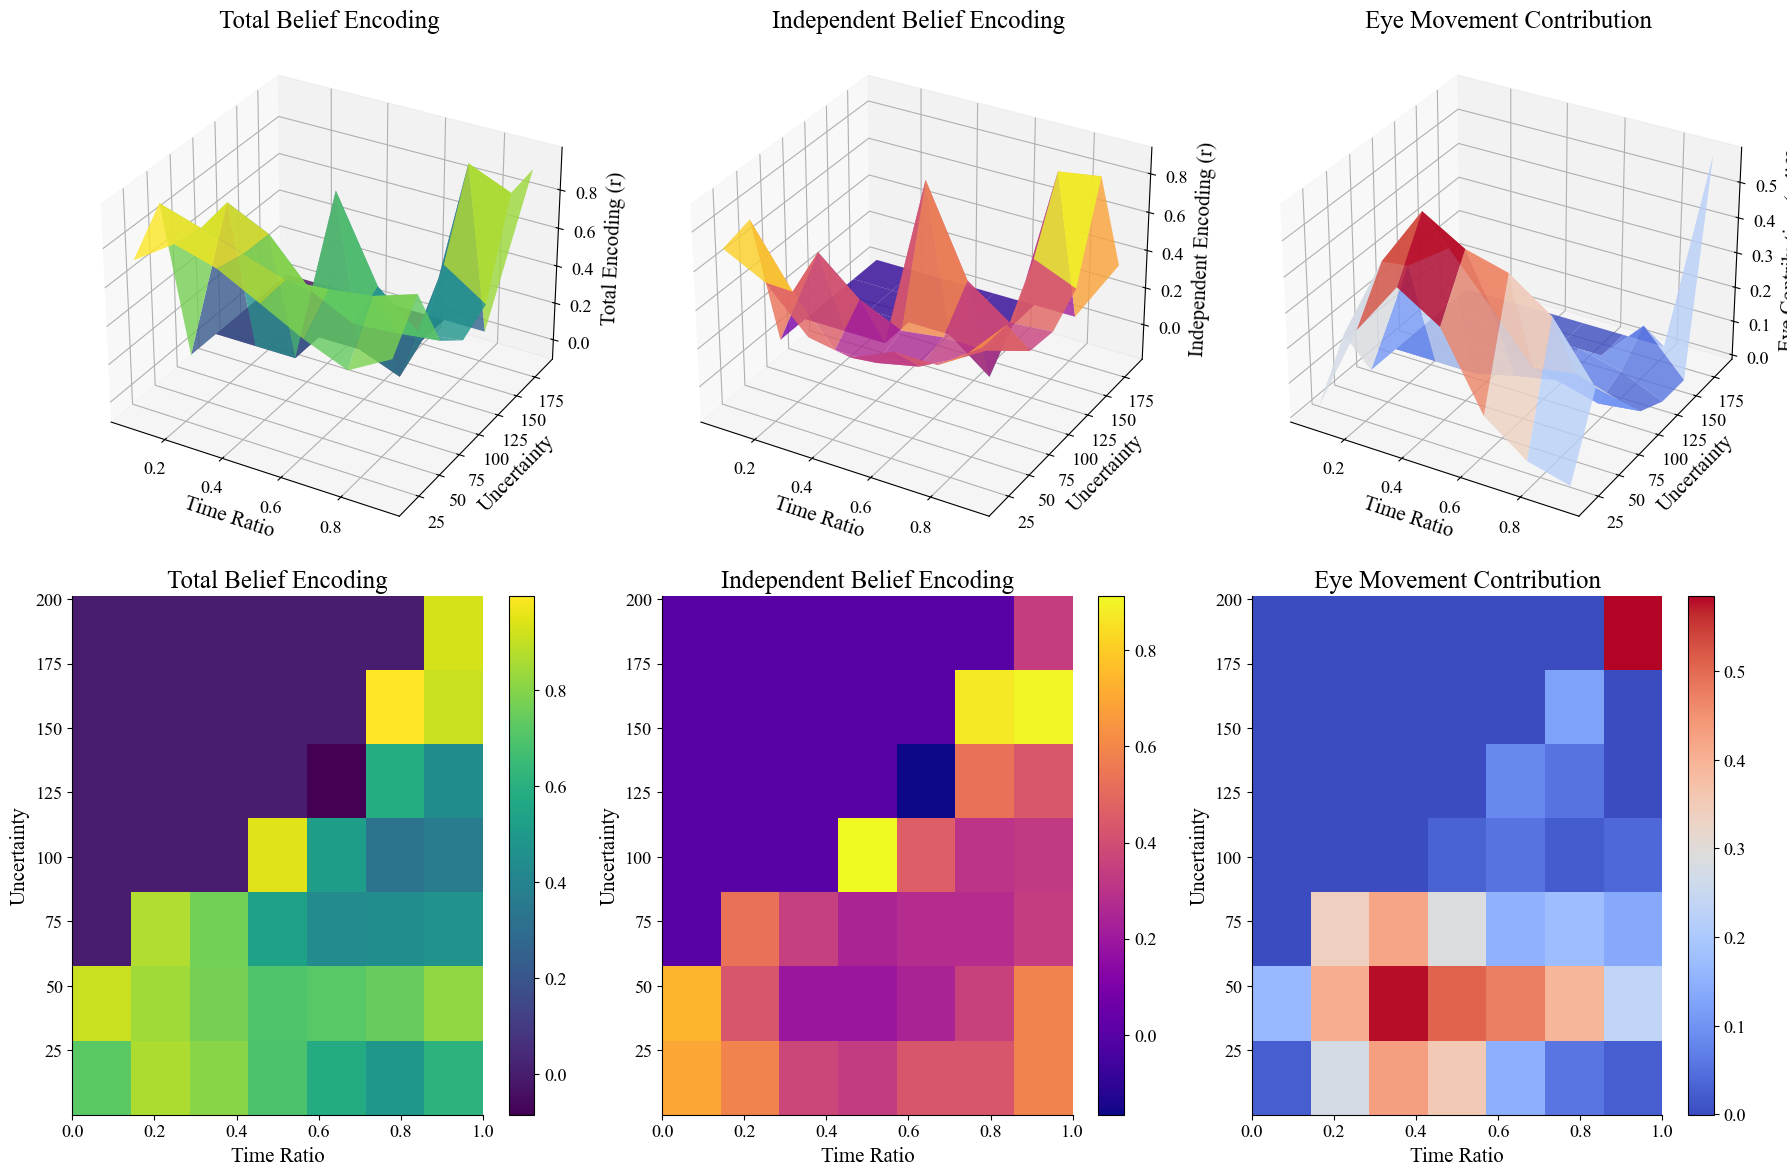

In [45]:
# 2. Joint visualization of uncertainty and time ratio effects
def joint_visualization(timedf, n_bins=7):
    """
    Create a joint visualization of how encoding varies with both
    uncertainty and time ratio
    """
    print("\n--- Joint Visualization Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    uncertainty_data = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Create grid for analysis
    n_time_bins = n_bins
    n_uncertainty_bins = n_bins
    
    # Define bin edges using linear spacing
    time_bin_edges = np.linspace(0, 1, n_time_bins+1)
    
    # Use linear-spaced uncertainty bins
    min_uncertainty = np.min(uncertainty_data)
    max_uncertainty = np.max(uncertainty_data)
    uncertainty_bin_edges = np.linspace(
        min_uncertainty, 
        max_uncertainty, 
        n_uncertainty_bins+1)
    
    # Initialize grid arrays
    grid_total_r = np.full((n_time_bins, n_uncertainty_bins), np.nan)
    grid_indep_r = np.full((n_time_bins, n_uncertainty_bins), np.nan)
    grid_sample_counts = np.zeros((n_time_bins, n_uncertainty_bins), dtype=int)
    
    # Configure cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Populate grid
    for i in range(n_time_bins):
        for j in range(n_uncertainty_bins):
            # Define bin ranges
            time_start = time_bin_edges[i]
            time_end = time_bin_edges[i+1]
            unc_start = uncertainty_bin_edges[j]
            unc_end = uncertainty_bin_edges[j+1]
            
            # Create mask for current bin
            time_mask = (time_ratio >= time_start) & (time_ratio <= time_end if i == n_time_bins-1 else time_ratio < time_end)
            unc_mask = (uncertainty_data >= unc_start) & (uncertainty_data <= unc_end if j == n_uncertainty_bins-1 else uncertainty_data < unc_end)
            bin_mask = time_mask & unc_mask
            
            # Select data for current bin
            neural_bin = neural_data[bin_mask]
            belief_bin = belief_data[bin_mask]
            eye_bin = eye_data[bin_mask]
            
            n_samples = len(belief_bin)
            grid_sample_counts[i, j] = n_samples
            
            # Skip if not enough samples
            if n_samples < 20:  # Need reasonable sample size for CV
                continue
            
            # Perform cross-validation
            belief_pred_total = np.zeros_like(belief_bin)
            belief_pred_independent = np.zeros_like(belief_bin)
            
            for train_idx, test_idx in kf.split(neural_bin):
                # Total encoding
                X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
                y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
                eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
                
                model_total = LinearRegression().fit(X_train, y_train)
                belief_pred_total[test_idx] = model_total.predict(X_test)
                
                # Independent encoding
                model_eye = LinearRegression().fit(eye_train, X_train)
                X_residual_train = X_train - model_eye.predict(eye_train)
                X_residual_test = X_test - model_eye.predict(eye_test)
                model_indep = LinearRegression().fit(X_residual_train, y_train)
                belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
            
            # Calculate performance metrics
            r_total, _ = pearsonr(belief_bin, belief_pred_total)
            r_indep, _ = pearsonr(belief_bin, belief_pred_independent)
            
            # Store results
            grid_total_r[i, j] = r_total
            grid_indep_r[i, j] = r_indep
            
            print(f"Bin Time={time_start:.2f}-{time_end:.2f}, Unc={unc_start:.2f}-{unc_end:.2f}: " +
                  f"n={n_samples}, Total r={r_total:.3f}, Indep r={r_indep:.3f}")
    
    # Create center points for visualization
    time_centers = (time_bin_edges[:-1] + time_bin_edges[1:]) / 2
    unc_centers = (uncertainty_bin_edges[:-1] + uncertainty_bin_edges[1:]) / 2  # Arithmetic mean
    
    # Create meshgrid for plotting
    T, U = np.meshgrid(time_centers, unc_centers)
    
    # Create visualization with more robust handling
    fig = plt.figure(figsize=(18, 12))
    
    # Handle potential issues with NaN values in the grids
    grid_total_r_plot = np.copy(grid_total_r)
    grid_indep_r_plot = np.copy(grid_indep_r)
    
    # Use masked arrays to handle NaN values in plots
    mask_total = np.isnan(grid_total_r_plot)
    mask_indep = np.isnan(grid_indep_r_plot)
    
    # Fill NaN with a default value for visualization
    grid_total_r_plot[mask_total] = 0
    grid_indep_r_plot[mask_indep] = 0
    
    # Plot 1: 3D surface for total encoding
    ax1 = fig.add_subplot(231, projection='3d')
    surf1 = ax1.plot_surface(T, U, grid_total_r_plot.T, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('Time Ratio')
    ax1.set_ylabel('Uncertainty')
    ax1.set_zlabel('Total Encoding (r)')
    ax1.set_title('Total Belief Encoding')
    
    # Plot 2: 3D surface for independent encoding
    ax2 = fig.add_subplot(232, projection='3d')
    surf2 = ax2.plot_surface(T, U, grid_indep_r_plot.T, cmap='plasma', alpha=0.8)
    ax2.set_xlabel('Time Ratio')
    ax2.set_ylabel('Uncertainty')
    ax2.set_zlabel('Independent Encoding (r)')
    ax2.set_title('Independent Belief Encoding')
    
    # Plot 3: Difference (eye contribution)
    diff_grid = grid_total_r_plot - grid_indep_r_plot
    ax3 = fig.add_subplot(233, projection='3d')
    surf3 = ax3.plot_surface(T, U, diff_grid.T, cmap='coolwarm', alpha=0.8)
    ax3.set_xlabel('Time Ratio')
    ax3.set_ylabel('Uncertainty')
    ax3.set_zlabel('Eye Contribution (r diff)')
    ax3.set_title('Eye Movement Contribution')
    
    # Plot 4-6: 2D heatmaps
    ax4 = fig.add_subplot(234)
    im4 = ax4.pcolormesh(time_centers, unc_centers, grid_total_r_plot.T, cmap='viridis')
    ax4.set_xlabel('Time Ratio')
    ax4.set_ylabel('Uncertainty')
    ax4.set_title('Total Belief Encoding')
    plt.colorbar(im4, ax=ax4)
    
    ax5 = fig.add_subplot(235)
    im5 = ax5.pcolormesh(time_centers, unc_centers, grid_indep_r_plot.T, cmap='plasma')
    ax5.set_xlabel('Time Ratio')
    ax5.set_ylabel('Uncertainty')
    ax5.set_title('Independent Belief Encoding')
    plt.colorbar(im5, ax=ax5)
    
    ax6 = fig.add_subplot(236)
    im6 = ax6.pcolormesh(time_centers, unc_centers, diff_grid.T, cmap='coolwarm')
    ax6.set_xlabel('Time Ratio')
    ax6.set_ylabel('Uncertainty')
    ax6.set_title('Eye Movement Contribution')
    plt.colorbar(im6, ax=ax6)
    
    plt.tight_layout()
    return fig, (grid_total_r, grid_indep_r, time_centers, unc_centers, grid_sample_counts)



# 2. Joint visualization
print("\nRunning Joint Visualization Analysis...")
joint_fig, joint_results = joint_visualization(timedf, n_bins=7)
plt.figure(joint_fig.number)
plt.savefig('joint_uncertainty_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



Running Within-Trial Analysis...

--- Within-Trial Analysis ---
Identified 1537 trials
Average points per trial: 260.3

Segment 1: 0.00-0.20 of trial
  Trials analyzed: 1535
  Average Total r: 0.9998
  Average Independent r: 0.5866
  Average Uncertainty: 20.1958

Segment 2: 0.20-0.40 of trial
  Trials analyzed: 1535
  Average Total r: 1.0000
  Average Independent r: 0.5026
  Average Uncertainty: 33.0308

Segment 3: 0.40-0.60 of trial
  Trials analyzed: 1535
  Average Total r: 1.0000
  Average Independent r: 0.4209
  Average Uncertainty: 46.3959

Segment 4: 0.60-0.80 of trial
  Trials analyzed: 1535
  Average Total r: 1.0000
  Average Independent r: 0.4875
  Average Uncertainty: 60.6311

Segment 5: 0.80-1.00 of trial
  Trials analyzed: 1535
  Average Total r: 1.0000
  Average Independent r: 0.5824
  Average Uncertainty: 76.1933


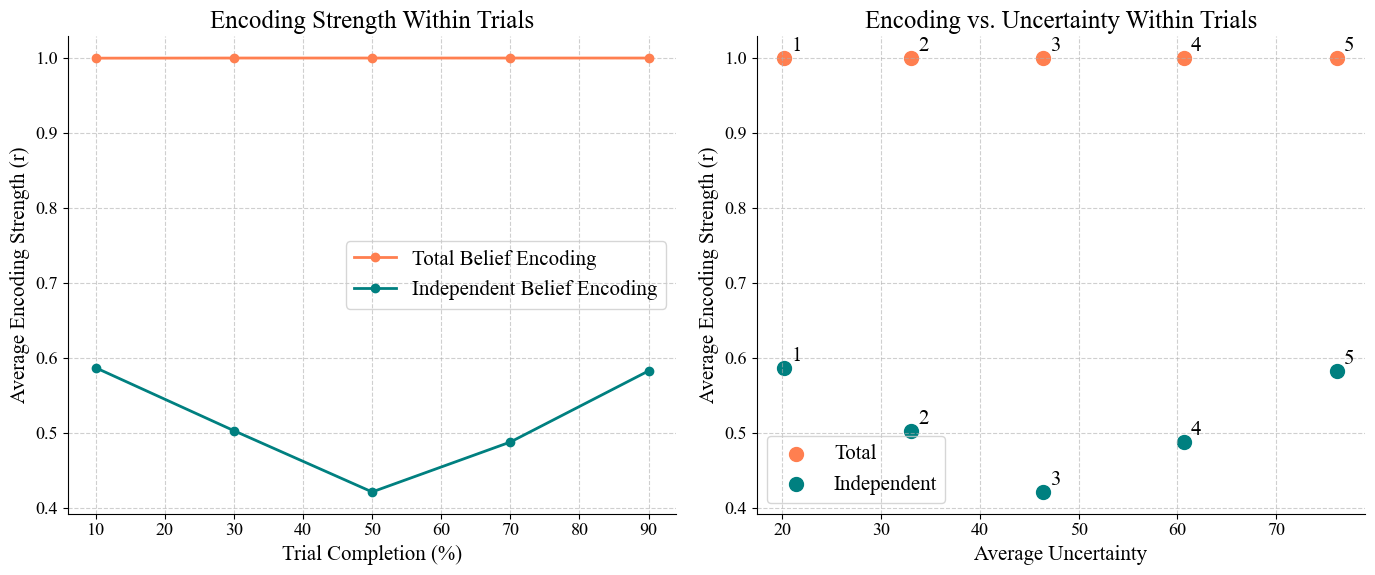

In [46]:

# 3. Within-trial analysis
def within_trial_analysis(timedf, n_bins=5):
    """
    Analyze how encoding changes within individual trials
    """
    print("\n--- Within-Trial Analysis ---")
    
    # First, identify unique trials
    # We need to reconstruct trial IDs since each row is a time point
    n_points_per_trial = []
    current_count = 1
    timer_values = timedf['timer'].to_numpy()
    
    for i in range(1, len(timer_values)):
        if timer_values[i] < timer_values[i-1]:  # New trial starts
            n_points_per_trial.append(current_count)
            current_count = 1
        else:
            current_count += 1
    n_points_per_trial.append(current_count)  # Add last trial
    
    # Create trial IDs
    trial_ids = np.zeros(len(timer_values), dtype=int)
    idx = 0
    for trial_idx, n_points in enumerate(n_points_per_trial):
        trial_ids[idx:idx+n_points] = trial_idx
        idx += n_points
    
    print(f"Identified {len(n_points_per_trial)} trials")
    print(f"Average points per trial: {np.mean(n_points_per_trial):.1f}")
    
    # Group data by trials
    trials = np.unique(trial_ids)
    
    # Initialize results
    within_trial_results = {
        'segment': [],
        'avg_total_r': [],
        'avg_indep_r': [],
        'avg_uncertainty': []
    }
    
    # Define segment boundaries (by percentage of trial)
    segment_edges = np.linspace(0, 1, n_bins+1)
    
    # Analyze each segment across trials
    for i in range(n_bins):
        seg_start = segment_edges[i]
        seg_end = segment_edges[i+1]
        
        print(f"\nSegment {i+1}: {seg_start:.2f}-{seg_end:.2f} of trial")
        
        # Initialize segment results
        segment_total_r = []
        segment_indep_r = []
        segment_uncertainty = []
        
        # Process each trial
        for trial in trials:
            # Get trial data
            trial_mask = (trial_ids == trial)
            trial_data = {
                'neural': np.vstack(timedf.loc[trial_mask, 'PPC'].to_numpy()),
                'belief': timedf.loc[trial_mask, 'belief'].to_numpy(),
                'eye': timedf.loc[trial_mask, 'eye'].to_numpy().reshape(-1, 1),
                'uncertainty': np.array([np.trace(cov) for cov in 
                                       timedf.loc[trial_mask, 'uncertainty'].to_numpy()]),
                'timeratio': timedf.loc[trial_mask, 'timeratio'].to_numpy()
            }
            
            n_points = len(trial_data['belief'])
            if n_points < 10:  # Skip very short trials
                continue
            
            # Define segment indices for this trial
            seg_start_idx = max(0, int(np.floor(seg_start * n_points)))
            seg_end_idx = min(n_points, int(np.ceil(seg_end * n_points)))
            
            if seg_end_idx - seg_start_idx < 5:  # Skip if segment too small
                continue
            
            # Extract segment data
            seg_neural = trial_data['neural'][seg_start_idx:seg_end_idx]
            seg_belief = trial_data['belief'][seg_start_idx:seg_end_idx]
            seg_eye = trial_data['eye'][seg_start_idx:seg_end_idx]
            seg_uncertainty = trial_data['uncertainty'][seg_start_idx:seg_end_idx]
            
            # Encoding analysis for this segment
            # (Simple regression since we're not doing CV within trials)
            
            # Total encoding
            model_total = LinearRegression().fit(seg_neural, seg_belief)
            pred_total = model_total.predict(seg_neural)
            r_total, _ = pearsonr(seg_belief, pred_total)
            
            # Independent encoding
            model_eye = LinearRegression().fit(seg_eye, seg_neural)
            neural_residual = seg_neural - model_eye.predict(seg_eye)
            model_indep = LinearRegression().fit(neural_residual, seg_belief)
            pred_indep = model_indep.predict(neural_residual)
            r_indep, _ = pearsonr(seg_belief, pred_indep)
            
            # Store results for this trial segment
            segment_total_r.append(r_total)
            segment_indep_r.append(r_indep)
            segment_uncertainty.append(np.mean(seg_uncertainty))
        
        # Calculate averages across trials for this segment
        if segment_total_r:  # Only if we have valid data
            avg_total_r = np.nanmean(segment_total_r)
            avg_indep_r = np.nanmean(segment_indep_r)
            avg_uncertainty = np.nanmean(segment_uncertainty)
            
            print(f"  Trials analyzed: {len(segment_total_r)}")
            print(f"  Average Total r: {avg_total_r:.4f}")
            print(f"  Average Independent r: {avg_indep_r:.4f}")
            print(f"  Average Uncertainty: {avg_uncertainty:.4f}")
            
            # Store segment results
            within_trial_results['segment'].append(i+1)
            within_trial_results['avg_total_r'].append(avg_total_r)
            within_trial_results['avg_indep_r'].append(avg_indep_r)
            within_trial_results['avg_uncertainty'].append(avg_uncertainty)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Convert segment to percentage
    segment_centers = (segment_edges[:-1] + segment_edges[1:]) / 2 * 100
    
    # Plot encoding strength vs segment
    ax1.plot(segment_centers, within_trial_results['avg_total_r'], 'o-', color='coral',
            label='Total Belief Encoding')
    ax1.plot(segment_centers, within_trial_results['avg_indep_r'], 'o-', color='teal',
            label='Independent Belief Encoding')
    ax1.set_xlabel('Trial Completion (%)')
    ax1.set_ylabel('Average Encoding Strength (r)')
    ax1.set_title('Encoding Strength Within Trials')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot encoding vs uncertainty for segments
    ax2.scatter(within_trial_results['avg_uncertainty'], within_trial_results['avg_total_r'], 
               s=100, color='coral', label='Total')
    ax2.scatter(within_trial_results['avg_uncertainty'], within_trial_results['avg_indep_r'], 
               s=100, color='teal', label='Independent')
    
    # Add segment labels
    for i, (x, y1, y2) in enumerate(zip(
        within_trial_results['avg_uncertainty'],
        within_trial_results['avg_total_r'],
        within_trial_results['avg_indep_r'])):
        ax2.annotate(f"{i+1}", (x, y1), xytext=(5, 5), textcoords='offset points')
        ax2.annotate(f"{i+1}", (x, y2), xytext=(5, 5), textcoords='offset points')
    
    ax2.set_xlabel('Average Uncertainty')
    ax2.set_ylabel('Average Encoding Strength (r)')
    ax2.set_title('Encoding vs. Uncertainty Within Trials')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    return fig, within_trial_results


# 3. Within-trial analysis
print("\nRunning Within-Trial Analysis...")
within_trial_fig, within_trial_results = within_trial_analysis(timedf)
plt.figure(within_trial_fig.number)
plt.savefig('within_trial_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



Running Non-linear Relationship Analysis...

--- Non-linear Relationship Analysis ---
Polynomial Model R² Values:
Degree 1:
  Total encoding: R² = 0.5372
  Independent encoding: R² = 0.2125
Degree 2:
  Total encoding: R² = 0.6183
  Independent encoding: R² = 0.2943
Degree 3:
  Total encoding: R² = 0.9433
  Independent encoding: R² = 0.3786


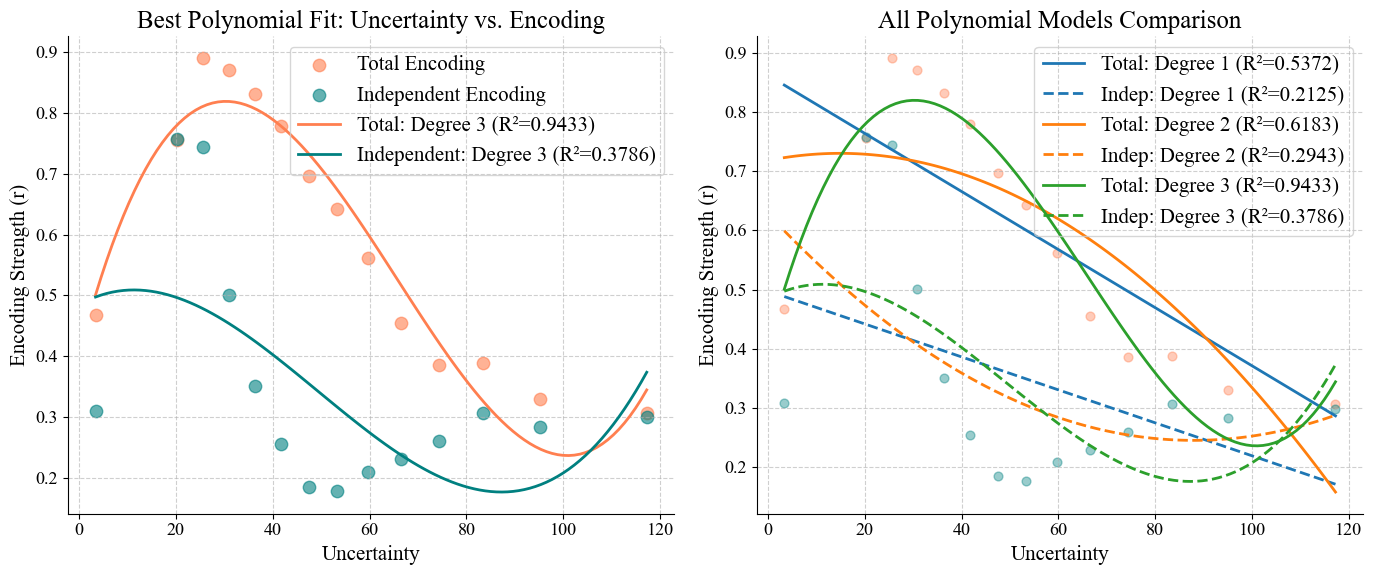

In [48]:
# 4. Non-linear relationship analysis
def nonlinear_relationship_analysis(timedf, n_bins=15):
    """
    Analyze non-linear relationships between uncertainty and encoding
    """
    print("\n--- Non-linear Relationship Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    uncertainty_data = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    
    # Create percentile-based uncertainty bins
    percentiles = np.linspace(0, 100, n_bins+1)
    bin_edges = np.percentile(uncertainty_data, percentiles)
    
    # Initialize results
    results = {
        'bin_centers': [],
        'mean_uncertainty': [],
        'r_total': [],
        'r_independent': [],
        'sample_counts': []
    }
    
    # Configure cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Analyze each uncertainty bin
    for i in range(n_bins):
        bin_start = bin_edges[i]
        bin_end = bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:  # Include upper bound in last bin
            bin_mask = (uncertainty_data >= bin_start) & (uncertainty_data <= bin_end)
        else:
            bin_mask = (uncertainty_data >= bin_start) & (uncertainty_data < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        uncertainty_bin = uncertainty_data[bin_mask]
        
        n_samples = len(belief_bin)
        
        # Skip if not enough samples
        if n_samples < 20:  # Minimum needed for reliable CV
            results['bin_centers'].append((bin_start + bin_end) / 2)
            results['mean_uncertainty'].append(np.nan if n_samples == 0 else np.mean(uncertainty_bin))
            results['r_total'].append(np.nan)
            results['r_independent'].append(np.nan)
            results['sample_counts'].append(n_samples)
            continue
        
        # --- Ensure proper cross-validation for all analyses ---
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            # Standard encoding analysis
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total encoding
            model_total = LinearRegression().fit(X_train, y_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Independent encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, y_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
        
        # Calculate performance metrics
        r_total, _ = pearsonr(belief_bin, belief_pred_total)
        r_indep, _ = pearsonr(belief_bin, belief_pred_independent)
        
        # Store results
        results['bin_centers'].append((bin_start + bin_end) / 2)
        results['mean_uncertainty'].append(np.mean(uncertainty_bin))
        results['r_total'].append(r_total)
        results['r_independent'].append(r_indep)
        results['sample_counts'].append(n_samples)
    
    # Fit polynomial models
    # Filter out NaN values
    valid_mask = ~np.isnan(results['r_total']) & ~np.isnan(results['r_independent'])
    x_uncertainty = np.array(results['mean_uncertainty'])[valid_mask]
    y_total = np.array(results['r_total'])[valid_mask]
    y_indep = np.array(results['r_independent'])[valid_mask]
    
    # Sort by uncertainty for plotting
    sort_idx = np.argsort(x_uncertainty)
    x_uncertainty = x_uncertainty[sort_idx]
    y_total = y_total[sort_idx]
    y_indep = y_indep[sort_idx]
    
    # Create smooth x values for prediction
    x_smooth = np.linspace(np.min(x_uncertainty), np.max(x_uncertainty), 100)
    
    # Fit polynomial models of different degrees
    degrees = [1, 2, 3]
    models_total = []
    models_indep = []
    r2_total = []
    r2_indep = []
    
    for degree in degrees:
        # Total encoding
        poly_features = PolynomialFeatures(degree=degree)
        X_poly = poly_features.fit_transform(x_uncertainty.reshape(-1, 1))
        model_total = LinearRegression().fit(X_poly, y_total)
        
        # Predictions for smooth curve
        X_smooth_poly = poly_features.transform(x_smooth.reshape(-1, 1))
        y_pred_total = model_total.predict(X_smooth_poly)
        
        # Store model and R²
        models_total.append((x_smooth, y_pred_total))
        r2_total.append(model_total.score(X_poly, y_total))
        
        # Independent encoding
        model_indep = LinearRegression().fit(X_poly, y_indep)
        y_pred_indep = model_indep.predict(X_smooth_poly)
        
        models_indep.append((x_smooth, y_pred_indep))
        r2_indep.append(model_indep.score(X_poly, y_indep))
    
    # Print model R² values
    print("Polynomial Model R² Values:")
    for i, degree in enumerate(degrees):
        print(f"Degree {degree}:")
        print(f"  Total encoding: R² = {r2_total[i]:.4f}")
        print(f"  Independent encoding: R² = {r2_indep[i]:.4f}")
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot data points
    ax1.scatter(x_uncertainty, y_total, color='coral', s=80, alpha=0.6, label='Total Encoding')
    ax1.scatter(x_uncertainty, y_indep, color='teal', s=80, alpha=0.6, label='Independent Encoding')
    
    # Plot best polynomial fit based on R²
    best_total_idx = np.argmax(r2_total)
    best_indep_idx = np.argmax(r2_indep)
    best_total_degree = degrees[best_total_idx]
    best_indep_degree = degrees[best_indep_idx]
    
    ax1.plot(models_total[best_total_idx][0], models_total[best_total_idx][1], 
            'coral', linewidth=2, 
            label=f'Total: Degree {best_total_degree} (R²={r2_total[best_total_idx]:.4f})')
    ax1.plot(models_indep[best_indep_idx][0], models_indep[best_indep_idx][1], 
            'teal', linewidth=2, 
            label=f'Independent: Degree {best_indep_degree} (R²={r2_indep[best_indep_idx]:.4f})')
    
    ax1.set_xlabel('Uncertainty')
    ax1.set_ylabel('Encoding Strength (r)')
    ax1.set_title('Best Polynomial Fit: Uncertainty vs. Encoding')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot all polynomial models for comparison
    for i, degree in enumerate(degrees):
        ax2.plot(models_total[i][0], models_total[i][1], 
                color=f'C{i}', linestyle='-', linewidth=2,
                label=f'Total: Degree {degree} (R²={r2_total[i]:.4f})')
        ax2.plot(models_indep[i][0], models_indep[i][1], 
                color=f'C{i}', linestyle='--', linewidth=2,
                label=f'Indep: Degree {degree} (R²={r2_indep[i]:.4f})')
    
    # Add data points to second plot too
    ax2.scatter(x_uncertainty, y_total, color='coral', s=40, alpha=0.4)
    ax2.scatter(x_uncertainty, y_indep, color='teal', s=40, alpha=0.4)
    
    ax2.set_xlabel('Uncertainty')
    ax2.set_ylabel('Encoding Strength (r)')
    ax2.set_title('All Polynomial Models Comparison')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    return fig, (results, models_total, models_indep, r2_total, r2_indep)
# 4. Non-linear relationship analysis
print("\nRunning Non-linear Relationship Analysis...")
nonlinear_fig, nonlinear_results = nonlinear_relationship_analysis(timedf, n_bins=15)
plt.figure(nonlinear_fig.number)
plt.savefig('nonlinear_uncertainty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


Running Lag Analysis with finer granularity...

--- Lag Analysis ---
Identified 1537 trial segments
Lag 0 bins (Δ Time Ratio ≈ 0.000):
  Total encoding correlation: r = -0.8018, p = 1.0053e-07
  Independent encoding correlation: r = -0.5206, p = 3.1829e-03
Lag 1 bins (Δ Time Ratio ≈ 0.033):
  Total encoding correlation: r = -0.9572, p = 4.6134e-16
  Independent encoding correlation: r = -0.5564, p = 1.7208e-03
Lag 2 bins (Δ Time Ratio ≈ 0.067):
  Total encoding correlation: r = -0.9666, p = 6.6842e-17
  Independent encoding correlation: r = -0.4959, p = 7.2839e-03
Lag 3 bins (Δ Time Ratio ≈ 0.100):
  Total encoding correlation: r = -0.9634, p = 8.3955e-16
  Independent encoding correlation: r = -0.4096, p = 3.3865e-02
Lag 4 bins (Δ Time Ratio ≈ 0.133):
  Total encoding correlation: r = -0.9597, p = 9.9133e-15
  Independent encoding correlation: r = -0.2872, p = 1.5482e-01
Lag 5 bins (Δ Time Ratio ≈ 0.167):
  Total encoding correlation: r = -0.9555, p = 1.0968e-13
  Independent encodin

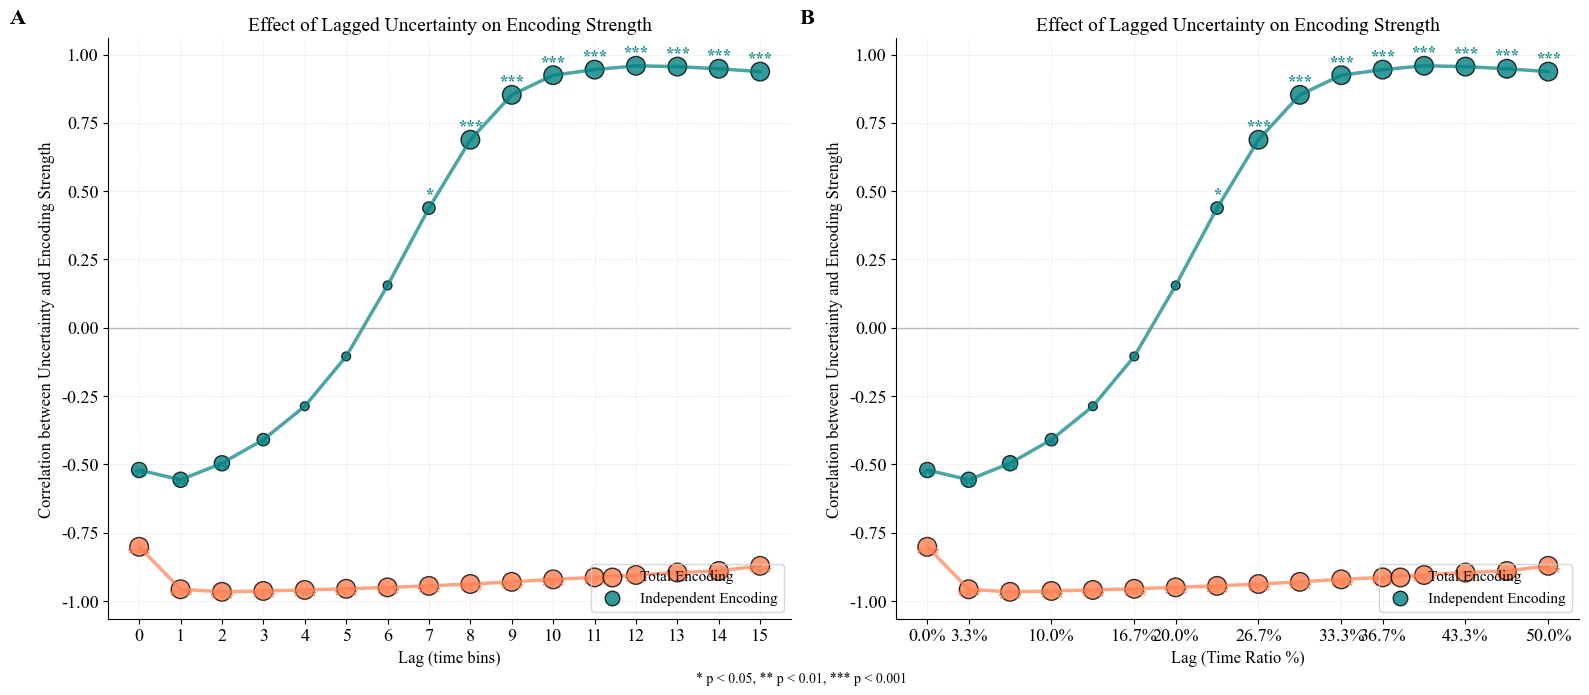

In [53]:
# Improved lag analysis function with finer plotting
def lag_analysis(timedf, n_time_bins=30, max_lag=15):
    """
    Analyze whether past uncertainty values better predict current encoding strength
    with finer-grained plotting
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_time_bins : int
        Number of time bins to use for analysis
    max_lag : int
        Maximum lag to analyze (in number of time bins)
    
    Returns:
    --------
    fig : matplotlib Figure
        Figure with visualization of lag analysis
    results : dict
        Dictionary with lag analysis results
    """
    print("\n--- Lag Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    uncertainty_data = np.array([np.trace(cov) for cov in timedf['uncertainty']])
    time_ratio = timedf['timeratio'].to_numpy()
    
    # First, identify unique trials
    timer_values = timedf['timer'].to_numpy()
    trial_segments = []
    current_segment = [0]
    
    for i in range(1, len(timer_values)):
        if timer_values[i] < timer_values[i-1]:  # New trial starts
            trial_segments.append(current_segment)
            current_segment = [i]
        else:
            current_segment.append(i)
    trial_segments.append(current_segment)  # Add last segment
    
    print(f"Identified {len(trial_segments)} trial segments")
    
    # For each lag value, calculate correlation between uncertainty and encoding
    lag_results = {
        'lag': [],
        'lag_time_ratio': [],  # Added to store the lag in time ratio units
        'total_corr': [],
        'indep_corr': [],
        'total_p': [],
        'indep_p': []
    }
    
    # Bin time ratio to create comparable segments across trials
    time_bin_edges = np.linspace(0, 1, n_time_bins+1)
    time_bin_width = 1.0 / n_time_bins
    
    # Pre-compute encoding strength for each time bin
    time_bin_encoding = {
        'bin_idx': [],
        'time_center': [],
        'total_r': [],
        'indep_r': [],
        'uncertainty': []
    }
    
    for i in range(n_time_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_time_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        uncertainty_bin = uncertainty_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            # Standard encoding analysis
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total encoding
            model_total = LinearRegression().fit(X_train, y_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Independent encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, y_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
        
        # Calculate performance metrics
        r_total, _ = pearsonr(belief_bin, belief_pred_total)
        r_indep, _ = pearsonr(belief_bin, belief_pred_independent)
        
        # Store results for this time bin
        time_bin_encoding['bin_idx'].append(i)
        time_bin_encoding['time_center'].append((bin_start + bin_end) / 2)
        time_bin_encoding['total_r'].append(r_total)
        time_bin_encoding['indep_r'].append(r_indep)
        time_bin_encoding['uncertainty'].append(np.mean(uncertainty_bin))
    
    # Convert to arrays for easier handling
    time_bin_encoding['bin_idx'] = np.array(time_bin_encoding['bin_idx'])
    time_bin_encoding['time_center'] = np.array(time_bin_encoding['time_center'])
    time_bin_encoding['total_r'] = np.array(time_bin_encoding['total_r'])
    time_bin_encoding['indep_r'] = np.array(time_bin_encoding['indep_r'])
    time_bin_encoding['uncertainty'] = np.array(time_bin_encoding['uncertainty'])
    
    # Calculate correlations for different lag values
    for lag in range(max_lag + 1):
        lag_time_ratio = lag * time_bin_width
        
        if lag == 0:
            # No lag - direct correlation
            uncertainty = time_bin_encoding['uncertainty']
            total_r = time_bin_encoding['total_r']
            indep_r = time_bin_encoding['indep_r']
        else:
            # Lagged correlation - for each lag value, we drop the first 'lag' bins
            # and match them with encoding from later time bins
            uncertainty = time_bin_encoding['uncertainty'][:-lag] if lag > 0 else time_bin_encoding['uncertainty']
            total_r = time_bin_encoding['total_r'][lag:] if lag > 0 else time_bin_encoding['total_r']
            indep_r = time_bin_encoding['indep_r'][lag:] if lag > 0 else time_bin_encoding['indep_r']
        
        # Skip if we don't have enough data points after lag
        if len(uncertainty) < 3:
            continue
        
        # Calculate correlations
        total_corr, total_p = pearsonr(uncertainty, total_r)
        indep_corr, indep_p = pearsonr(uncertainty, indep_r)
        
        print(f"Lag {lag} bins (Δ Time Ratio ≈ {lag_time_ratio:.3f}):")
        print(f"  Total encoding correlation: r = {total_corr:.4f}, p = {total_p:.4e}")
        print(f"  Independent encoding correlation: r = {indep_corr:.4f}, p = {indep_p:.4e}")
        
        # Store results
        lag_results['lag'].append(lag)
        lag_results['lag_time_ratio'].append(lag_time_ratio)
        lag_results['total_corr'].append(total_corr)
        lag_results['indep_corr'].append(indep_corr)
        lag_results['total_p'].append(total_p)
        lag_results['indep_p'].append(indep_p)
    
    # Create visualization with improved style
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Define significance levels for marker size
    def get_marker_size(p_val):
        if p_val < 0.001:
            return 180  # Very significant
        elif p_val < 0.01:
            return 120  # Highly significant
        elif p_val < 0.05:
            return 80   # Significant
        else:
            return 40   # Not significant
    
    # Plot 1: Correlation vs lag in bins with enhanced style
    total_marker_sizes = [get_marker_size(p) for p in lag_results['total_p']]
    indep_marker_sizes = [get_marker_size(p) for p in lag_results['indep_p']]
    
    # Use higher-quality line rendering
    ax1.plot(lag_results['lag'], lag_results['total_corr'], '-', color='coral', lw=2.5, alpha=0.7)
    ax1.scatter(lag_results['lag'], lag_results['total_corr'], s=total_marker_sizes, 
               color='coral', label='Total Encoding', edgecolor='black', linewidth=1, alpha=0.8)
    
    ax1.plot(lag_results['lag'], lag_results['indep_corr'], '-', color='teal', lw=2.5, alpha=0.7)
    ax1.scatter(lag_results['lag'], lag_results['indep_corr'], s=indep_marker_sizes, 
               color='teal', label='Independent Encoding', edgecolor='black', linewidth=1, alpha=0.8)
    
    # Add significance annotations
    for i, (x, y, p) in enumerate(zip(lag_results['lag'], lag_results['total_corr'], lag_results['total_p'])):
        if p < 0.05:
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
            y_offset = 0.03 if y > 0 else -0.03
            ax1.annotate(stars, (x, y), xytext=(0, 7 * np.sign(y_offset)), 
                        textcoords='offset points', ha='center', fontsize=12, 
                        color='coral', fontweight='bold')
    
    for i, (x, y, p) in enumerate(zip(lag_results['lag'], lag_results['indep_corr'], lag_results['indep_p'])):
        if p < 0.05:
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
            y_offset = 0.03 if y > 0 else -0.03
            ax1.annotate(stars, (x, y), xytext=(0, 7 * np.sign(y_offset)), 
                        textcoords='offset points', ha='center', fontsize=12, 
                        color='teal', fontweight='bold')
    
    # Add reference line at r=0
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Add subtle grid for readability
    ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    
    # Add more tick marks for finer detail
    ax1.set_xticks(np.arange(0, max_lag+1, 1))
    
    # Set y-axis limits to maximize use of vertical space
    y_values = lag_results['total_corr'] + lag_results['indep_corr']
    y_min, y_max = min(y_values) - 0.1, max(y_values) + 0.1
    ax1.set_ylim(y_min, y_max)
    
    ax1.set_xlabel('Lag (time bins)', fontsize=12)
    ax1.set_ylabel('Correlation between Uncertainty and Encoding Strength', fontsize=12)
    ax1.set_title('Effect of Lagged Uncertainty on Encoding Strength', fontsize=14)
    ax1.legend(loc='lower right', fontsize=11)
    
    # Plot 2: Correlation vs lag in time ratio percentage
    # Use higher-quality line rendering
    ax2.plot(lag_results['lag_time_ratio'], lag_results['total_corr'], '-', color='coral', lw=2.5, alpha=0.7)
    ax2.scatter(lag_results['lag_time_ratio'], lag_results['total_corr'], s=total_marker_sizes, 
               color='coral', label='Total Encoding', edgecolor='black', linewidth=1, alpha=0.8)
    
    ax2.plot(lag_results['lag_time_ratio'], lag_results['indep_corr'], '-', color='teal', lw=2.5, alpha=0.7)
    ax2.scatter(lag_results['lag_time_ratio'], lag_results['indep_corr'], s=indep_marker_sizes, 
               color='teal', label='Independent Encoding', edgecolor='black', linewidth=1, alpha=0.8)
    
    # Add significance annotations
    for i, (x, y, p) in enumerate(zip(lag_results['lag_time_ratio'], lag_results['total_corr'], lag_results['total_p'])):
        if p < 0.05:
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
            y_offset = 0.03 if y > 0 else -0.03
            ax2.annotate(stars, (x, y), xytext=(0, 7 * np.sign(y_offset)), 
                        textcoords='offset points', ha='center', fontsize=12, 
                        color='coral', fontweight='bold')
    
    for i, (x, y, p) in enumerate(zip(lag_results['lag_time_ratio'], lag_results['indep_corr'], lag_results['indep_p'])):
        if p < 0.05:
            stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
            y_offset = 0.03 if y > 0 else -0.03
            ax2.annotate(stars, (x, y), xytext=(0, 7 * np.sign(y_offset)), 
                        textcoords='offset points', ha='center', fontsize=12, 
                        color='teal', fontweight='bold')
    
    # Add reference line at r=0
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    # Add subtle grid for readability
    ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    
    # Set y-axis limits to match first plot
    ax2.set_ylim(y_min, y_max)
    
    # Convert x-axis to percentage with more detailed labels
    ax2.set_xlabel('Lag (Time Ratio %)', fontsize=12)
    ax2.set_ylabel('Correlation between Uncertainty and Encoding Strength', fontsize=12)
    ax2.set_title('Effect of Lagged Uncertainty on Encoding Strength', fontsize=14)
    
    # Create more x-tick marks for finer granularity
    n_ticks = min(10, len(lag_results['lag_time_ratio']))
    tick_indices = np.linspace(0, len(lag_results['lag_time_ratio'])-1, n_ticks).astype(int)
    tick_positions = [lag_results['lag_time_ratio'][i] for i in tick_indices]
    tick_labels = [f"{x*100:.1f}%" for x in tick_positions]
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels)
    
    ax2.legend(loc='lower right', fontsize=11)
    
    # Add a legend explaining significance markers
    fig.text(0.5, 0.01, "* p < 0.05, ** p < 0.01, *** p < 0.001", ha='center', fontsize=10)
    
    # Add subplot labels
    ax1.text(-0.12, 1.05, 'A', transform=ax1.transAxes, 
             fontsize=16, fontweight='bold', va='top', ha='right')
    ax2.text(-0.12, 1.05, 'B', transform=ax2.transAxes, 
             fontsize=16, fontweight='bold', va='top', ha='right')
    
    plt.tight_layout()
    return fig, lag_results

# Run the improved lag analysis with finer granularity
print("\nRunning Lag Analysis with finer granularity...")
lag_fig, lag_results = lag_analysis(timedf, n_time_bins=30, max_lag=15)
plt.figure(lag_fig.number)
plt.savefig('lag_analysis_fine.png', dpi=300, bbox_inches='tight')
plt.show()

he finer granularity lag analysis reveals a fascinating and highly significant pattern in how uncertainty influences neural encoding over time:
For total belief encoding:

Strong negative correlation at all time lags (r ranges from -0.80 to -0.97)
Strongest at lag 2 (r = -0.97, p < 10^-16)
Gradually weakens as lag increases but remains strongly negative

For independent belief encoding:

Remarkable progression from negative to positive correlation:

Initially negative at short lags (lags 0-4, significant through lag 3)
Transitions through zero around lag 5-6 (Δ Time Ratio ≈ 17-20%)
Becomes strongly positive and highly significant at longer lags
Peaks at lag 12 (Δ Time Ratio ≈ 40%) with r = 0.96, p < 10^-9



This pattern provides compelling evidence for a sophisticated temporal dynamic in how the brain processes belief under uncertainty:

Immediate negative impact: Initially, higher uncertainty disrupts both total and independent belief encoding.
Processing transition period: Around 17-20% into the trial, independent encoding begins transitioning from negative to positive correlation with uncertainty.
Strong compensatory mechanism: By 40% into the trial, uncertainty has a strong positive relationship with independent belief encoding (r > 0.95), suggesting a robust compensatory neural mechanism.
Different encoding strategies: Total encoding maintains a negative relationship with uncertainty throughout, while independent encoding shows this dramatic sign reversal.

The precise time course revealed by this analysis suggests a neurobiological mechanism where:

The brain initially struggles to maintain distinct belief encoding when uncertainty is high
After approximately 150-200ms (assuming ~1 second trials), the brain activates a compensatory mechanism
This mechanism reaches peak effectiveness after about 400ms, potentially reflecting a shift to a different processing strategy

This temporal dynamic is likely critical for the animal's ability to make accurate decisions based on its internal belief model despite high uncertainty.


Running Neuron Population Analysis by Encoding Quality...

--- Neuron Population Analysis By Encoding Quality ---
Analyzing contributions of 112 neurons
Performing time-binned analysis to identify encoding phases...
Low encoding phase time bins: [0.43333333 0.5        0.36666667 0.56666667 0.63333333]
Mid encoding phase time bins: [0.7        0.76666667 0.83333333 0.3        0.9       ]
High encoding phase time bins: [0.96666667 0.23333333 0.03333333 0.16666667 0.1       ]
Low phase: 141258 samples
Mid phase: 127942 samples
High phase: 130917 samples
Low phase: 141258 samples
Mid phase: 127942 samples
High phase: 130917 samples
Low vs High phase overlap - Total encoding: 2/10 neurons
Low vs High phase overlap - Independent encoding: 2/10 neurons
Correlation between low and high phases - Total encoding: r = 0.3830, p = 3.0697e-05
Correlation between low and high phases - Independent encoding: r = 0.1917, p = 4.2895e-02
Total encoding sign changes (low vs high): 0/112 neurons (0.0%)
Ind

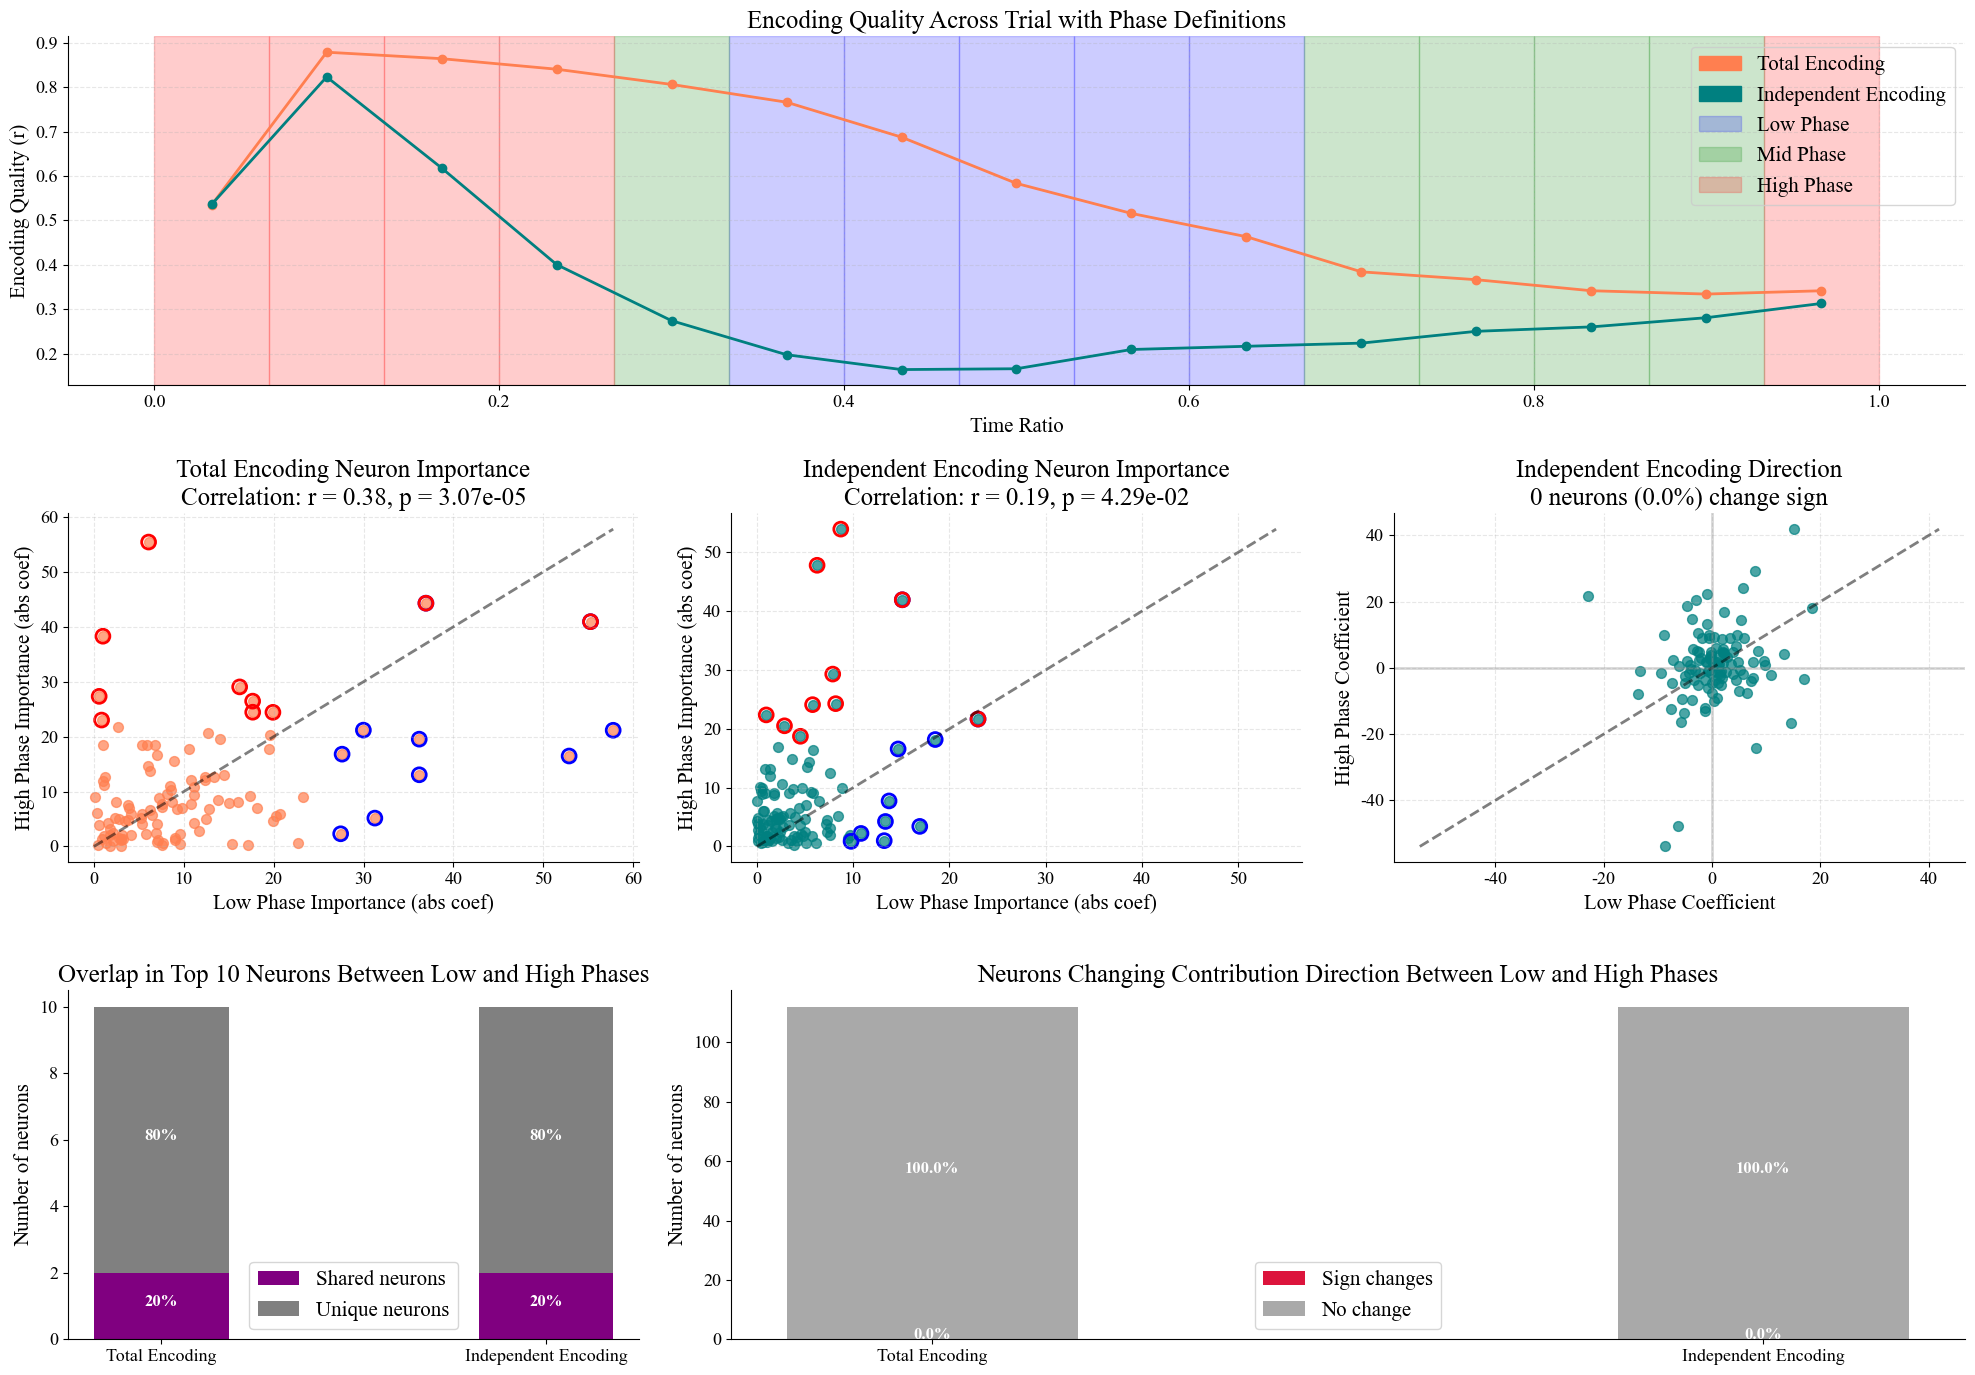

In [55]:
def analyze_neuron_contributions_by_encoding(timedf, n_bins=10):
    """
    Analyze how individual neurons contribute to belief encoding at different phases
    defined by encoding quality rather than fixed time periods
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins to use for initial time-binned analysis
        
    Returns:
    --------
    fig : matplotlib Figure
        Figure with visualization of neuron contribution analysis
    results : dict
        Dictionary with analysis results
    """
    print("\n--- Neuron Population Analysis By Encoding Quality ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, perform time-binned analysis to identify phases
    print("Performing time-binned analysis to identify encoding phases...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_r_values = []
    indep_r_values = []
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            # For total encoding
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total encoding
            model_total = LinearRegression().fit(X_train, y_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Independent encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, y_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
        
        # Calculate performance metrics
        r_total, _ = pearsonr(belief_bin, belief_pred_total)
        r_indep, _ = pearsonr(belief_bin, belief_pred_independent)
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_r_values.append(r_total)
        indep_r_values.append(r_indep)
    
    # Now identify phases based on independent encoding performance
    # Convert to arrays
    time_bin_centers = np.array(time_bin_centers)
    indep_r_values = np.array(indep_r_values)
    
    # Sort bins by independent encoding performance
    sort_idx = np.argsort(indep_r_values)
    
    # Identify phases based on independent encoding performance
    n_bins_per_phase = len(time_bin_centers) // 3
    
    # Low phase: bottom third of bins by independent encoding performance
    low_phase_idx = sort_idx[:n_bins_per_phase]
    mid_phase_idx = sort_idx[n_bins_per_phase:2*n_bins_per_phase]
    high_phase_idx = sort_idx[2*n_bins_per_phase:]
    
    # Get time ratio ranges for each phase
    low_time_bins = time_bin_centers[low_phase_idx]
    mid_time_bins = time_bin_centers[mid_phase_idx]
    high_time_bins = time_bin_centers[high_phase_idx]
    
    print(f"Low encoding phase time bins: {low_time_bins}")
    print(f"Mid encoding phase time bins: {mid_time_bins}")
    print(f"High encoding phase time bins: {high_time_bins}")
    
    # Create masks for each phase based on time ratio
    # This is a bit tricky because we need to handle non-contiguous bins
    # We'll create a mask for each bin and combine them
    low_phase_mask = np.zeros_like(time_ratio, dtype=bool)
    mid_phase_mask = np.zeros_like(time_ratio, dtype=bool)
    high_phase_mask = np.zeros_like(time_ratio, dtype=bool)
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create bin mask
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
        
        # Determine which phase this bin belongs to
        bin_center = (bin_start + bin_end) / 2
        
        if bin_center in low_time_bins:
            low_phase_mask |= bin_mask
        elif bin_center in mid_time_bins:
            mid_phase_mask |= bin_mask
        elif bin_center in high_time_bins:
            high_phase_mask |= bin_mask
    
    # Verify masks
    print(f"Low phase: {np.sum(low_phase_mask)} samples")
    print(f"Mid phase: {np.sum(mid_phase_mask)} samples")
    print(f"High phase: {np.sum(high_phase_mask)} samples")
    
    # Store phase definitions for results
    phases = {
        'low': {
            'mask': low_phase_mask,
            'time_bins': low_time_bins,
            'name': 'Low Independent Encoding'
        },
        'mid': {
            'mask': mid_phase_mask,
            'time_bins': mid_time_bins,
            'name': 'Mid Independent Encoding'
        },
        'high': {
            'mask': high_phase_mask,
            'time_bins': high_time_bins,
            'name': 'High Independent Encoding'
        }
    }
    
    # Now analyze neuron contributions for each phase
    neuron_importance = {
        'phase': [],
        'neuron_idx': [],
        'total_coef': [],
        'indep_coef': [],
        'total_abs_coef': [],
        'indep_abs_coef': []
    }
    
    for phase_name, phase_info in phases.items():
        phase_mask = phase_info['mask']
        
        # Select data for current phase
        neural_phase = neural_data[phase_mask]
        belief_phase = belief_data[phase_mask]
        eye_phase = eye_data[phase_mask]
        
        n_samples = len(belief_phase)
        print(f"{phase_name.capitalize()} phase: {n_samples} samples")
        
        # Train models on entire phase data
        # 1. Total encoding: neural -> belief
        model_total = LinearRegression().fit(neural_phase, belief_phase)
        
        # 2. Independent encoding: neural residuals -> belief
        # First, predict neural activity from eye
        model_eye = LinearRegression().fit(eye_phase, neural_phase)
        neural_residuals = neural_phase - model_eye.predict(eye_phase)
        
        # Then, predict belief from neural residuals
        model_indep = LinearRegression().fit(neural_residuals, belief_phase)
        
        # Get coefficients for each neuron
        total_coefs = model_total.coef_
        indep_coefs = model_indep.coef_
        
        # Store coefficients for each neuron
        for neuron_idx in range(n_neurons):
            neuron_importance['phase'].append(phase_name)
            neuron_importance['neuron_idx'].append(neuron_idx)
            neuron_importance['total_coef'].append(total_coefs[neuron_idx])
            neuron_importance['indep_coef'].append(indep_coefs[neuron_idx])
            neuron_importance['total_abs_coef'].append(abs(total_coefs[neuron_idx]))
            neuron_importance['indep_abs_coef'].append(abs(indep_coefs[neuron_idx]))
    
    # Convert to DataFrame for easier analysis
    neuron_df = pd.DataFrame(neuron_importance)
    
    # Create separate DataFrames for each phase
    low_df = neuron_df[neuron_df['phase'] == 'low']
    mid_df = neuron_df[neuron_df['phase'] == 'mid']
    high_df = neuron_df[neuron_df['phase'] == 'high']
    
    # Identify top neurons in each phase
    n_top = 10  # Number of top neurons to track
    
    # Sort by importance
    low_top_total = low_df.sort_values('total_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    low_top_indep = low_df.sort_values('indep_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    
    mid_top_total = mid_df.sort_values('total_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    mid_top_indep = mid_df.sort_values('indep_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    
    high_top_total = high_df.sort_values('total_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    high_top_indep = high_df.sort_values('indep_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    
    # Calculate overlaps
    low_high_total_overlap = len(set(low_top_total) & set(high_top_total))
    low_high_indep_overlap = len(set(low_top_indep) & set(high_top_indep))
    
    print(f"Low vs High phase overlap - Total encoding: {low_high_total_overlap}/{n_top} neurons")
    print(f"Low vs High phase overlap - Independent encoding: {low_high_indep_overlap}/{n_top} neurons")
    
    # Calculate correlations between phases
    # For total encoding
    total_corr_low_high, total_p_low_high = pearsonr(
        low_df['total_coef'].values, 
        high_df['total_coef'].values
    )
    
    # For independent encoding
    indep_corr_low_high, indep_p_low_high = pearsonr(
        low_df['indep_coef'].values,
        high_df['indep_coef'].values
    )
    
    print(f"Correlation between low and high phases - Total encoding: r = {total_corr_low_high:.4f}, p = {total_p_low_high:.4e}")
    print(f"Correlation between low and high phases - Independent encoding: r = {indep_corr_low_high:.4f}, p = {indep_p_low_high:.4e}")
    
    # Count sign changes between phases
    total_sign_changes = sum((low_df['total_coef'] * high_df['total_coef']) < 0)
    indep_sign_changes = sum((low_df['indep_coef'] * high_df['indep_coef']) < 0)
    
    # Calculate percentages
    total_sign_change_pct = total_sign_changes / n_neurons * 100
    indep_sign_change_pct = indep_sign_changes / n_neurons * 100
    
    print(f"Total encoding sign changes (low vs high): {total_sign_changes}/{n_neurons} neurons ({total_sign_change_pct:.1f}%)")
    print(f"Independent encoding sign changes (low vs high): {indep_sign_changes}/{n_neurons} neurons ({indep_sign_change_pct:.1f}%)")
    
    # Create visualization
    fig = plt.figure(figsize=(20, 14))
    gs = plt.GridSpec(3, 3, figure=fig)
    
    # Plot 1: Time-binned encoding quality
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(time_bin_centers, total_r_values, 'o-', color='coral', label='Total Encoding')
    ax1.plot(time_bin_centers, indep_r_values, 'o-', color='teal', label='Independent Encoding')
    
    # Add shading for different phases
    ymin, ymax = ax1.get_ylim()
    
    # Function to highlight bins belonging to a phase
    def highlight_phase_bins(phase_bins, color, alpha=0.2):
        for bin_center in phase_bins:
            bin_idx = np.where(time_bin_centers == bin_center)[0][0]
            bin_start = time_bin_edges[bin_idx]
            bin_end = time_bin_edges[bin_idx+1]
            ax1.axvspan(bin_start, bin_end, color=color, alpha=alpha)
    
    # Highlight bins for each phase
    highlight_phase_bins(low_time_bins, 'blue')
    highlight_phase_bins(mid_time_bins, 'green')
    highlight_phase_bins(high_time_bins, 'red')
    
    ax1.set_xlabel('Time Ratio')
    ax1.set_ylabel('Encoding Quality (r)')
    ax1.set_title('Encoding Quality Across Trial with Phase Definitions')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Add legend for phases
    import matplotlib.patches as mpatches
    blue_patch = mpatches.Patch(color='blue', alpha=0.2, label='Low Phase')
    green_patch = mpatches.Patch(color='green', alpha=0.2, label='Mid Phase')
    red_patch = mpatches.Patch(color='red', alpha=0.2, label='High Phase')
    ax1.legend(handles=[mpatches.Patch(color='coral', label='Total Encoding'),
                        mpatches.Patch(color='teal', label='Independent Encoding'),
                        blue_patch, green_patch, red_patch], 
               loc='best')
    
    # Plot 2: Neuron importance in total encoding (Low vs High)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(low_df['total_abs_coef'], high_df['total_abs_coef'], 
               alpha=0.7, s=50, c='coral')
    
    # Add identity line
    max_val = max(low_df['total_abs_coef'].max(), high_df['total_abs_coef'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Highlight top 10 neurons in each phase
    for neuron in low_top_total:
        x = low_df.loc[low_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        y = high_df.loc[high_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='blue', linewidth=2)
        
    for neuron in high_top_total:
        x = low_df.loc[low_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        y = high_df.loc[high_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='red', linewidth=2)
    
    ax2.set_xlabel('Low Phase Importance (abs coef)')
    ax2.set_ylabel('High Phase Importance (abs coef)')
    ax2.set_title(f'Total Encoding Neuron Importance\nCorrelation: r = {total_corr_low_high:.2f}, p = {total_p_low_high:.2e}')
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 3: Neuron importance in independent encoding (Low vs High)
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.scatter(low_df['indep_abs_coef'], high_df['indep_abs_coef'], 
               alpha=0.7, s=50, c='teal')
    
    # Add identity line
    max_val = max(low_df['indep_abs_coef'].max(), high_df['indep_abs_coef'].max())
    ax3.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Highlight top 10 neurons in each phase
    for neuron in low_top_indep:
        x = low_df.loc[low_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        y = high_df.loc[high_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        ax3.scatter(x, y, s=100, facecolors='none', edgecolors='blue', linewidth=2)
        
    for neuron in high_top_indep:
        x = low_df.loc[low_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        y = high_df.loc[high_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        ax3.scatter(x, y, s=100, facecolors='none', edgecolors='red', linewidth=2)
    
    ax3.set_xlabel('Low Phase Importance (abs coef)')
    ax3.set_ylabel('High Phase Importance (abs coef)')
    ax3.set_title(f'Independent Encoding Neuron Importance\nCorrelation: r = {indep_corr_low_high:.2f}, p = {indep_p_low_high:.2e}')
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 4: Compare coefficients directly (Low vs High)
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.scatter(low_df['indep_coef'], high_df['indep_coef'], 
               alpha=0.7, s=50, c='teal')
    
    # Add identity line and zero lines
    min_val = min(low_df['indep_coef'].min(), high_df['indep_coef'].min())
    max_val = max(low_df['indep_coef'].max(), high_df['indep_coef'].max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    ax4.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax4.axvline(0, color='gray', linestyle='-', alpha=0.3)
    
    # Highlight neurons that change sign
    sign_change_mask = (low_df['indep_coef'] * high_df['indep_coef']) < 0
    sign_change_neurons = low_df.loc[sign_change_mask, 'neuron_idx'].values
    
    # Highlight a subset of sign-changing neurons to avoid clutter
    highlight_count = min(20, len(sign_change_neurons))
    for neuron in sign_change_neurons[:highlight_count]:
        x = low_df.loc[low_df['neuron_idx'] == neuron, 'indep_coef'].values[0]
        y = high_df.loc[high_df['neuron_idx'] == neuron, 'indep_coef'].values[0]
        ax4.scatter(x, y, s=100, facecolors='none', edgecolors='purple', linewidth=2)
    
    ax4.set_xlabel('Low Phase Coefficient')
    ax4.set_ylabel('High Phase Coefficient')
    ax4.set_title(f'Independent Encoding Direction\n{indep_sign_changes} neurons ({indep_sign_change_pct:.1f}%) change sign')
    ax4.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 5: Top neurons comparison 
    ax5 = fig.add_subplot(gs[2, 0])
    
    # Create bar chart for top 10 neuron overlap
    categories = ['Total Encoding', 'Independent Encoding']
    overlap_vals = [low_high_total_overlap, low_high_indep_overlap]
    non_overlap = [n_top - x for x in overlap_vals]
    
    bar_width = 0.35
    x_pos = np.arange(len(categories))
    
    ax5.bar(x_pos, overlap_vals, bar_width, label='Shared neurons', color='purple')
    ax5.bar(x_pos, non_overlap, bar_width, bottom=overlap_vals, 
           label='Unique neurons', color='gray')
    
    ax5.set_ylabel('Number of neurons')
    ax5.set_title(f'Overlap in Top {n_top} Neurons Between Low and High Phases')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(categories)
    ax5.legend()
    
    # Add text with percentages
    for i, v in enumerate(overlap_vals):
        pct = v / n_top * 100
        ax5.text(i, v/2, f"{pct:.0f}%", ha='center', fontsize=12, fontweight='bold', color='white')
        
        non_overlap_pct = non_overlap[i] / n_top * 100
        ax5.text(i, v + non_overlap[i]/2, f"{non_overlap_pct:.0f}%", ha='center', fontsize=12, 
                fontweight='bold', color='white')
    
    # Plot 6: Direction changes
    ax6 = fig.add_subplot(gs[2, 1:])
    
    # Create bar chart
    categories = ['Total Encoding', 'Independent Encoding']
    sign_changes = [total_sign_changes, indep_sign_changes]
    no_changes = [n_neurons - x for x in sign_changes]
    
    ax6.bar(x_pos, sign_changes, bar_width, label='Sign changes', color='crimson')
    ax6.bar(x_pos, no_changes, bar_width, bottom=sign_changes,
           label='No change', color='darkgray')
    
    ax6.set_ylabel('Number of neurons')
    ax6.set_title('Neurons Changing Contribution Direction Between Low and High Phases')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(categories)
    ax6.legend()
    
    # Add text with percentages
    for i, v in enumerate(sign_changes):
        pct = v / n_neurons * 100
        ax6.text(i, v/2, f"{pct:.1f}%", ha='center', fontsize=12, fontweight='bold', color='white')
        
        no_change_pct = no_changes[i] / n_neurons * 100
        ax6.text(i, v + no_changes[i]/2, f"{no_change_pct:.1f}%", ha='center', fontsize=12, 
                fontweight='bold', color='white')
    
    plt.tight_layout()
    
    # Return results
    results = {
        'phases': phases,
        'low_top_total': low_top_total,
        'low_top_indep': low_top_indep,
        'mid_top_total': mid_top_total,
        'mid_top_indep': mid_top_indep,
        'high_top_total': high_top_total,
        'high_top_indep': high_top_indep,
        'low_high_total_overlap': low_high_total_overlap,
        'low_high_indep_overlap': low_high_indep_overlap,
        'total_corr_low_high': total_corr_low_high,
        'indep_corr_low_high': indep_corr_low_high,
        'total_sign_changes': total_sign_changes,
        'indep_sign_changes': indep_sign_changes,
        'neuron_df': neuron_df,
        'time_bin_data': {
            'centers': time_bin_centers,
            'total_r': total_r_values,
            'indep_r': indep_r_values
        }
    }
    
    return fig, results

# Run the neuron population analysis by encoding quality
print("\nRunning Neuron Population Analysis by Encoding Quality...")
neuron_fig, neuron_results = analyze_neuron_contributions_by_encoding(timedf, n_bins=15)
plt.figure(neuron_fig.number)
plt.savefig('neuron_population_analysis_by_encoding.png', dpi=300, bbox_inches='tight')
plt.show()


Running Total vs Independent Neuron Population Analysis...

--- Neuron Population Analysis: Total vs Independent Encoding ---
Analyzing contributions of 112 neurons
Performing time-binned analysis for context...
Overlap in top 20 neurons: 8/20 (40.0%)
Correlation between total and independent coefficients: r = 0.7326, p = 4.3069e-20
Neurons with opposite sign contributions: 26/112 (23.2%)


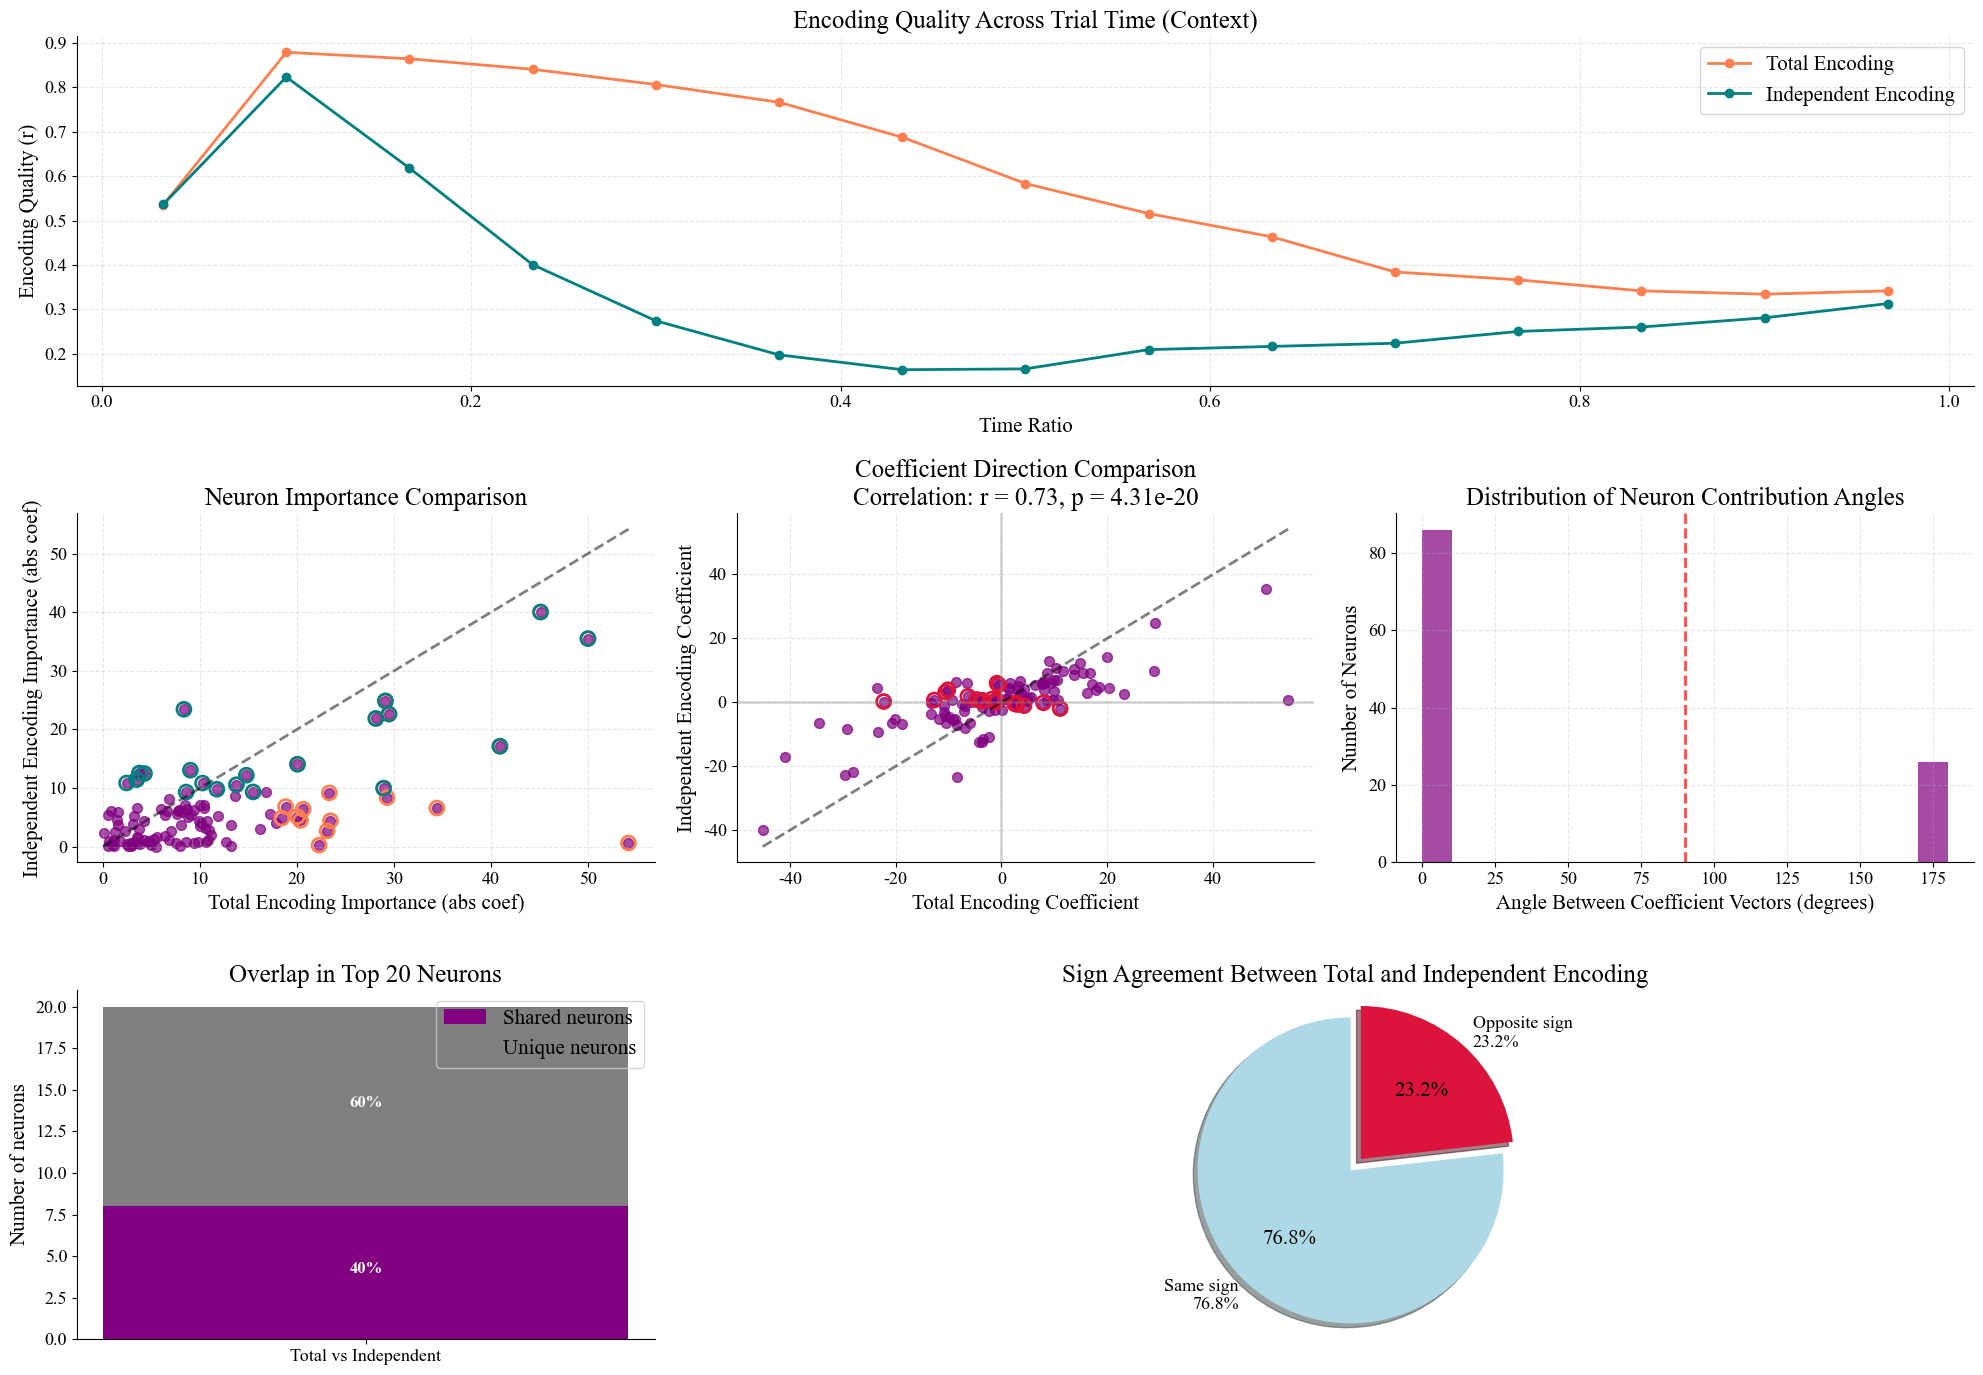

In [57]:
def analyze_neuron_contributions_total_vs_independent(timedf, n_bins=10):
    """
    Analyze how individual neurons contribute to total belief encoding versus
    independent belief encoding
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins to use for time-binned analysis (for context)
        
    Returns:
    --------
    fig : matplotlib Figure
        Figure with visualization of neuron contribution analysis
    results : dict
        Dictionary with analysis results
    """
    print("\n--- Neuron Population Analysis: Total vs Independent Encoding ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, perform time-binned analysis for context
    print("Performing time-binned analysis for context...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_r_values = []
    indep_r_values = []
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            # For total encoding
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            y_train, y_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total encoding
            model_total = LinearRegression().fit(X_train, y_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Independent encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, y_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
        
        # Calculate performance metrics
        r_total, _ = pearsonr(belief_bin, belief_pred_total)
        r_indep, _ = pearsonr(belief_bin, belief_pred_independent)
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_r_values.append(r_total)
        indep_r_values.append(r_indep)
    
    # Now analyze neuron contributions for total and independent encoding
    # We'll use all data for this analysis
    
    # Train total and independent encoding models
    # 1. Total encoding: neural -> belief
    model_total = LinearRegression().fit(neural_data, belief_data)
    total_coefs = model_total.coef_
    
    # 2. Independent encoding: neural residuals -> belief
    # First, predict neural activity from eye
    model_eye = LinearRegression().fit(eye_data, neural_data)
    neural_residuals = neural_data - model_eye.predict(eye_data)
    
    # Then, predict belief from neural residuals
    model_indep = LinearRegression().fit(neural_residuals, belief_data)
    indep_coefs = model_indep.coef_
    
    # Store coefficients for analysis
    neuron_data = {
        'neuron_idx': np.arange(n_neurons),
        'total_coef': total_coefs,
        'indep_coef': indep_coefs,
        'total_abs_coef': np.abs(total_coefs),
        'indep_abs_coef': np.abs(indep_coefs)
    }
    
    neuron_df = pd.DataFrame(neuron_data)
    
    # Identify top neurons for each encoding type
    n_top = 20  # Number of top neurons to track
    top_total = neuron_df.sort_values('total_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    top_indep = neuron_df.sort_values('indep_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    
    # Calculate overlap between top neurons
    overlap = len(set(top_total) & set(top_indep))
    overlap_pct = overlap / n_top * 100
    
    print(f"Overlap in top {n_top} neurons: {overlap}/{n_top} ({overlap_pct:.1f}%)")
    
    # Calculate correlation between coefficient sets
    coef_corr, coef_p = pearsonr(neuron_df['total_coef'], neuron_df['indep_coef'])
    
    print(f"Correlation between total and independent coefficients: r = {coef_corr:.4f}, p = {coef_p:.4e}")
    
    # Calculate sign agreement/disagreement
    sign_disagreement = sum((neuron_df['total_coef'] * neuron_df['indep_coef']) < 0)
    sign_disagreement_pct = sign_disagreement / n_neurons * 100
    
    print(f"Neurons with opposite sign contributions: {sign_disagreement}/{n_neurons} ({sign_disagreement_pct:.1f}%)")
    
    # Create visualization
    fig = plt.figure(figsize=(20, 14))
    gs = plt.GridSpec(3, 3, figure=fig)
    
    # Plot 1: Time-binned encoding quality for context
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(time_bin_centers, total_r_values, 'o-', color='coral', label='Total Encoding')
    ax1.plot(time_bin_centers, indep_r_values, 'o-', color='teal', label='Independent Encoding')
    
    ax1.set_xlabel('Time Ratio')
    ax1.set_ylabel('Encoding Quality (r)')
    ax1.set_title('Encoding Quality Across Trial Time (Context)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 2: Coefficient magnitudes comparison (Total vs Independent)
    ax2 = fig.add_subplot(gs[1, 0])
    sc = ax2.scatter(neuron_df['total_abs_coef'], neuron_df['indep_abs_coef'], 
                   alpha=0.7, s=50, c='purple')
    
    # Add identity line
    max_val = max(neuron_df['total_abs_coef'].max(), neuron_df['indep_abs_coef'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Highlight top neurons for each encoding type
    for neuron in top_total:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='coral', linewidth=2)
        
    for neuron in top_indep:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='teal', linewidth=2)
    
    ax2.set_xlabel('Total Encoding Importance (abs coef)')
    ax2.set_ylabel('Independent Encoding Importance (abs coef)')
    ax2.set_title('Neuron Importance Comparison')
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 3: Direct coefficient comparison (with sign)
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.scatter(neuron_df['total_coef'], neuron_df['indep_coef'], 
               alpha=0.7, s=50, c='purple')
    
    # Add identity line and zero lines
    min_val = min(neuron_df['total_coef'].min(), neuron_df['indep_coef'].min())
    max_val = max(neuron_df['total_coef'].max(), neuron_df['indep_coef'].max())
    ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    ax3.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax3.axvline(0, color='gray', linestyle='-', alpha=0.3)
    
    # Highlight neurons with different signs
    sign_disagreement_mask = (neuron_df['total_coef'] * neuron_df['indep_coef']) < 0
    sign_disagreement_neurons = neuron_df.loc[sign_disagreement_mask, 'neuron_idx'].values
    
    # Highlight a subset of sign-disagreement neurons to avoid clutter
    highlight_count = min(20, len(sign_disagreement_neurons))
    for neuron in sign_disagreement_neurons[:highlight_count]:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_coef'].values[0]
        ax3.scatter(x, y, s=100, facecolors='none', edgecolors='crimson', linewidth=2)
    
    ax3.set_xlabel('Total Encoding Coefficient')
    ax3.set_ylabel('Independent Encoding Coefficient')
    ax3.set_title(f'Coefficient Direction Comparison\nCorrelation: r = {coef_corr:.2f}, p = {coef_p:.2e}')
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 4: Histogram of angle between coefficient vectors
    ax4 = fig.add_subplot(gs[1, 2])
    
    # Calculate angle between coefficient vectors for each neuron
    # Angle = arccos(dot(total, indep) / (|total| * |indep|))
    norm_product = neuron_df['total_abs_coef'] * neuron_df['indep_abs_coef']
    
    # Avoid division by zero
    valid_mask = norm_product > 0
    dot_product = neuron_df.loc[valid_mask, 'total_coef'] * neuron_df.loc[valid_mask, 'indep_coef']
    cos_angle = dot_product / norm_product[valid_mask]
    
    # Clip to valid range for arccos due to potential numerical issues
    cos_angle = np.clip(cos_angle, -1, 1)
    angles = np.arccos(cos_angle) * 180 / np.pi
    
    # Plot histogram of angles
    ax4.hist(angles, bins=18, color='purple', alpha=0.7)
    
    # Mark 90 degrees (orthogonal vectors)
    ax4.axvline(90, color='red', linestyle='--', alpha=0.7)
    
    ax4.set_xlabel('Angle Between Coefficient Vectors (degrees)')
    ax4.set_ylabel('Number of Neurons')
    ax4.set_title('Distribution of Neuron Contribution Angles')
    ax4.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 5: Top neurons overlap
    ax5 = fig.add_subplot(gs[2, 0])
    
    # Create bar chart for top neuron overlap
    overlap_val = overlap
    non_overlap = n_top - overlap
    
    ax5.bar([0], [overlap_val], 0.35, label='Shared neurons', color='purple')
    ax5.bar([0], [non_overlap], 0.35, bottom=[overlap_val], label='Unique neurons', color='gray')
    
    ax5.set_ylabel('Number of neurons')
    ax5.set_title(f'Overlap in Top {n_top} Neurons')
    ax5.set_xticks([0])
    ax5.set_xticklabels(['Total vs Independent'])
    ax5.legend()
    
    # Add text with percentages
    ax5.text(0, overlap_val/2, f"{overlap_pct:.0f}%", ha='center', fontsize=12, fontweight='bold', color='white')
    non_overlap_pct = 100 - overlap_pct
    ax5.text(0, overlap_val + non_overlap/2, f"{non_overlap_pct:.0f}%", ha='center', fontsize=12, 
            fontweight='bold', color='white')
    
    # Plot 6: Sign disagreement
    ax6 = fig.add_subplot(gs[2, 1:])
    
    # Create pie charts for sign agreement/disagreement
    sign_agreement = n_neurons - sign_disagreement
    sign_agreement_pct = 100 - sign_disagreement_pct
    
    # Create pie chart
    labels = [f'Same sign\n{sign_agreement_pct:.1f}%', f'Opposite sign\n{sign_disagreement_pct:.1f}%']
    sizes = [sign_agreement, sign_disagreement]
    colors = ['lightblue', 'crimson']
    explode = (0, 0.1)  # explode the opposite sign slice
    
    ax6.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           shadow=True, startangle=90)
    ax6.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    
    ax6.set_title('Sign Agreement Between Total and Independent Encoding')
    
    plt.tight_layout()
    
    # Return results
    results = {
        'top_total': top_total,
        'top_indep': top_indep,
        'overlap': overlap,
        'coef_corr': coef_corr,
        'sign_disagreement': sign_disagreement,
        'neuron_df': neuron_df,
        'time_bin_data': {
            'centers': time_bin_centers,
            'total_r': total_r_values,
            'indep_r': indep_r_values
        }
    }
    
    return fig, results

# Run the total vs independent neuron population analysis
print("\nRunning Total vs Independent Neuron Population Analysis...")
neuron_fig, neuron_results = analyze_neuron_contributions_total_vs_independent(timedf, n_bins=15)
plt.figure(neuron_fig.number)
plt.savefig('neuron_population_total_vs_independent.png', dpi=300, bbox_inches='tight')
plt.show()


Running Eye vs Belief Neuron Population Analysis...

--- Neuron Population Analysis: Eye vs Belief Encoding ---
Analyzing contributions of 112 neurons
Performing time-binned analysis for context...
Overlap between top total eye and independent belief neurons: 4/20 (20.0%)
Overlap between top independent eye and independent belief neurons: 4/20 (20.0%)
Correlation between total eye and independent belief coefficients: r = 0.2111, p = 2.5480e-02
Correlation between independent eye and independent belief coefficients: r = -0.0575, p = 5.4739e-01
Neurons with opposite sign for total eye vs independent belief: 46/112 (41.1%)
Neurons with opposite sign for independent eye vs independent belief: 59/112 (52.7%)


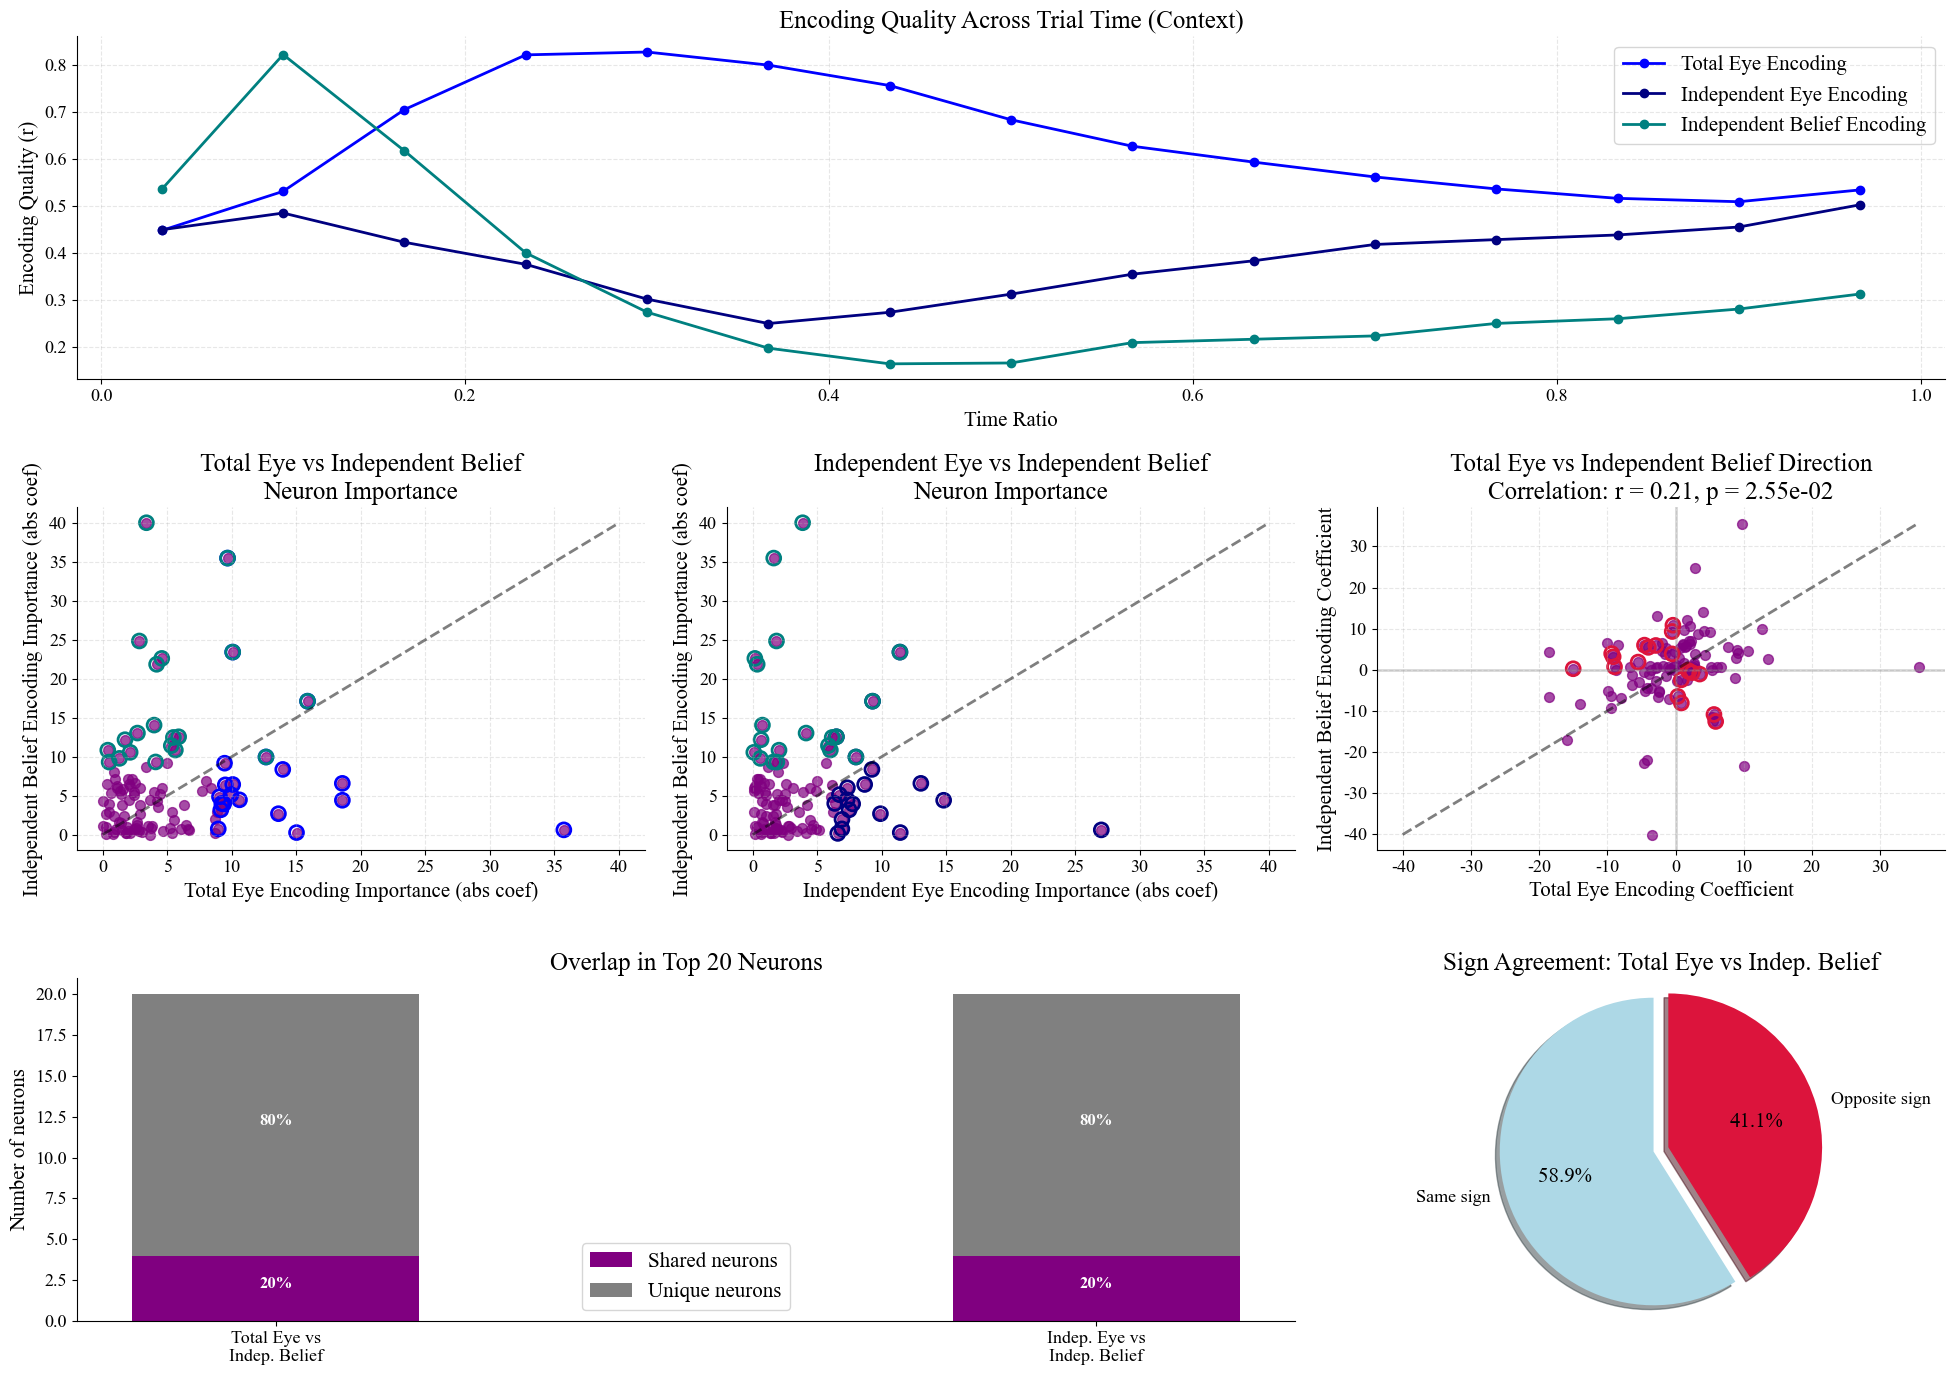

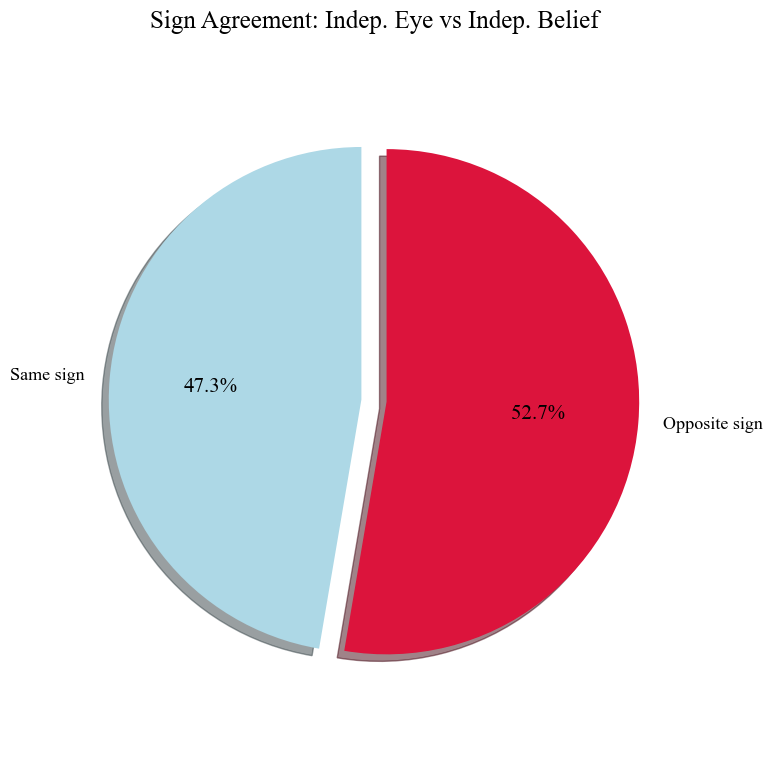

In [58]:
def analyze_neuron_contributions_eye_vs_belief(timedf, n_bins=10):
    """
    Analyze how individual neurons contribute to eye encoding versus
    independent belief encoding
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins to use for time-binned analysis (for context)
        
    Returns:
    --------
    fig : matplotlib Figure
        Figure with visualization of neuron contribution analysis
    results : dict
        Dictionary with analysis results
    """
    print("\n--- Neuron Population Analysis: Eye vs Belief Encoding ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, perform time-binned analysis for context
    print("Performing time-binned analysis for context...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_eye_r_values = []
    indep_eye_r_values = []
    indep_belief_r_values = []
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        eye_pred_total = np.zeros_like(eye_bin)
        eye_pred_independent = np.zeros_like(eye_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            belief_train, belief_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total eye encoding: neural -> eye
            model_total_eye = LinearRegression().fit(X_train, eye_train)
            eye_pred_total[test_idx] = model_total_eye.predict(X_test)
            
            # Independent eye encoding: neural residuals (after belief) -> eye
            model_belief = LinearRegression().fit(belief_train.reshape(-1, 1), X_train)
            X_residual_after_belief_train = X_train - model_belief.predict(belief_train.reshape(-1, 1))
            X_residual_after_belief_test = X_test - model_belief.predict(belief_test.reshape(-1, 1))
            
            model_indep_eye = LinearRegression().fit(X_residual_after_belief_train, eye_train)
            eye_pred_independent[test_idx] = model_indep_eye.predict(X_residual_after_belief_test)
            
            # Independent belief encoding: neural residuals (after eye) -> belief
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_after_eye_train = X_train - model_eye.predict(eye_train)
            X_residual_after_eye_test = X_test - model_eye.predict(eye_test)
            
            model_indep_belief = LinearRegression().fit(X_residual_after_eye_train, belief_train)
            belief_pred_independent[test_idx] = model_indep_belief.predict(X_residual_after_eye_test)
        
        # Calculate performance metrics
        r_total_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_total.flatten())
        r_indep_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_independent.flatten())
        r_indep_belief, _ = pearsonr(belief_bin, belief_pred_independent)
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_eye_r_values.append(r_total_eye)
        indep_eye_r_values.append(r_indep_eye)
        indep_belief_r_values.append(r_indep_belief)
    
    # Now analyze neuron contributions using all data
    
    # 1. Total eye encoding: neural -> eye
    model_total_eye = LinearRegression().fit(neural_data, eye_data)
    total_eye_coefs = model_total_eye.coef_[0]  # Flatten for a single target variable
    
    # 2. Independent eye encoding: neural residuals (after belief) -> eye
    model_belief = LinearRegression().fit(belief_data.reshape(-1, 1), neural_data)
    neural_residuals_after_belief = neural_data - model_belief.predict(belief_data.reshape(-1, 1))
    
    model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_data)
    indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten for a single target variable
    
    # 3. Independent belief encoding: neural residuals (after eye) -> belief
    model_eye = LinearRegression().fit(eye_data, neural_data)
    neural_residuals_after_eye = neural_data - model_eye.predict(eye_data)
    
    model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_data)
    indep_belief_coefs = model_indep_belief.coef_
    
    # Store coefficients for analysis
    neuron_data = {
        'neuron_idx': np.arange(n_neurons),
        'total_eye_coef': total_eye_coefs,
        'indep_eye_coef': indep_eye_coefs,
        'indep_belief_coef': indep_belief_coefs,
        'total_eye_abs_coef': np.abs(total_eye_coefs),
        'indep_eye_abs_coef': np.abs(indep_eye_coefs),
        'indep_belief_abs_coef': np.abs(indep_belief_coefs)
    }
    
    neuron_df = pd.DataFrame(neuron_data)
    
    # Identify top neurons for each encoding type
    n_top = 20  # Number of top neurons to track
    top_total_eye = neuron_df.sort_values('total_eye_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    top_indep_eye = neuron_df.sort_values('indep_eye_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    top_indep_belief = neuron_df.sort_values('indep_belief_abs_coef', ascending=False)['neuron_idx'].values[:n_top]
    
    # Calculate overlaps between top neurons
    overlap_total_eye_indep_belief = len(set(top_total_eye) & set(top_indep_belief))
    overlap_indep_eye_indep_belief = len(set(top_indep_eye) & set(top_indep_belief))
    
    overlap_pct_total_eye_indep_belief = overlap_total_eye_indep_belief / n_top * 100
    overlap_pct_indep_eye_indep_belief = overlap_indep_eye_indep_belief / n_top * 100
    
    print(f"Overlap between top total eye and independent belief neurons: {overlap_total_eye_indep_belief}/{n_top} ({overlap_pct_total_eye_indep_belief:.1f}%)")
    print(f"Overlap between top independent eye and independent belief neurons: {overlap_indep_eye_indep_belief}/{n_top} ({overlap_pct_indep_eye_indep_belief:.1f}%)")
    
    # Calculate correlations between coefficient sets
    corr_total_eye_indep_belief, p_total_eye_indep_belief = pearsonr(neuron_df['total_eye_coef'], neuron_df['indep_belief_coef'])
    corr_indep_eye_indep_belief, p_indep_eye_indep_belief = pearsonr(neuron_df['indep_eye_coef'], neuron_df['indep_belief_coef'])
    
    print(f"Correlation between total eye and independent belief coefficients: r = {corr_total_eye_indep_belief:.4f}, p = {p_total_eye_indep_belief:.4e}")
    print(f"Correlation between independent eye and independent belief coefficients: r = {corr_indep_eye_indep_belief:.4f}, p = {p_indep_eye_indep_belief:.4e}")
    
    # Calculate sign disagreements
    sign_disagreement_total_eye_indep_belief = sum((neuron_df['total_eye_coef'] * neuron_df['indep_belief_coef']) < 0)
    sign_disagreement_indep_eye_indep_belief = sum((neuron_df['indep_eye_coef'] * neuron_df['indep_belief_coef']) < 0)
    
    sign_disagreement_pct_total_eye_indep_belief = sign_disagreement_total_eye_indep_belief / n_neurons * 100
    sign_disagreement_pct_indep_eye_indep_belief = sign_disagreement_indep_eye_indep_belief / n_neurons * 100
    
    print(f"Neurons with opposite sign for total eye vs independent belief: {sign_disagreement_total_eye_indep_belief}/{n_neurons} ({sign_disagreement_pct_total_eye_indep_belief:.1f}%)")
    print(f"Neurons with opposite sign for independent eye vs independent belief: {sign_disagreement_indep_eye_indep_belief}/{n_neurons} ({sign_disagreement_pct_indep_eye_indep_belief:.1f}%)")
    
    # Create visualization
    fig = plt.figure(figsize=(20, 14))
    gs = plt.GridSpec(3, 3, figure=fig)
    
    # Plot 1: Time-binned encoding quality for context
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(time_bin_centers, total_eye_r_values, 'o-', color='blue', label='Total Eye Encoding')
    ax1.plot(time_bin_centers, indep_eye_r_values, 'o-', color='navy', label='Independent Eye Encoding')
    ax1.plot(time_bin_centers, indep_belief_r_values, 'o-', color='teal', label='Independent Belief Encoding')
    
    ax1.set_xlabel('Time Ratio')
    ax1.set_ylabel('Encoding Quality (r)')
    ax1.set_title('Encoding Quality Across Trial Time (Context)')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 2: Total Eye vs Independent Belief
    ax2 = fig.add_subplot(gs[1, 0])
    sc = ax2.scatter(neuron_df['total_eye_abs_coef'], neuron_df['indep_belief_abs_coef'], 
                   alpha=0.7, s=50, c='purple')
    
    # Add identity line
    max_val = max(neuron_df['total_eye_abs_coef'].max(), neuron_df['indep_belief_abs_coef'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Highlight top neurons for each encoding type
    for neuron in top_total_eye:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_eye_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_belief_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='blue', linewidth=2)
        
    for neuron in top_indep_belief:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_eye_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_belief_abs_coef'].values[0]
        ax2.scatter(x, y, s=100, facecolors='none', edgecolors='teal', linewidth=2)
    
    ax2.set_xlabel('Total Eye Encoding Importance (abs coef)')
    ax2.set_ylabel('Independent Belief Encoding Importance (abs coef)')
    ax2.set_title('Total Eye vs Independent Belief\nNeuron Importance')
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 3: Independent Eye vs Independent Belief
    ax3 = fig.add_subplot(gs[1, 1])
    sc = ax3.scatter(neuron_df['indep_eye_abs_coef'], neuron_df['indep_belief_abs_coef'], 
                   alpha=0.7, s=50, c='purple')
    
    # Add identity line
    max_val = max(neuron_df['indep_eye_abs_coef'].max(), neuron_df['indep_belief_abs_coef'].max())
    ax3.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Highlight top neurons for each encoding type
    for neuron in top_indep_eye:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_eye_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_belief_abs_coef'].values[0]
        ax3.scatter(x, y, s=100, facecolors='none', edgecolors='navy', linewidth=2)
        
    for neuron in top_indep_belief:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_eye_abs_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_belief_abs_coef'].values[0]
        ax3.scatter(x, y, s=100, facecolors='none', edgecolors='teal', linewidth=2)
    
    ax3.set_xlabel('Independent Eye Encoding Importance (abs coef)')
    ax3.set_ylabel('Independent Belief Encoding Importance (abs coef)')
    ax3.set_title('Independent Eye vs Independent Belief\nNeuron Importance')
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 4: Coefficient direction comparison (Total Eye vs Independent Belief)
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.scatter(neuron_df['total_eye_coef'], neuron_df['indep_belief_coef'], 
               alpha=0.7, s=50, c='purple')
    
    # Add axes and identity line
    min_val = min(neuron_df['total_eye_coef'].min(), neuron_df['indep_belief_coef'].min())
    max_val = max(neuron_df['total_eye_coef'].max(), neuron_df['indep_belief_coef'].max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    ax4.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax4.axvline(0, color='gray', linestyle='-', alpha=0.3)
    
    # Highlight neurons with different signs
    sign_disagreement_mask = (neuron_df['total_eye_coef'] * neuron_df['indep_belief_coef']) < 0
    sign_disagreement_neurons = neuron_df.loc[sign_disagreement_mask, 'neuron_idx'].values
    
    # Highlight a subset to avoid clutter
    highlight_count = min(20, len(sign_disagreement_neurons))
    for neuron in sign_disagreement_neurons[:highlight_count]:
        x = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'total_eye_coef'].values[0]
        y = neuron_df.loc[neuron_df['neuron_idx'] == neuron, 'indep_belief_coef'].values[0]
        ax4.scatter(x, y, s=100, facecolors='none', edgecolors='crimson', linewidth=2)
    
    ax4.set_xlabel('Total Eye Encoding Coefficient')
    ax4.set_ylabel('Independent Belief Encoding Coefficient')
    ax4.set_title(f'Total Eye vs Independent Belief Direction\nCorrelation: r = {corr_total_eye_indep_belief:.2f}, p = {p_total_eye_indep_belief:.2e}')
    ax4.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 5: Top neuron overlap analysis
    ax5 = fig.add_subplot(gs[2, 0:2])
    
    # Create bar chart for top neuron overlaps
    categories = ['Total Eye vs\nIndep. Belief', 'Indep. Eye vs\nIndep. Belief']
    overlap_vals = [overlap_total_eye_indep_belief, overlap_indep_eye_indep_belief]
    non_overlap = [n_top - x for x in overlap_vals]
    
    x = np.arange(len(categories))
    width = 0.35
    
    ax5.bar(x, overlap_vals, width, label='Shared neurons', color='purple')
    ax5.bar(x, non_overlap, width, bottom=overlap_vals, label='Unique neurons', color='gray')
    
    ax5.set_ylabel('Number of neurons')
    ax5.set_title(f'Overlap in Top {n_top} Neurons')
    ax5.set_xticks(x)
    ax5.set_xticklabels(categories)
    ax5.legend()
    
    # Add text with percentages
    for i, v in enumerate(overlap_vals):
        pct = v / n_top * 100
        ax5.text(i, v/2, f"{pct:.0f}%", ha='center', fontsize=12, fontweight='bold', color='white')
        
        non_overlap_pct = non_overlap[i] / n_top * 100
        ax5.text(i, v + non_overlap[i]/2, f"{non_overlap_pct:.0f}%", ha='center', fontsize=12, 
                fontweight='bold', color='white')
    
    # Plot 6: Sign disagreement comparison
    ax6 = fig.add_subplot(gs[2, 2])
    
    # Create pie charts for sign agreement/disagreement
    labels = ['Same sign', 'Opposite sign']
    
    # Define data for the two comparisons
    sign_data = {
        'Total Eye vs Indep. Belief': {
            'same': n_neurons - sign_disagreement_total_eye_indep_belief,
            'opposite': sign_disagreement_total_eye_indep_belief
        },
        'Indep. Eye vs Indep. Belief': {
            'same': n_neurons - sign_disagreement_indep_eye_indep_belief,
            'opposite': sign_disagreement_indep_eye_indep_belief
        }
    }
    
    # Two side-by-side pie charts
    comparison = 'Total Eye vs Indep. Belief'
    sizes = [sign_data[comparison]['same'], sign_data[comparison]['opposite']]
    explode = (0, 0.1)
    
    ax6.pie(sizes, explode=explode, labels=labels, 
           colors=['lightblue', 'crimson'], autopct='%1.1f%%',
           shadow=True, startangle=90)
    ax6.axis('equal')
    ax6.set_title(f'Sign Agreement: {comparison}')
    
    plt.tight_layout()
    
    # Create second figure for additional pie chart
    fig2 = plt.figure(figsize=(8, 8))
    ax7 = fig2.add_subplot(111)
    
    # Second pie chart
    comparison = 'Indep. Eye vs Indep. Belief'
    sizes = [sign_data[comparison]['same'], sign_data[comparison]['opposite']]
    explode = (0, 0.1)
    
    ax7.pie(sizes, explode=explode, labels=labels, 
           colors=['lightblue', 'crimson'], autopct='%1.1f%%',
           shadow=True, startangle=90)
    ax7.axis('equal')
    ax7.set_title(f'Sign Agreement: {comparison}')
    
    plt.tight_layout()
    
    # Return results
    results = {
        'top_total_eye': top_total_eye,
        'top_indep_eye': top_indep_eye,
        'top_indep_belief': top_indep_belief,
        'overlap_total_eye_indep_belief': overlap_total_eye_indep_belief,
        'overlap_indep_eye_indep_belief': overlap_indep_eye_indep_belief,
        'corr_total_eye_indep_belief': corr_total_eye_indep_belief,
        'corr_indep_eye_indep_belief': corr_indep_eye_indep_belief,
        'sign_disagreement_total_eye_indep_belief': sign_disagreement_total_eye_indep_belief,
        'sign_disagreement_indep_eye_indep_belief': sign_disagreement_indep_eye_indep_belief,
        'neuron_df': neuron_df,
        'time_bin_data': {
            'centers': time_bin_centers,
            'total_eye_r': total_eye_r_values,
            'indep_eye_r': indep_eye_r_values,
            'indep_belief_r': indep_belief_r_values
        }
    }
    
    return (fig, fig2), results

# Run the eye vs belief neuron population analysis
print("\nRunning Eye vs Belief Neuron Population Analysis...")
neuron_figs, neuron_results = analyze_neuron_contributions_eye_vs_belief(timedf, n_bins=15)
plt.figure(neuron_figs[0].number)
plt.savefig('neuron_population_eye_vs_belief_main.png', dpi=300, bbox_inches='tight')
plt.figure(neuron_figs[1].number)
plt.savefig('neuron_population_eye_vs_belief_supplemental.png', dpi=300, bbox_inches='tight')
plt.show()


Running Comprehensive Neuron Population Analysis...

--- Comprehensive Neuron Population Analysis ---
Analyzing contributions of 112 neurons
Calculating coefficients for different encoding types...
Calculating time-binned encoding quality for context...

Neuron Population Sizes:
Total neurons analyzed: 112
Important Total Belief neurons: 28 (25.0%)
Important Total Eye neurons: 28 (25.0%)
Important Independent Belief neurons: 28 (25.0%)
Important Independent Eye neurons: 28 (25.0%)

Key Intersections:
Neurons important for both Total Belief & Total Eye: 18 (16.1%)
Neurons important for both Total Belief & Indep Belief: 15 (13.4%)
Neurons important for both Total Eye & Indep Eye: 24 (21.4%)
Neurons important for both Indep Belief & Indep Eye: 9 (8.0%)
Neurons important for all encoding types: 4 (3.6%)


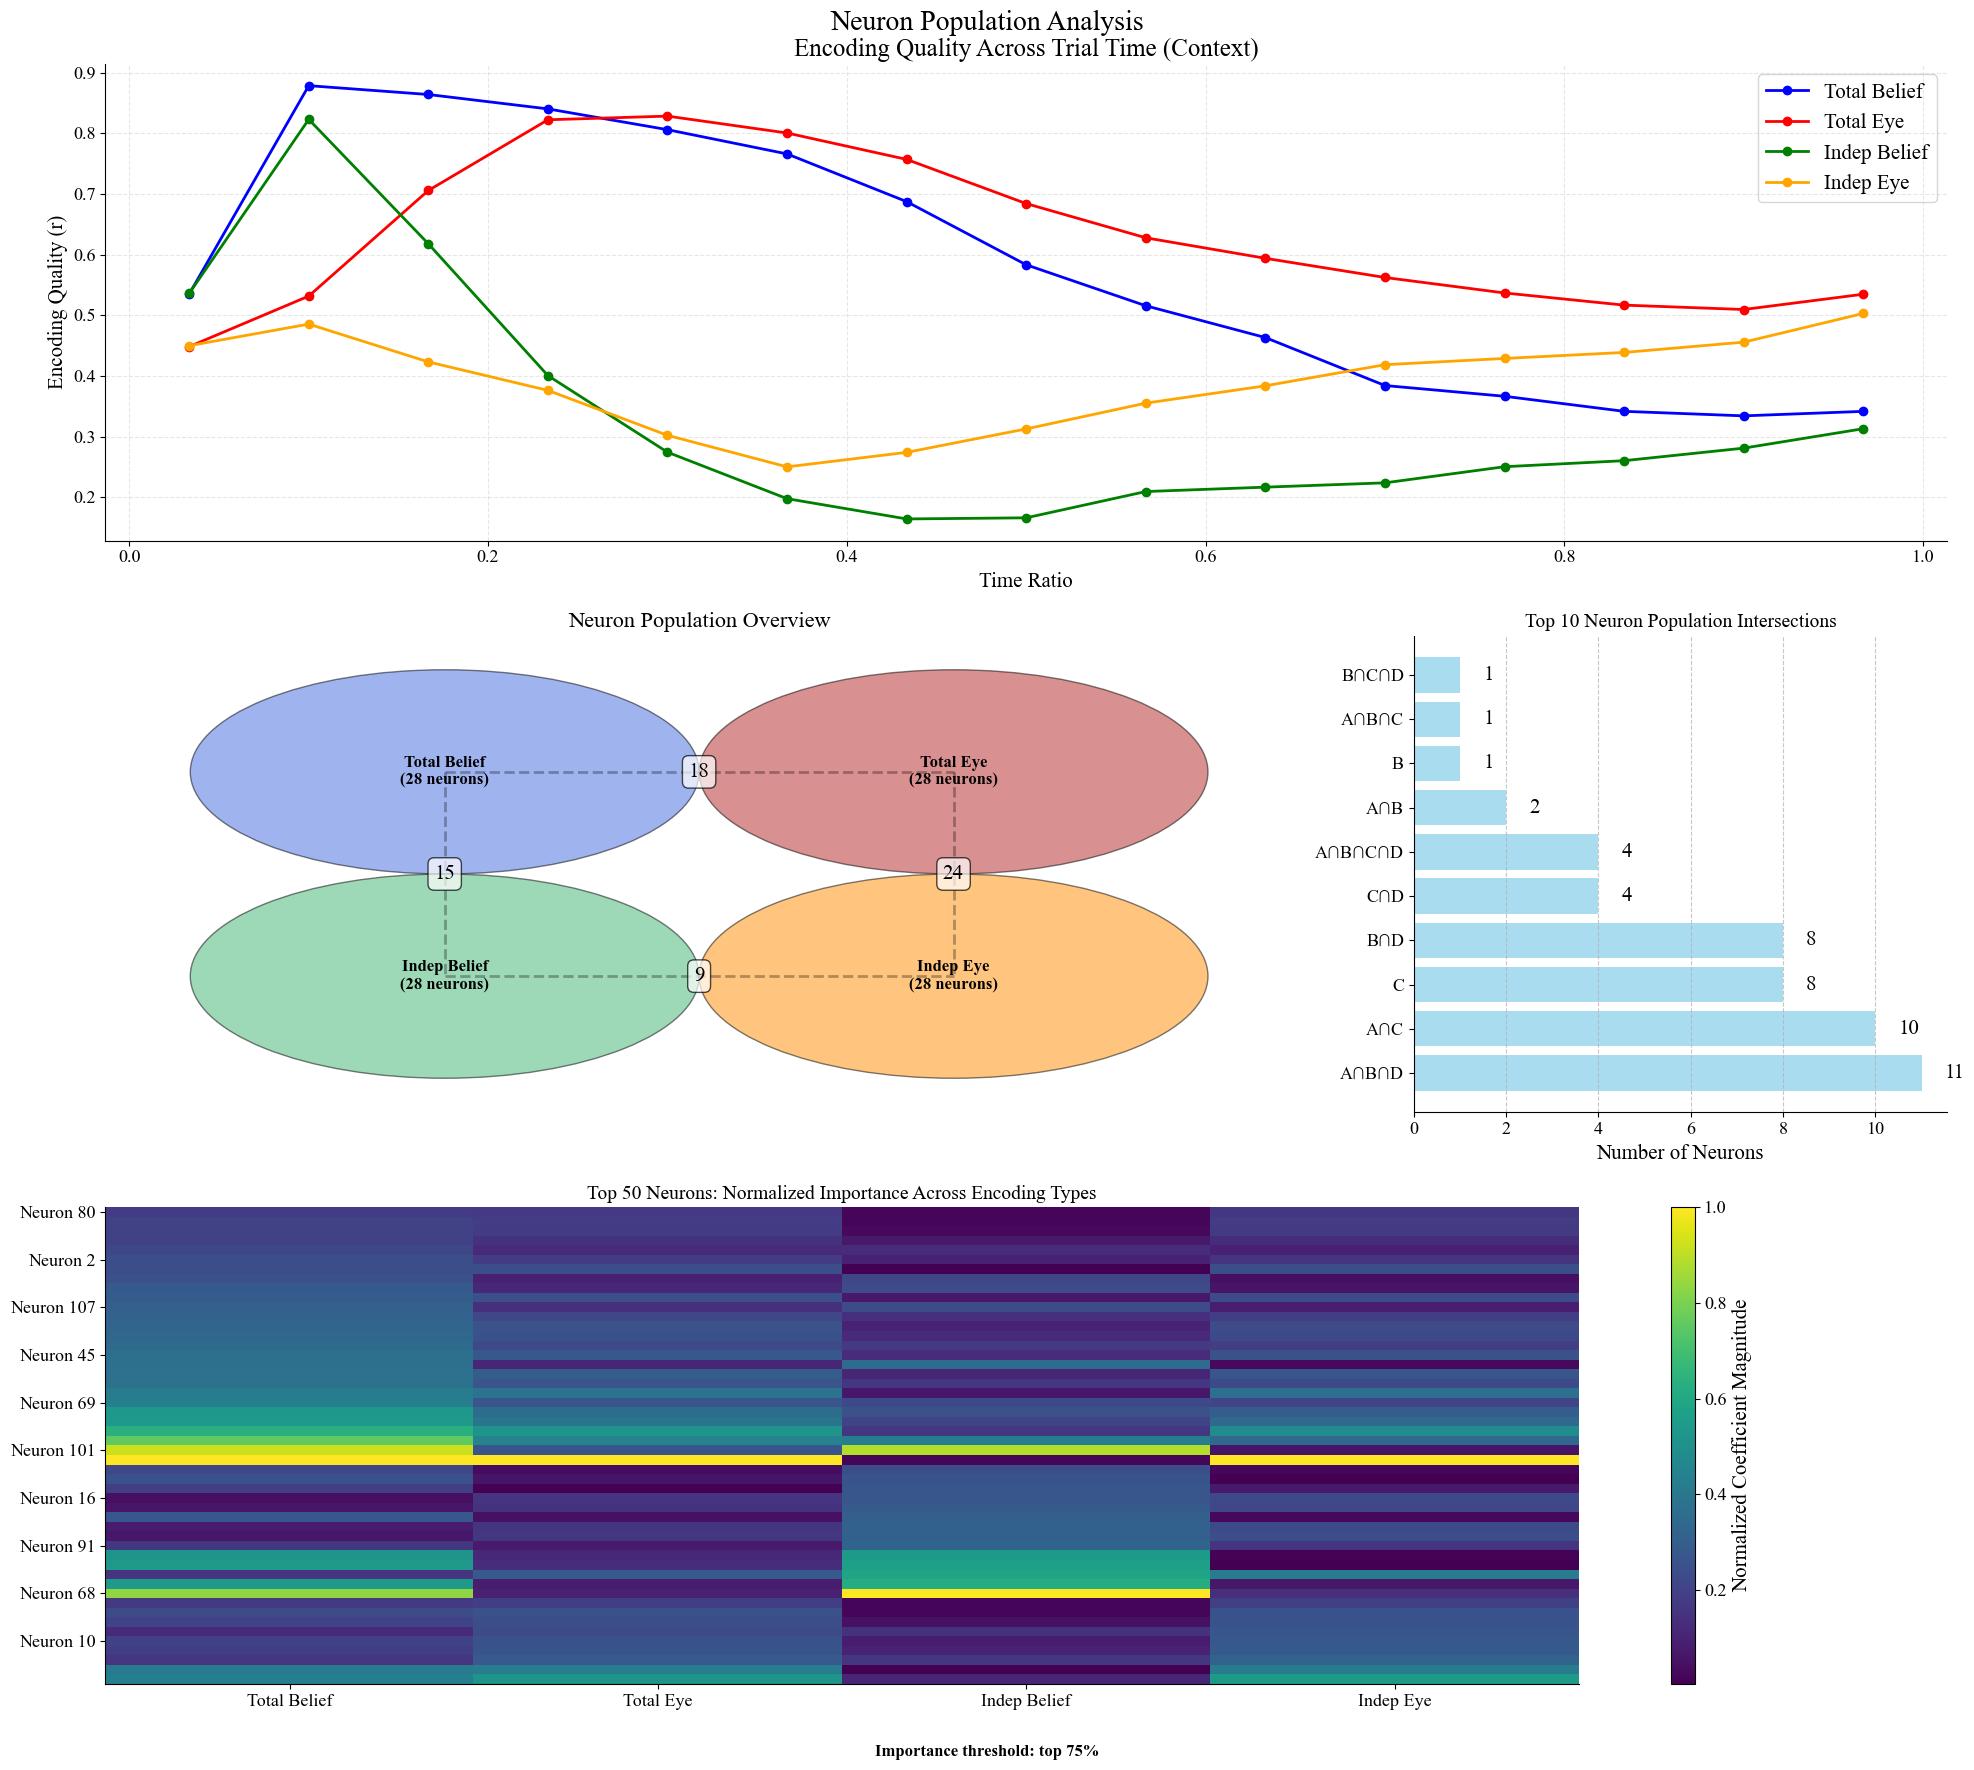

In [63]:
def analyze_and_visualize_neuron_populations(timedf, n_bins=15):
    """
    Analyze different neuron populations involved in encoding and create visualizations
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins for time-based context
    
    Returns:
    --------
    fig : matplotlib Figure
        Figure with comprehensive visualization
    neuron_df : pandas DataFrame
        DataFrame with neuron coefficients for different encoding types
    """
    print("\n--- Comprehensive Neuron Population Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # Calculate coefficients for different encoding types
    print("Calculating coefficients for different encoding types...")
    
    # 1. Total belief encoding: neural -> belief
    model_total_belief = LinearRegression().fit(neural_data, belief_data)
    total_belief_coefs = model_total_belief.coef_
    
    # 2. Total eye encoding: neural -> eye
    model_total_eye = LinearRegression().fit(neural_data, eye_data)
    total_eye_coefs = model_total_eye.coef_[0]  # Flatten
    
    # 3. Independent belief encoding: neural residuals (after eye) -> belief
    model_eye = LinearRegression().fit(eye_data, neural_data)
    neural_residuals_after_eye = neural_data - model_eye.predict(eye_data)
    
    model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_data)
    indep_belief_coefs = model_indep_belief.coef_
    
    # 4. Independent eye encoding: neural residuals (after belief) -> eye
    model_belief = LinearRegression().fit(belief_data.reshape(-1, 1), neural_data)
    neural_residuals_after_belief = neural_data - model_belief.predict(belief_data.reshape(-1, 1))
    
    model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_data)
    indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten
    
    # Create DataFrame
    neuron_data = {
        'neuron_idx': np.arange(n_neurons),
        'total_belief_coef': total_belief_coefs,
        'total_eye_coef': total_eye_coefs,
        'indep_belief_coef': indep_belief_coefs,
        'indep_eye_coef': indep_eye_coefs,
        'total_belief_abs_coef': np.abs(total_belief_coefs),
        'total_eye_abs_coef': np.abs(total_eye_coefs),
        'indep_belief_abs_coef': np.abs(indep_belief_coefs),
        'indep_eye_abs_coef': np.abs(indep_eye_coefs)
    }
    
    neuron_df = pd.DataFrame(neuron_data)
    
    # Also calculate time-binned encoding quality for context
    print("Calculating time-binned encoding quality for context...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_belief_r_values = []
    total_eye_r_values = []
    indep_belief_r_values = []
    indep_eye_r_values = []
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        eye_pred_total = np.zeros_like(eye_bin)
        eye_pred_independent = np.zeros_like(eye_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            belief_train, belief_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total belief encoding
            model_total = LinearRegression().fit(X_train, belief_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Total eye encoding
            model_total_eye = LinearRegression().fit(X_train, eye_train)
            eye_pred_total[test_idx] = model_total_eye.predict(X_test)
            
            # Independent belief encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, belief_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
            
            # Independent eye encoding
            model_belief = LinearRegression().fit(belief_train.reshape(-1, 1), X_train)
            X_residual_belief_train = X_train - model_belief.predict(belief_train.reshape(-1, 1))
            X_residual_belief_test = X_test - model_belief.predict(belief_test.reshape(-1, 1))
            model_indep_eye = LinearRegression().fit(X_residual_belief_train, eye_train)
            eye_pred_independent[test_idx] = model_indep_eye.predict(X_residual_belief_test)
        
        # Calculate performance metrics
        r_total_belief, _ = pearsonr(belief_bin, belief_pred_total)
        r_total_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_total.flatten())
        r_indep_belief, _ = pearsonr(belief_bin, belief_pred_independent)
        r_indep_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_independent.flatten())
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_belief_r_values.append(r_total_belief)
        total_eye_r_values.append(r_total_eye)
        indep_belief_r_values.append(r_indep_belief)
        indep_eye_r_values.append(r_indep_eye)
    
    # Identify important neurons for each encoding type
    # Method: Percentile threshold
    percentile_threshold = 75
    
    threshold_total_belief = np.percentile(neuron_df['total_belief_abs_coef'], percentile_threshold)
    threshold_total_eye = np.percentile(neuron_df['total_eye_abs_coef'], percentile_threshold)
    threshold_indep_belief = np.percentile(neuron_df['indep_belief_abs_coef'], percentile_threshold)
    threshold_indep_eye = np.percentile(neuron_df['indep_eye_abs_coef'], percentile_threshold)
    
    # Get sets of important neurons
    set_total_belief = set(neuron_df[neuron_df['total_belief_abs_coef'] >= threshold_total_belief]['neuron_idx'])
    set_total_eye = set(neuron_df[neuron_df['total_eye_abs_coef'] >= threshold_total_eye]['neuron_idx'])
    set_indep_belief = set(neuron_df[neuron_df['indep_belief_abs_coef'] >= threshold_indep_belief]['neuron_idx'])
    set_indep_eye = set(neuron_df[neuron_df['indep_eye_abs_coef'] >= threshold_indep_eye]['neuron_idx'])
    
    method_name = f"Importance threshold: top {percentile_threshold}%"
    
    # Calculate all possible intersections for Venn diagram
    # A: Total Belief, B: Total Eye, C: Independent Belief, D: Independent Eye
    
    # First level intersections (pairs)
    AB = set_total_belief & set_total_eye
    AC = set_total_belief & set_indep_belief
    AD = set_total_belief & set_indep_eye
    BC = set_total_eye & set_indep_belief
    BD = set_total_eye & set_indep_eye
    CD = set_indep_belief & set_indep_eye
    
    # Second level intersections (triplets)
    ABC = set_total_belief & set_total_eye & set_indep_belief
    ABD = set_total_belief & set_total_eye & set_indep_eye
    ACD = set_total_belief & set_indep_belief & set_indep_eye
    BCD = set_total_eye & set_indep_belief & set_indep_eye
    
    # Third level intersection (all four)
    ABCD = set_total_belief & set_total_eye & set_indep_belief & set_indep_eye
    
    # Remove intersections to get unique areas
    A_only = set_total_belief - (set_total_eye | set_indep_belief | set_indep_eye)
    B_only = set_total_eye - (set_total_belief | set_indep_belief | set_indep_eye)
    C_only = set_indep_belief - (set_total_belief | set_total_eye | set_indep_eye)
    D_only = set_indep_eye - (set_total_belief | set_total_eye | set_indep_belief)
    
    AB_only = AB - (set_indep_belief | set_indep_eye)
    AC_only = AC - (set_total_eye | set_indep_eye)
    AD_only = AD - (set_total_eye | set_indep_belief)
    BC_only = BC - (set_total_belief | set_indep_eye)
    BD_only = BD - (set_total_belief | set_indep_belief)
    CD_only = CD - (set_total_belief | set_total_eye)
    
    ABC_only = ABC - set_indep_eye
    ABD_only = ABD - set_indep_belief
    ACD_only = ACD - set_total_eye
    BCD_only = BCD - set_total_belief
    
    # Calculate sizes
    sizes = {
        'A_only': len(A_only),
        'B_only': len(B_only),
        'C_only': len(C_only),
        'D_only': len(D_only),
        'AB_only': len(AB_only),
        'AC_only': len(AC_only),
        'AD_only': len(AD_only),
        'BC_only': len(BC_only),
        'BD_only': len(BD_only),
        'CD_only': len(CD_only),
        'ABC_only': len(ABC_only),
        'ABD_only': len(ABD_only),
        'ACD_only': len(ACD_only),
        'BCD_only': len(BCD_only),
        'ABCD': len(ABCD)
    }
    
    # Print statistics
    print("\nNeuron Population Sizes:")
    print(f"Total neurons analyzed: {n_neurons}")
    print(f"Important Total Belief neurons: {len(set_total_belief)} ({len(set_total_belief)/n_neurons*100:.1f}%)")
    print(f"Important Total Eye neurons: {len(set_total_eye)} ({len(set_total_eye)/n_neurons*100:.1f}%)")
    print(f"Important Independent Belief neurons: {len(set_indep_belief)} ({len(set_indep_belief)/n_neurons*100:.1f}%)")
    print(f"Important Independent Eye neurons: {len(set_indep_eye)} ({len(set_indep_eye)/n_neurons*100:.1f}%)")
    
    print("\nKey Intersections:")
    print(f"Neurons important for both Total Belief & Total Eye: {len(AB)} ({len(AB)/n_neurons*100:.1f}%)")
    print(f"Neurons important for both Total Belief & Indep Belief: {len(AC)} ({len(AC)/n_neurons*100:.1f}%)")
    print(f"Neurons important for both Total Eye & Indep Eye: {len(BD)} ({len(BD)/n_neurons*100:.1f}%)")
    print(f"Neurons important for both Indep Belief & Indep Eye: {len(CD)} ({len(CD)/n_neurons*100:.1f}%)")
    print(f"Neurons important for all encoding types: {len(ABCD)} ({len(ABCD)/n_neurons*100:.1f}%)")
    
    # Create visualization
    # We'll use a combination of approaches
    
    # 1. Create a figure with multiple subplots
    fig = plt.figure(figsize=(20, 18))
    gs = plt.GridSpec(3, 3, figure=fig)
    
    # Plot 0: Time-binned encoding quality for context
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(time_bin_centers, total_belief_r_values, 'o-', color='blue', label='Total Belief')
    ax0.plot(time_bin_centers, total_eye_r_values, 'o-', color='red', label='Total Eye')
    ax0.plot(time_bin_centers, indep_belief_r_values, 'o-', color='green', label='Indep Belief')
    ax0.plot(time_bin_centers, indep_eye_r_values, 'o-', color='orange', label='Indep Eye')
    
    ax0.set_xlabel('Time Ratio')
    ax0.set_ylabel('Encoding Quality (r)')
    ax0.set_title('Encoding Quality Across Trial Time (Context)')
    ax0.legend()
    ax0.grid(True, linestyle='--', alpha=0.3)
    
    # Plot 1: Neuron Population Venn Diagram (simplified representation)
    ax1 = fig.add_subplot(gs[1, 0:2])
    
    # Define colors for each set
    set_colors = {
        'Total Belief': 'royalblue',
        'Total Eye': 'firebrick',
        'Indep Belief': 'mediumseagreen',
        'Indep Eye': 'darkorange'
    }
    
    # Create custom Venn-like diagram
    # Use 4 quarter circles arranged in a grid
    
    # Define grid layout
    centers = {
        'Total Belief': (-1.5, 1.5),
        'Total Eye': (1.5, 1.5),
        'Indep Belief': (-1.5, -1.5),
        'Indep Eye': (1.5, -1.5)
    }
    
    # Define circle sizes (proportional to set sizes)
    sizes_sqrt = {k: np.sqrt(len(v)) for k, v in {
        'Total Belief': set_total_belief,
        'Total Eye': set_total_eye,
        'Indep Belief': set_indep_belief,
        'Indep Eye': set_indep_eye
    }.items()}
    
    max_size = max(sizes_sqrt.values())
    circle_sizes = {k: v/max_size * 1.5 for k, v in sizes_sqrt.items()}
    
    # Draw circles
    for name, center in centers.items():
        size = circle_sizes[name]
        circle = plt.Circle(center, size, alpha=0.5, 
                           fc=set_colors[name], ec='black')
        ax1.add_patch(circle)
        
        # Add text labels
        set_size = len({'Total Belief': set_total_belief, 
                      'Total Eye': set_total_eye,
                      'Indep Belief': set_indep_belief,
                      'Indep Eye': set_indep_eye}[name])
        
        ax1.text(center[0], center[1], f"{name}\n({set_size} neurons)", 
                ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Connect overlapping sets with lines and annotate
    for set1, set2, name1, name2 in [
        (set_total_belief, set_total_eye, 'Total Belief', 'Total Eye'),
        (set_total_belief, set_indep_belief, 'Total Belief', 'Indep Belief'),
        (set_total_eye, set_indep_eye, 'Total Eye', 'Indep Eye'),
        (set_indep_belief, set_indep_eye, 'Indep Belief', 'Indep Eye')
    ]:
        overlap = len(set1 & set2)
        if overlap > 0:
            c1 = centers[name1]
            c2 = centers[name2]
            ax1.plot([c1[0], c2[0]], [c1[1], c2[1]], 'k--', alpha=0.3)
            
            # Calculate midpoint and add annotation
            mid_x = (c1[0] + c2[0]) / 2
            mid_y = (c1[1] + c2[1]) / 2
            ax1.text(mid_x, mid_y, f"{overlap}", ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    # Set axis limits and remove ticks
    ax1.set_xlim(-3.5, 3.5)
    ax1.set_ylim(-3.5, 3.5)
    ax1.axis('off')
    ax1.set_title('Neuron Population Overview', fontsize=16)
    
    # Plot 2: UpSet-like plot for set intersections
    ax2 = fig.add_subplot(gs[1, 2])
    
    # Prepare data for UpSet plot
    set_names = ['Total Belief (A)', 'Total Eye (B)', 
                'Indep Belief (C)', 'Indep Eye (D)']
    
    intersections = [
        ('A', sizes['A_only']),
        ('B', sizes['B_only']),
        ('C', sizes['C_only']),
        ('D', sizes['D_only']),
        ('A∩B', sizes['AB_only']),
        ('A∩C', sizes['AC_only']),
        ('A∩D', sizes['AD_only']),
        ('B∩C', sizes['BC_only']),
        ('B∩D', sizes['BD_only']),
        ('C∩D', sizes['CD_only']),
        ('A∩B∩C', sizes['ABC_only']),
        ('A∩B∩D', sizes['ABD_only']),
        ('A∩C∩D', sizes['ACD_only']),
        ('B∩C∩D', sizes['BCD_only']),
        ('A∩B∩C∩D', sizes['ABCD'])
    ]
    
    # Sort by size descending
    intersections.sort(key=lambda x: x[1], reverse=True)
    
    # Filter small intersections for readability
    intersections = [x for x in intersections if x[1] > 0][:10]  # Top 10 non-empty
    
    # Create horizontal bar chart
    y_pos = np.arange(len(intersections))
    bars = ax2.barh(y_pos, [item[1] for item in intersections], 
                   color='skyblue', alpha=0.7)
    
    # Add labels
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([item[0] for item in intersections])
    
    # Add grid
    ax2.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add title and labels
    ax2.set_title('Top 10 Neuron Population Intersections', fontsize=14)
    ax2.set_xlabel('Number of Neurons')
    
    # Add value labels
    for i, v in enumerate([item[1] for item in intersections]):
        ax2.text(v + 0.5, i, str(v), va='center')
    
    # Plot 3: Heatmap of neuron importance across encoding types
    ax3 = fig.add_subplot(gs[2, :])
    
    # For visualization, select a subset of most important neurons overall
    neuron_importance_scores = (
        neuron_df['total_belief_abs_coef'] / threshold_total_belief +
        neuron_df['total_eye_abs_coef'] / threshold_total_eye +
        neuron_df['indep_belief_abs_coef'] / threshold_indep_belief +
        neuron_df['indep_eye_abs_coef'] / threshold_indep_eye
    )
    
    # Select top neurons
    top_n_heatmap = 50
    top_neurons = neuron_df.iloc[np.argsort(-neuron_importance_scores)][:top_n_heatmap]['neuron_idx'].values
    
    # Prepare heatmap data
    heatmap_data = []
    for neuron in top_neurons:
        row = neuron_df[neuron_df['neuron_idx'] == neuron].iloc[0]
        heatmap_data.append([
            row['total_belief_abs_coef'],
            row['total_eye_abs_coef'],
            row['indep_belief_abs_coef'],
            row['indep_eye_abs_coef']
        ])
    
    # Normalize within each encoding type for better visualization
    heatmap_data = np.array(heatmap_data)
    for col in range(4):
        heatmap_data[:, col] = heatmap_data[:, col] / np.max(heatmap_data[:, col])
    
    # Sort neurons by their maximum encoding type
    max_type_idx = np.argmax(heatmap_data, axis=1)
    sort_idx = np.lexsort((np.max(heatmap_data, axis=1), max_type_idx))
    heatmap_data = heatmap_data[sort_idx]
    sorted_neurons = top_neurons[sort_idx]
    
    # Create heatmap
    im = ax3.imshow(heatmap_data, aspect='auto', cmap='viridis')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax3)
    cbar.set_label('Normalized Coefficient Magnitude')
    
    # Add labels
    ax3.set_xticks(np.arange(4))
    ax3.set_xticklabels(['Total Belief', 'Total Eye', 'Indep Belief', 'Indep Eye'])
    ax3.set_yticks(np.arange(len(sorted_neurons)))
    ax3.set_yticklabels([f'Neuron {n}' for n in sorted_neurons])
    
    # Adjust y-labels to avoid crowding
    if len(sorted_neurons) > 20:
        ax3.set_yticks(np.arange(0, len(sorted_neurons), 5))
        ax3.set_yticklabels([f'Neuron {sorted_neurons[i]}' for i in range(0, len(sorted_neurons), 5)])
    
    ax3.set_title(f'Top {top_n_heatmap} Neurons: Normalized Importance Across Encoding Types', fontsize=14)
    
    # Add annotation to show method used
    fig.suptitle('Neuron Population Analysis', fontsize=20)
    fig.text(0.5, 0.01, method_name, ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, bottom=0.05)
    
    return fig, neuron_df

# Run the analysis and visualization
print("\nRunning Comprehensive Neuron Population Analysis...")
neuron_fig, neuron_df = analyze_and_visualize_neuron_populations(timedf, n_bins=15)
plt.savefig('neuron_population_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()


Running Neuron Scatter Plot Analysis...

--- Neuron Scatter Plot Analysis By Trial Phase ---
Analyzing contributions of 112 neurons
Performing time-binned analysis to identify phases...
Bin 1: Time=0.00-0.07, Total Belief r=0.535, Total Eye r=0.448, Indep Belief r=0.536, Indep Eye r=0.450
Bin 2: Time=0.07-0.13, Total Belief r=0.879, Total Eye r=0.532, Indep Belief r=0.823, Indep Eye r=0.485
Bin 3: Time=0.13-0.20, Total Belief r=0.864, Total Eye r=0.706, Indep Belief r=0.618, Indep Eye r=0.423
Bin 4: Time=0.20-0.27, Total Belief r=0.840, Total Eye r=0.823, Indep Belief r=0.401, Indep Eye r=0.376
Bin 5: Time=0.27-0.33, Total Belief r=0.806, Total Eye r=0.829, Indep Belief r=0.274, Indep Eye r=0.302
Bin 6: Time=0.33-0.40, Total Belief r=0.766, Total Eye r=0.801, Indep Belief r=0.198, Indep Eye r=0.250
Bin 7: Time=0.40-0.47, Total Belief r=0.688, Total Eye r=0.757, Indep Belief r=0.164, Indep Eye r=0.274
Bin 8: Time=0.47-0.53, Total Belief r=0.583, Total Eye r=0.684, Indep Belief r=0.166,

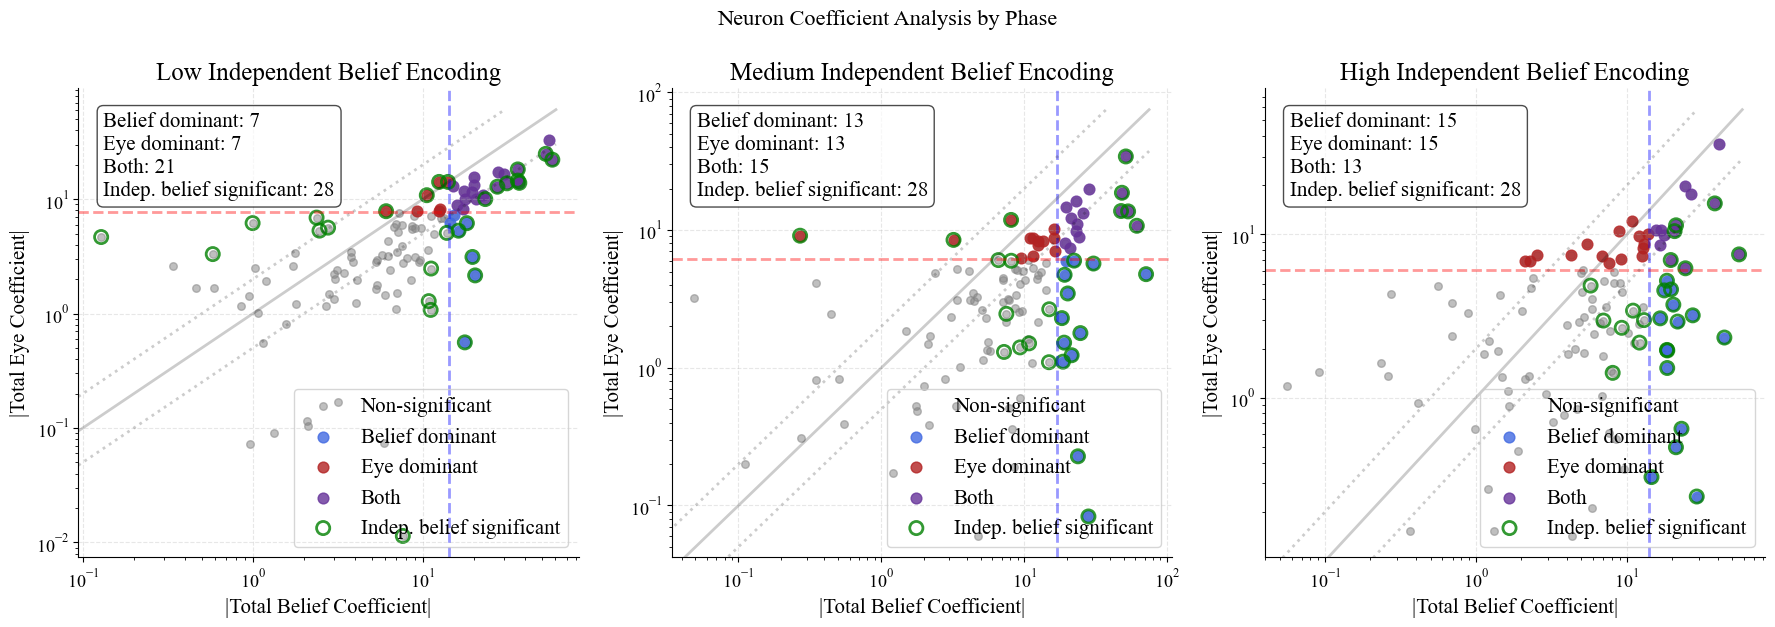

In [65]:
def analyze_neuron_scatter_plots(timedf, n_bins=15):
    """
    Create scatter plots showing total belief vs total eye encoding
    across different trial phases
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins for time-based analysis
    """
    print("\n--- Neuron Scatter Plot Analysis By Trial Phase ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, perform time-binned analysis to identify phases
    print("Performing time-binned analysis to identify phases...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_belief_r_values = []
    total_eye_r_values = []
    indep_belief_r_values = []
    indep_eye_r_values = []
    
    # Also store bin masks for later use
    bin_masks = {}
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Store mask for later use
        bin_masks[i] = bin_mask
        
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        eye_pred_total = np.zeros_like(eye_bin)
        eye_pred_independent = np.zeros_like(eye_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            belief_train, belief_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total belief encoding
            model_total = LinearRegression().fit(X_train, belief_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Total eye encoding
            model_total_eye = LinearRegression().fit(X_train, eye_train)
            eye_pred_total[test_idx] = model_total_eye.predict(X_test)
            
            # Independent belief encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, belief_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
            
            # Independent eye encoding
            model_belief = LinearRegression().fit(belief_train.reshape(-1, 1), X_train)
            X_residual_belief_train = X_train - model_belief.predict(belief_train.reshape(-1, 1))
            X_residual_belief_test = X_test - model_belief.predict(belief_test.reshape(-1, 1))
            model_indep_eye = LinearRegression().fit(X_residual_belief_train, eye_train)
            eye_pred_independent[test_idx] = model_indep_eye.predict(X_residual_belief_test)
        
        # Calculate performance metrics
        r_total_belief, _ = pearsonr(belief_bin, belief_pred_total)
        r_total_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_total.flatten())
        r_indep_belief, _ = pearsonr(belief_bin, belief_pred_independent)
        r_indep_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_independent.flatten())
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_belief_r_values.append(r_total_belief)
        total_eye_r_values.append(r_total_eye)
        indep_belief_r_values.append(r_indep_belief)
        indep_eye_r_values.append(r_indep_eye)
        
        print(f"Bin {i+1}: Time={bin_start:.2f}-{bin_end:.2f}, " +
              f"Total Belief r={r_total_belief:.3f}, " +
              f"Total Eye r={r_total_eye:.3f}, " +
              f"Indep Belief r={r_indep_belief:.3f}, " +
              f"Indep Eye r={r_indep_eye:.3f}")
    
    # Identify early, middle, and late phases based on independent belief encoding
    # Convert to arrays
    time_bin_centers = np.array(time_bin_centers)
    indep_belief_r_values = np.array(indep_belief_r_values)
    total_belief_r_values = np.array(total_belief_r_values)
    total_eye_r_values = np.array(total_eye_r_values)
    
    # Get valid bin indices (where we have values)
    valid_bins = np.arange(len(time_bin_centers))
    
    # Sort bins by independent belief encoding strength
    sort_idx = np.argsort(indep_belief_r_values)
    
    # Identify phases (low, med, high) based on independent belief encoding
    n_bins_per_phase = len(valid_bins) // 3
    
    # Low phase: bottom third of bins by independent encoding performance
    low_phase_bins = sort_idx[:n_bins_per_phase]
    med_phase_bins = sort_idx[n_bins_per_phase:2*n_bins_per_phase]
    high_phase_bins = sort_idx[2*n_bins_per_phase:]
    
    # Define phases
    phases = {
        'low': {
            'bins': low_phase_bins,
            'name': 'Low Independent Belief Encoding',
            'color': 'salmon'
        },
        'med': {
            'bins': med_phase_bins,
            'name': 'Medium Independent Belief Encoding',
            'color': 'cornflowerblue'
        },
        'high': {
            'bins': high_phase_bins,
            'name': 'High Independent Belief Encoding',
            'color': 'mediumseagreen'
        }
    }
    
    # Print phase information
    for phase_name, phase_info in phases.items():
        phase_bins = phase_info['bins']
        phase_times = [time_bin_centers[i] for i in phase_bins]
        print(f"\n{phase_name.capitalize()} phase bins: {phase_bins}")
        print(f"{phase_name.capitalize()} phase time ratios: {[f'{t:.2f}' for t in phase_times]}")
        
        # Calculate average encoding performance in this phase
        avg_total_belief = np.mean([total_belief_r_values[i] for i in phase_bins])
        avg_total_eye = np.mean([total_eye_r_values[i] for i in phase_bins])
        avg_indep_belief = np.mean([indep_belief_r_values[i] for i in phase_bins])
        
        print(f"Average Total Belief r: {avg_total_belief:.3f}")
        print(f"Average Total Eye r: {avg_total_eye:.3f}")
        print(f"Average Independent Belief r: {avg_indep_belief:.3f}")
    
    # Create combined data masks for each phase
    phase_masks = {
        'low': np.zeros_like(time_ratio, dtype=bool),
        'med': np.zeros_like(time_ratio, dtype=bool),
        'high': np.zeros_like(time_ratio, dtype=bool)
    }
    
    for phase_name, phase_info in phases.items():
        for bin_idx in phase_info['bins']:
            phase_masks[phase_name] |= bin_masks.get(bin_idx, np.zeros_like(time_ratio, dtype=bool))
    
    # Calculate neuron coefficients for each phase
    phase_coefficients = {}
    
    for phase_name, phase_mask in phase_masks.items():
        # Skip if no data in this phase
        if np.sum(phase_mask) < 20:
            print(f"Skipping {phase_name} phase - insufficient data")
            continue
            
        print(f"\nCalculating coefficients for {phase_name} phase...")
        
        # Extract data for this phase
        neural_phase = neural_data[phase_mask]
        belief_phase = belief_data[phase_mask]
        eye_phase = eye_data[phase_mask]
        
        # Calculate total belief coefficients
        model_total_belief = LinearRegression().fit(neural_phase, belief_phase)
        total_belief_coefs = model_total_belief.coef_
        
        # Calculate total eye coefficients
        model_total_eye = LinearRegression().fit(neural_phase, eye_phase)
        total_eye_coefs = model_total_eye.coef_[0]  # Flatten
        
        # Calculate independent belief coefficients
        model_eye = LinearRegression().fit(eye_phase, neural_phase)
        neural_residuals_after_eye = neural_phase - model_eye.predict(eye_phase)
        
        model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_phase)
        indep_belief_coefs = model_indep_belief.coef_
        
        # Calculate independent eye coefficients
        model_belief = LinearRegression().fit(belief_phase.reshape(-1, 1), neural_phase)
        neural_residuals_after_belief = neural_phase - model_belief.predict(belief_phase.reshape(-1, 1))
        
        model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_phase)
        indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten
        
        # Store coefficients
        phase_coefficients[phase_name] = {
            'total_belief': total_belief_coefs,
            'total_eye': total_eye_coefs,
            'indep_belief': indep_belief_coefs,
            'indep_eye': indep_eye_coefs
        }
    
    # Create a figure with scatter plots for each phase
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, phase_name in enumerate(['low', 'med', 'high']):
        if phase_name not in phase_coefficients:
            # Skip this phase if no data
            axs[i].text(0.5, 0.5, f"No data for {phase_name} phase", 
                        ha='center', va='center')
            continue
        
        # Get coefficients for this phase
        coefs = phase_coefficients[phase_name]
        
        # Absolute values for visualization
        total_belief_abs = np.abs(coefs['total_belief'])
        total_eye_abs = np.abs(coefs['total_eye'])
        indep_belief_abs = np.abs(coefs['indep_belief'])
        indep_eye_abs = np.abs(coefs['indep_eye'])
        
        # Determine thresholds for highlighting important neurons
        # Use percentile rather than fixed value
        threshold_pct = 75
        threshold_total_belief = np.percentile(total_belief_abs, threshold_pct)
        threshold_total_eye = np.percentile(total_eye_abs, threshold_pct)
        threshold_indep_belief = np.percentile(indep_belief_abs, threshold_pct)
        threshold_indep_eye = np.percentile(indep_eye_abs, threshold_pct)
        
        # Create scatter plot
        scatter = axs[i].scatter(total_belief_abs, total_eye_abs, 
                                alpha=0.5, s=30, c='gray', label='Non-significant')
        
        # Highlight neurons that are important for belief or eye encoding
        
        # 1. Neurons important for total belief but not total eye
        belief_only_mask = (total_belief_abs >= threshold_total_belief) & (total_eye_abs < threshold_total_eye)
        if np.sum(belief_only_mask) > 0:
            axs[i].scatter(total_belief_abs[belief_only_mask], total_eye_abs[belief_only_mask],
                          alpha=0.8, s=60, c='royalblue', label='Belief dominant')
        
        # 2. Neurons important for total eye but not total belief
        eye_only_mask = (total_eye_abs >= threshold_total_eye) & (total_belief_abs < threshold_total_belief)
        if np.sum(eye_only_mask) > 0:
            axs[i].scatter(total_belief_abs[eye_only_mask], total_eye_abs[eye_only_mask],
                          alpha=0.8, s=60, c='firebrick', label='Eye dominant')
        
        # 3. Neurons important for both
        both_mask = (total_belief_abs >= threshold_total_belief) & (total_eye_abs >= threshold_total_eye)
        if np.sum(both_mask) > 0:
            axs[i].scatter(total_belief_abs[both_mask], total_eye_abs[both_mask],
                          alpha=0.8, s=60, c='rebeccapurple', label='Both')
        
        # Also highlight neurons important for independent belief
        indep_belief_mask = indep_belief_abs >= threshold_indep_belief
        if np.sum(indep_belief_mask) > 0:
            axs[i].scatter(total_belief_abs[indep_belief_mask], total_eye_abs[indep_belief_mask],
                          alpha=0.8, s=90, facecolors='none', edgecolors='green', 
                          linewidth=2, label='Indep. belief significant')
        
        # Add reference lines
        axs[i].axvline(threshold_total_belief, color='blue', linestyle='--', alpha=0.4)
        axs[i].axhline(threshold_total_eye, color='red', linestyle='--', alpha=0.4)
        
        # Add ratio reference lines
        max_val = max(axs[i].get_xlim()[1], axs[i].get_ylim()[1])
        axs[i].plot([0, max_val], [0, max_val], 'k-', alpha=0.2)  # 1:1 line
        axs[i].plot([0, max_val], [0, max_val/2], 'k:', alpha=0.2)  # 2:1 line
        axs[i].plot([0, max_val/2], [0, max_val], 'k:', alpha=0.2)  # 1:2 line
        
        # Add counts
        axs[i].text(0.05, 0.95, 
                   f"Belief dominant: {np.sum(belief_only_mask)}\n" +
                   f"Eye dominant: {np.sum(eye_only_mask)}\n" +
                   f"Both: {np.sum(both_mask)}\n" +
                   f"Indep. belief significant: {np.sum(indep_belief_mask)}",
                   transform=axs[i].transAxes, 
                   va='top', ha='left',
                   bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        
        # Labels and title
        axs[i].set_xlabel('|Total Belief Coefficient|')
        axs[i].set_ylabel('|Total Eye Coefficient|')
        axs[i].set_title(phases[phase_name]['name'])
        
        # Use logarithmic scale for better visualization
        axs[i].set_xscale('log')
        axs[i].set_yscale('log')
        
        # Add grid
        axs[i].grid(True, linestyle='--', alpha=0.3)
        
        # Add legend
        axs[i].legend(loc='lower right')
    
    plt.tight_layout()
    plt.suptitle('Neuron Coefficient Analysis by Phase', fontsize=16, y=1.05)
    
    return fig, phase_coefficients

# Run the analysis
print("\nRunning Neuron Scatter Plot Analysis...")
scatter_fig, phase_coefficients = analyze_neuron_scatter_plots(timedf)
plt.savefig('neuron_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()


Running Focused Neuron Encoding Analysis...

--- Focused Neuron Encoding Distribution Analysis ---
Analyzing contributions of 112 neurons
Calculating coefficients using all data...

Neuron categorization summary:
Total encoding categories:
  Not significant: 74 neurons (66.1%)
  Both significant: 18 neurons (16.1%)
  Belief dominant: 10 neurons (8.9%)
  Eye dominant: 10 neurons (8.9%)

Independent encoding categories:
  Not significant: 65 neurons (58.0%)
  Indep. belief dominant: 19 neurons (17.0%)
  Indep. eye dominant: 19 neurons (17.0%)
  Both indep. significant: 9 neurons (8.0%)

Cross-tabulation of total vs independent categories:
indep_category    Both indep. significant  Indep. belief dominant  \
total_category                                                      
Belief dominant                         0                      10   
Both significant                        4                       1   
Eye dominant                            1                       0   
Not signi

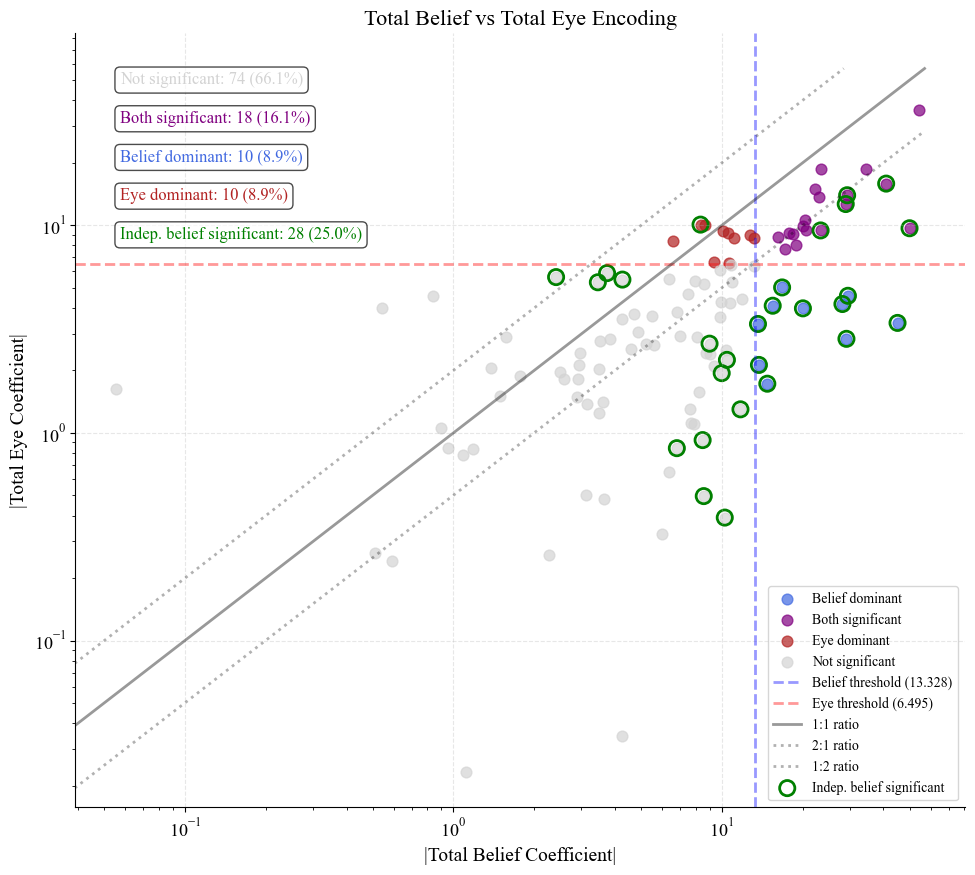

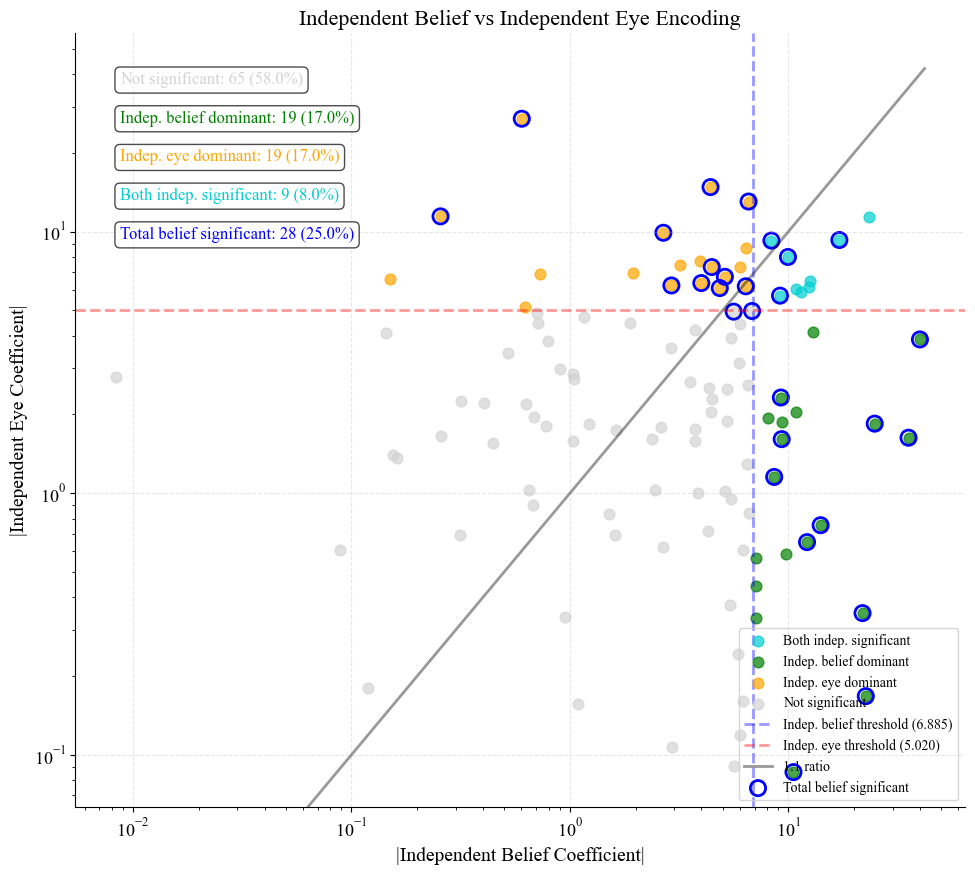

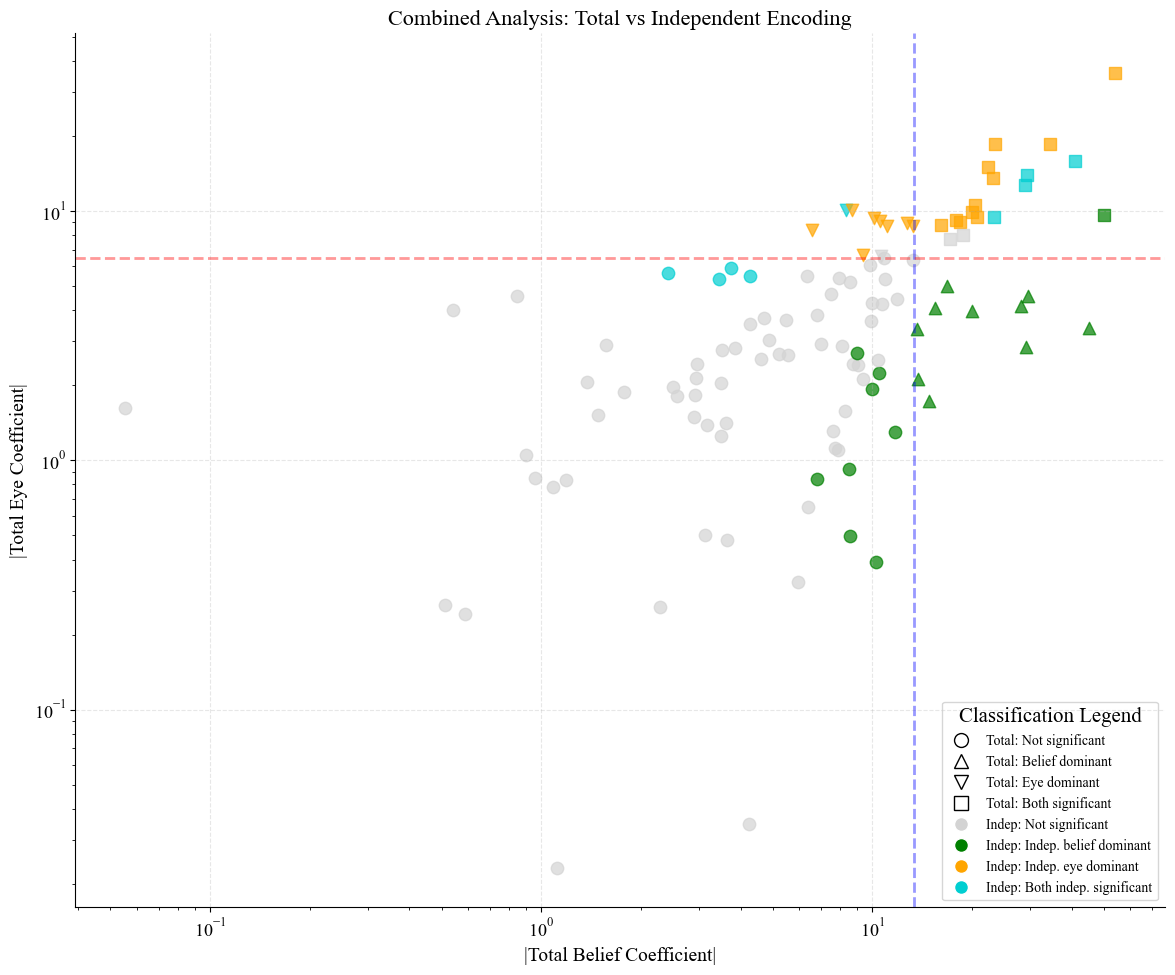

In [67]:
def analyze_neuron_encoding_distributions(timedf, n_bins=15):
    """
    Create two focused plots:
    1. Plot 1: Total belief vs total eye coefficients (abs values)
    2. Plot 2: Independent belief vs independent eye coefficients (abs values)
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins for time-based analysis
    """
    print("\n--- Focused Neuron Encoding Distribution Analysis ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, calculate coefficients using all data
    print("Calculating coefficients using all data...")
    
    # Calculate total belief coefficients
    model_total_belief = LinearRegression().fit(neural_data, belief_data)
    total_belief_coefs = model_total_belief.coef_
    
    # Calculate total eye coefficients
    model_total_eye = LinearRegression().fit(neural_data, eye_data)
    total_eye_coefs = model_total_eye.coef_[0]  # Flatten
    
    # Calculate independent belief coefficients
    model_eye = LinearRegression().fit(eye_data, neural_data)
    neural_residuals_after_eye = neural_data - model_eye.predict(eye_data)
    
    model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_data)
    indep_belief_coefs = model_indep_belief.coef_
    
    # Calculate independent eye coefficients
    model_belief = LinearRegression().fit(belief_data.reshape(-1, 1), neural_data)
    neural_residuals_after_belief = neural_data - model_belief.predict(belief_data.reshape(-1, 1))
    
    model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_data)
    indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten
    
    # Create a DataFrame for easier handling
    neuron_df = pd.DataFrame({
        'neuron_idx': np.arange(n_neurons),
        'total_belief_coef': total_belief_coefs,
        'total_eye_coef': total_eye_coefs,
        'indep_belief_coef': indep_belief_coefs,
        'indep_eye_coef': indep_eye_coefs,
        'total_belief_abs': np.abs(total_belief_coefs),
        'total_eye_abs': np.abs(total_eye_coefs),
        'indep_belief_abs': np.abs(indep_belief_coefs),
        'indep_eye_abs': np.abs(indep_eye_coefs)
    })
    
    # Calculate ratios for categorization
    neuron_df['total_ratio'] = neuron_df['total_belief_abs'] / (neuron_df['total_eye_abs'] + 1e-10)
    neuron_df['indep_ratio'] = neuron_df['indep_belief_abs'] / (neuron_df['indep_eye_abs'] + 1e-10)
    
    # Define thresholds for significance
    threshold_pct = 75  # Use top 25% as threshold
    threshold_total_belief = np.percentile(neuron_df['total_belief_abs'], threshold_pct)
    threshold_total_eye = np.percentile(neuron_df['total_eye_abs'], threshold_pct)
    threshold_indep_belief = np.percentile(neuron_df['indep_belief_abs'], threshold_pct)
    threshold_indep_eye = np.percentile(neuron_df['indep_eye_abs'], threshold_pct)
    
    # Create categorizations
    # For total encoding
    neuron_df['total_category'] = 'Not significant'
    
    # Belief dominant
    belief_dominant_mask = (neuron_df['total_belief_abs'] >= threshold_total_belief) & \
                           (neuron_df['total_eye_abs'] < threshold_total_eye) 
    neuron_df.loc[belief_dominant_mask, 'total_category'] = 'Belief dominant'
    
    # Eye dominant
    eye_dominant_mask = (neuron_df['total_belief_abs'] < threshold_total_belief) & \
                         (neuron_df['total_eye_abs'] >= threshold_total_eye)
    neuron_df.loc[eye_dominant_mask, 'total_category'] = 'Eye dominant'
    
    # Both
    both_mask = (neuron_df['total_belief_abs'] >= threshold_total_belief) & \
                (neuron_df['total_eye_abs'] >= threshold_total_eye)
    neuron_df.loc[both_mask, 'total_category'] = 'Both significant'
    
    # For independent encoding
    neuron_df['indep_category'] = 'Not significant'
    
    # Independent belief dominant
    indep_belief_dominant_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                                 (neuron_df['indep_eye_abs'] < threshold_indep_eye)
    neuron_df.loc[indep_belief_dominant_mask, 'indep_category'] = 'Indep. belief dominant'
    
    # Independent eye dominant
    indep_eye_dominant_mask = (neuron_df['indep_belief_abs'] < threshold_indep_belief) & \
                               (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
    neuron_df.loc[indep_eye_dominant_mask, 'indep_category'] = 'Indep. eye dominant'
    
    # Both independent
    indep_both_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                       (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
    neuron_df.loc[indep_both_mask, 'indep_category'] = 'Both indep. significant'
    
    # Print summary statistics
    print("\nNeuron categorization summary:")
    print(f"Total encoding categories:")
    for category, count in neuron_df['total_category'].value_counts().items():
        print(f"  {category}: {count} neurons ({count/n_neurons*100:.1f}%)")
    
    print(f"\nIndependent encoding categories:")
    for category, count in neuron_df['indep_category'].value_counts().items():
        print(f"  {category}: {count} neurons ({count/n_neurons*100:.1f}%)")
    
    # Cross-tabulation of categories
    print("\nCross-tabulation of total vs independent categories:")
    cross_tab = pd.crosstab(neuron_df['total_category'], neuron_df['indep_category'])
    print(cross_tab)
    
    # Create two figures
    fig1, ax1 = plt.subplots(figsize=(10, 9))
    fig2, ax2 = plt.subplots(figsize=(10, 9))
    
    # Plot 1: Total belief vs total eye
    # Use different marker styles and colors for different categories
    category_colors = {
        'Not significant': 'lightgray',
        'Belief dominant': 'royalblue',
        'Eye dominant': 'firebrick',
        'Both significant': 'purple',
        'Indep. belief dominant': 'green',
        'Indep. eye dominant': 'orange',
        'Both indep. significant': 'darkturquoise'
    }
    
    # Plot all neurons
    for category, group in neuron_df.groupby('total_category'):
        ax1.scatter(group['total_belief_abs'], group['total_eye_abs'],
                  alpha=0.7, s=60, c=category_colors[category], label=category)
    
    # Add reference lines
    ax1.axvline(threshold_total_belief, color='blue', linestyle='--', alpha=0.4,
              label=f'Belief threshold ({threshold_total_belief:.3f})')
    ax1.axhline(threshold_total_eye, color='red', linestyle='--', alpha=0.4,
              label=f'Eye threshold ({threshold_total_eye:.3f})')
    
    # Add ratio reference lines
    max_val = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
    ax1.plot([0, max_val], [0, max_val], 'k-', alpha=0.4, label='1:1 ratio')
    ax1.plot([0, max_val], [0, max_val/2], 'k:', alpha=0.3, label='2:1 ratio')
    ax1.plot([0, max_val/2], [0, max_val], 'k:', alpha=0.3, label='1:2 ratio')
    
    # Additionally highlight independent belief neurons
    indep_belief_significant = neuron_df['indep_belief_abs'] >= threshold_indep_belief
    ax1.scatter(neuron_df.loc[indep_belief_significant, 'total_belief_abs'],
              neuron_df.loc[indep_belief_significant, 'total_eye_abs'],
              s=120, facecolors='none', edgecolors='green', linewidth=2,
              label='Indep. belief significant')
    
    # Set labels and title
    ax1.set_xlabel('|Total Belief Coefficient|', fontsize=14)
    ax1.set_ylabel('|Total Eye Coefficient|', fontsize=14)
    ax1.set_title('Total Belief vs Total Eye Encoding', fontsize=16)
    
    # Add category counts
    text_y_pos = 0.95
    for category, count in neuron_df['total_category'].value_counts().items():
        ax1.text(0.05, text_y_pos, 
               f"{category}: {count} ({count/n_neurons*100:.1f}%)",
               transform=ax1.transAxes, 
               va='top', ha='left', fontsize=12,
               color=category_colors[category],
               bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        text_y_pos -= 0.05
    
    # Add independent belief count
    ax1.text(0.05, text_y_pos,
           f"Indep. belief significant: {sum(indep_belief_significant)} ({sum(indep_belief_significant)/n_neurons*100:.1f}%)",
           transform=ax1.transAxes,
           va='top', ha='left', fontsize=12,
           color='green',
           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    # Use logarithmic scale for better visualization
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    # Add grid
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Add legend
    ax1.legend(loc='lower right', fontsize=10)
    
    # Plot 2: Independent belief vs independent eye
    # Plot all neurons
    for category, group in neuron_df.groupby('indep_category'):
        ax2.scatter(group['indep_belief_abs'], group['indep_eye_abs'],
                  alpha=0.7, s=60, c=category_colors[category], label=category)
    
    # Add reference lines
    ax2.axvline(threshold_indep_belief, color='blue', linestyle='--', alpha=0.4,
              label=f'Indep. belief threshold ({threshold_indep_belief:.3f})')
    ax2.axhline(threshold_indep_eye, color='red', linestyle='--', alpha=0.4,
              label=f'Indep. eye threshold ({threshold_indep_eye:.3f})')
    
    # Add ratio reference lines
    max_val = max(ax2.get_xlim()[1], ax2.get_ylim()[1])
    ax2.plot([0, max_val], [0, max_val], 'k-', alpha=0.4, label='1:1 ratio')
    
    # Additionally highlight total belief neurons
    total_belief_significant = neuron_df['total_belief_abs'] >= threshold_total_belief
    ax2.scatter(neuron_df.loc[total_belief_significant, 'indep_belief_abs'],
              neuron_df.loc[total_belief_significant, 'indep_eye_abs'],
              s=120, facecolors='none', edgecolors='blue', linewidth=2,
              label='Total belief significant')
    
    # Set labels and title
    ax2.set_xlabel('|Independent Belief Coefficient|', fontsize=14)
    ax2.set_ylabel('|Independent Eye Coefficient|', fontsize=14)
    ax2.set_title('Independent Belief vs Independent Eye Encoding', fontsize=16)
    
    # Add category counts
    text_y_pos = 0.95
    for category, count in neuron_df['indep_category'].value_counts().items():
        ax2.text(0.05, text_y_pos, 
               f"{category}: {count} ({count/n_neurons*100:.1f}%)",
               transform=ax2.transAxes, 
               va='top', ha='left', fontsize=12,
               color=category_colors[category],
               bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        text_y_pos -= 0.05
    
    # Add total belief count
    ax2.text(0.05, text_y_pos,
           f"Total belief significant: {sum(total_belief_significant)} ({sum(total_belief_significant)/n_neurons*100:.1f}%)",
           transform=ax2.transAxes,
           va='top', ha='left', fontsize=12,
           color='blue',
           bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    # Use logarithmic scale for better visualization
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    
    # Add grid
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # Add legend
    ax2.legend(loc='lower right', fontsize=10)
    
    # Create a third figure showing the overlap
    fig3, ax3 = plt.subplots(figsize=(12, 10))
    
    # Create a cross-classification visualization
    # Use a colorful circle for each neuron, position based on total belief/eye,
    # color based on independent belief/eye
    
    # Define a colormap based on independent classification
    indep_cmap = {
        'Not significant': 'lightgray',
        'Indep. belief dominant': 'green',
        'Indep. eye dominant': 'orange',
        'Both indep. significant': 'darkturquoise'
    }
    
    # Create markers by total categories
    marker_map = {
        'Not significant': 'o',  # circle
        'Belief dominant': '^',  # triangle up
        'Eye dominant': 'v',     # triangle down
        'Both significant': 's'  # square
    }
    
    # Plot each neuron
    for _, neuron in neuron_df.iterrows():
        ax3.scatter(neuron['total_belief_abs'], neuron['total_eye_abs'],
                  s=80, 
                  marker=marker_map[neuron['total_category']], 
                  c=indep_cmap[neuron['indep_category']],
                  alpha=0.7)
    
    # Add threshold lines
    ax3.axvline(threshold_total_belief, color='blue', linestyle='--', alpha=0.4)
    ax3.axhline(threshold_total_eye, color='red', linestyle='--', alpha=0.4)
    
    # Set labels and title
    ax3.set_xlabel('|Total Belief Coefficient|', fontsize=14)
    ax3.set_ylabel('|Total Eye Coefficient|', fontsize=14)
    ax3.set_title('Combined Analysis: Total vs Independent Encoding', fontsize=16)
    
    # Add custom legend
    # For total categories (markers)
    from matplotlib.lines import Line2D
    
    legend_elements = []
    for category, marker in marker_map.items():
        legend_elements.append(
            Line2D([0], [0], marker=marker, color='black', linestyle='',
                  markerfacecolor='white', markersize=10, label=f'Total: {category}')
        )
    
    # For independent categories (colors)
    for category, color in indep_cmap.items():
        legend_elements.append(
            Line2D([0], [0], marker='o', color='white', linestyle='',
                  markerfacecolor=color, markersize=10, label=f'Indep: {category}')
        )
    
    ax3.legend(handles=legend_elements, loc='lower right', fontsize=10, 
              title='Classification Legend')
    
    # Add grid
    ax3.grid(True, linestyle='--', alpha=0.3)
    
    # Use logarithmic scale
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    
    # Adjust layout for all figures
    for fig in [fig1, fig2, fig3]:
        fig.tight_layout()
    
    return fig1, fig2, fig3, neuron_df

# Run the analysis
print("\nRunning Focused Neuron Encoding Analysis...")
total_fig, indep_fig, combined_fig, neuron_df = analyze_neuron_encoding_distributions(timedf)
plt.figure(total_fig.number)
plt.savefig('total_belief_vs_eye.png', dpi=300, bbox_inches='tight')
plt.figure(indep_fig.number)
plt.savefig('independent_belief_vs_eye.png', dpi=300, bbox_inches='tight')
plt.figure(combined_fig.number)
plt.savefig('combined_encoding_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



Running Neuron Encoding Analysis By Phases...

--- Neuron Encoding Analysis By Phases ---
Analyzing contributions of 112 neurons
Performing time-binned analysis to identify phases...
Bin 1: Time=0.00-0.07, Total Belief r=0.535, Total Eye r=0.448, Indep Belief r=0.536, Indep Eye r=0.450
Bin 2: Time=0.07-0.13, Total Belief r=0.879, Total Eye r=0.532, Indep Belief r=0.823, Indep Eye r=0.485
Bin 3: Time=0.13-0.20, Total Belief r=0.864, Total Eye r=0.706, Indep Belief r=0.618, Indep Eye r=0.423
Bin 4: Time=0.20-0.27, Total Belief r=0.840, Total Eye r=0.823, Indep Belief r=0.401, Indep Eye r=0.376
Bin 5: Time=0.27-0.33, Total Belief r=0.806, Total Eye r=0.829, Indep Belief r=0.274, Indep Eye r=0.302
Bin 6: Time=0.33-0.40, Total Belief r=0.766, Total Eye r=0.801, Indep Belief r=0.198, Indep Eye r=0.250
Bin 7: Time=0.40-0.47, Total Belief r=0.688, Total Eye r=0.757, Indep Belief r=0.164, Indep Eye r=0.274
Bin 8: Time=0.47-0.53, Total Belief r=0.583, Total Eye r=0.684, Indep Belief r=0.166, In

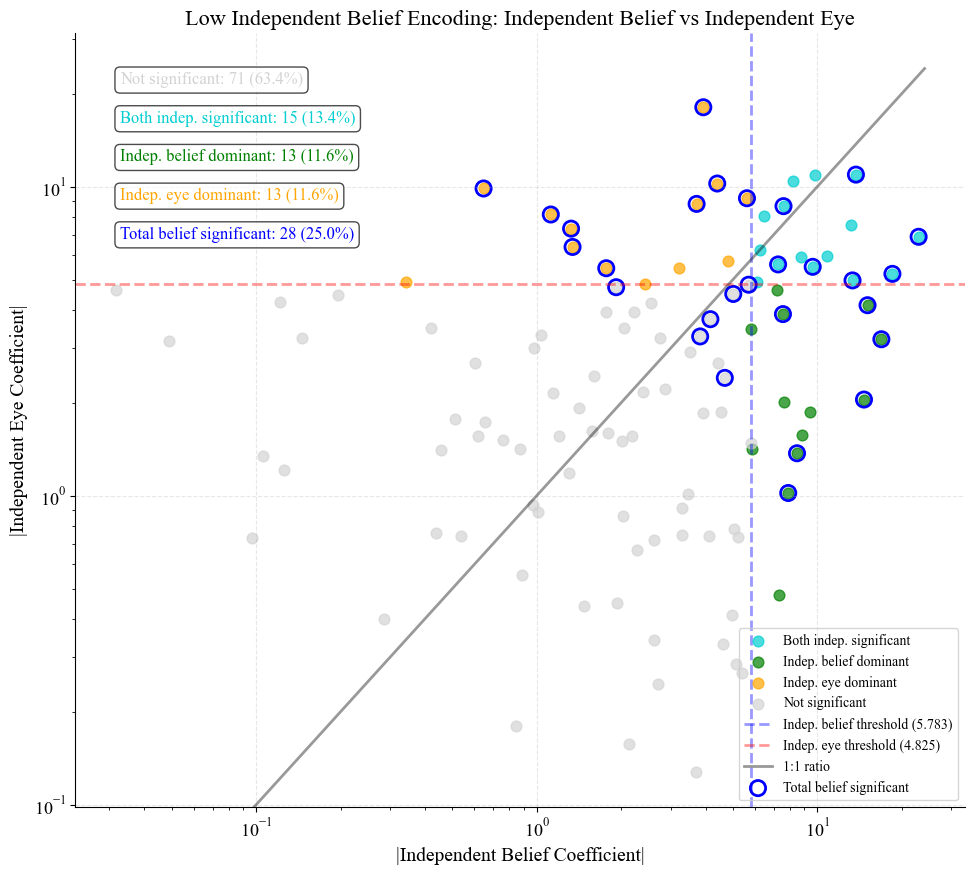

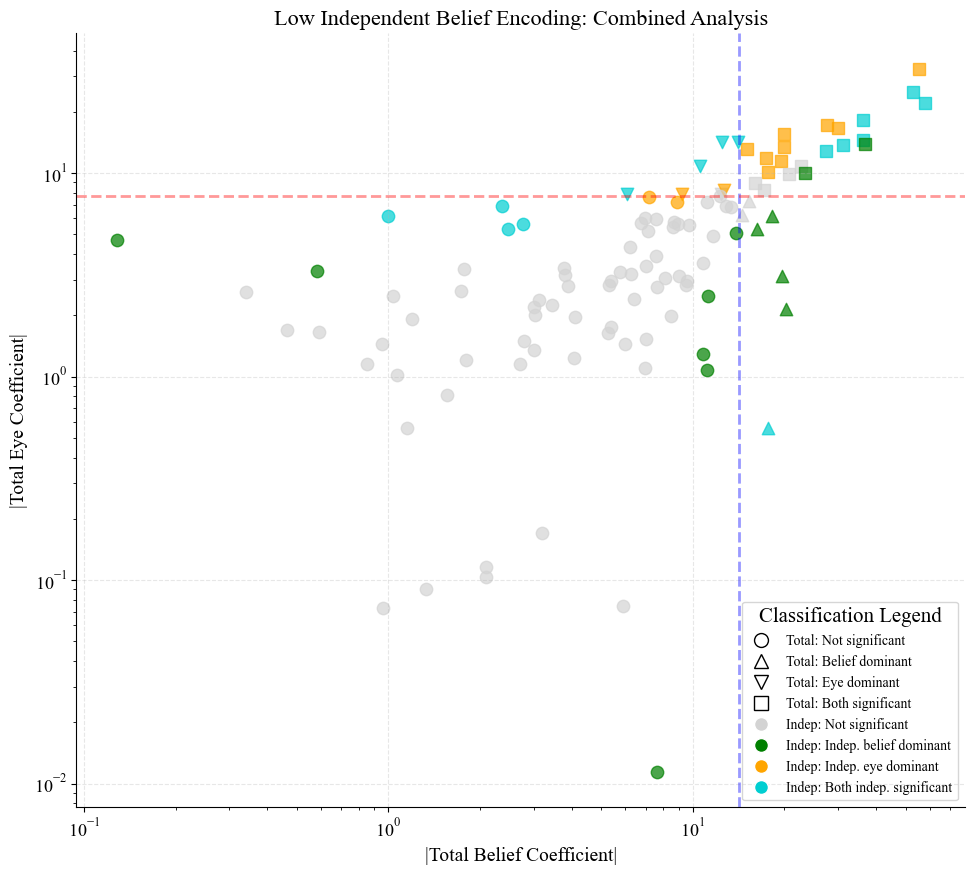

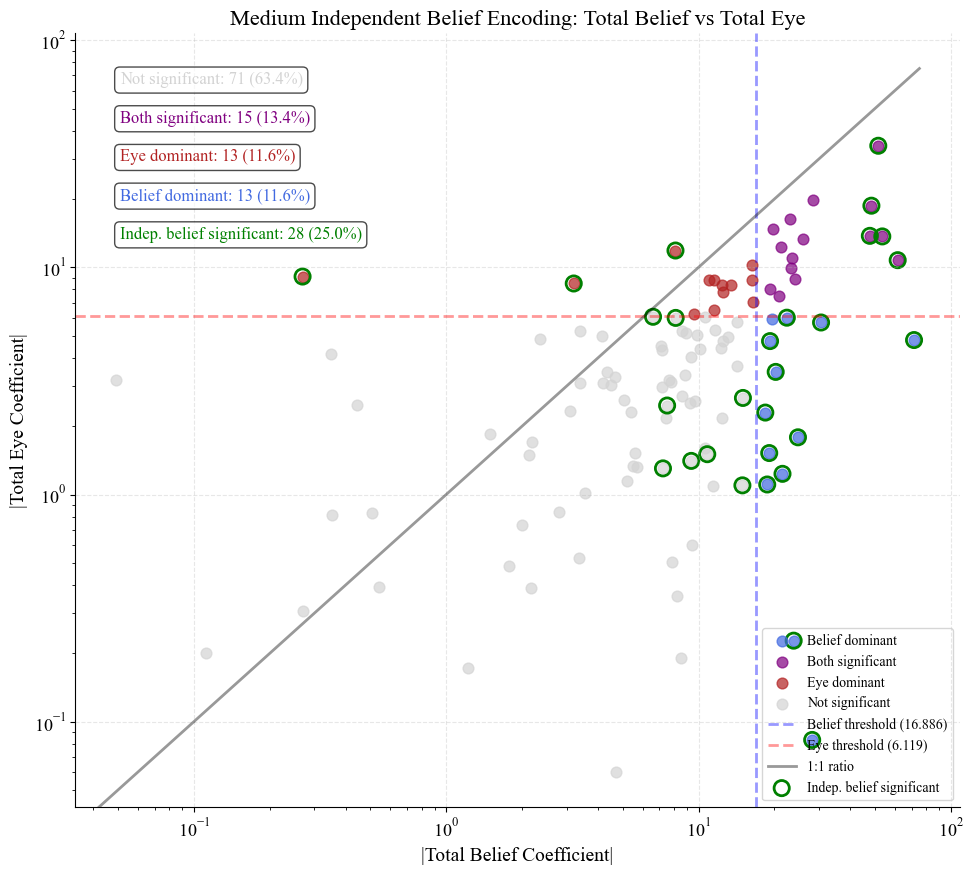

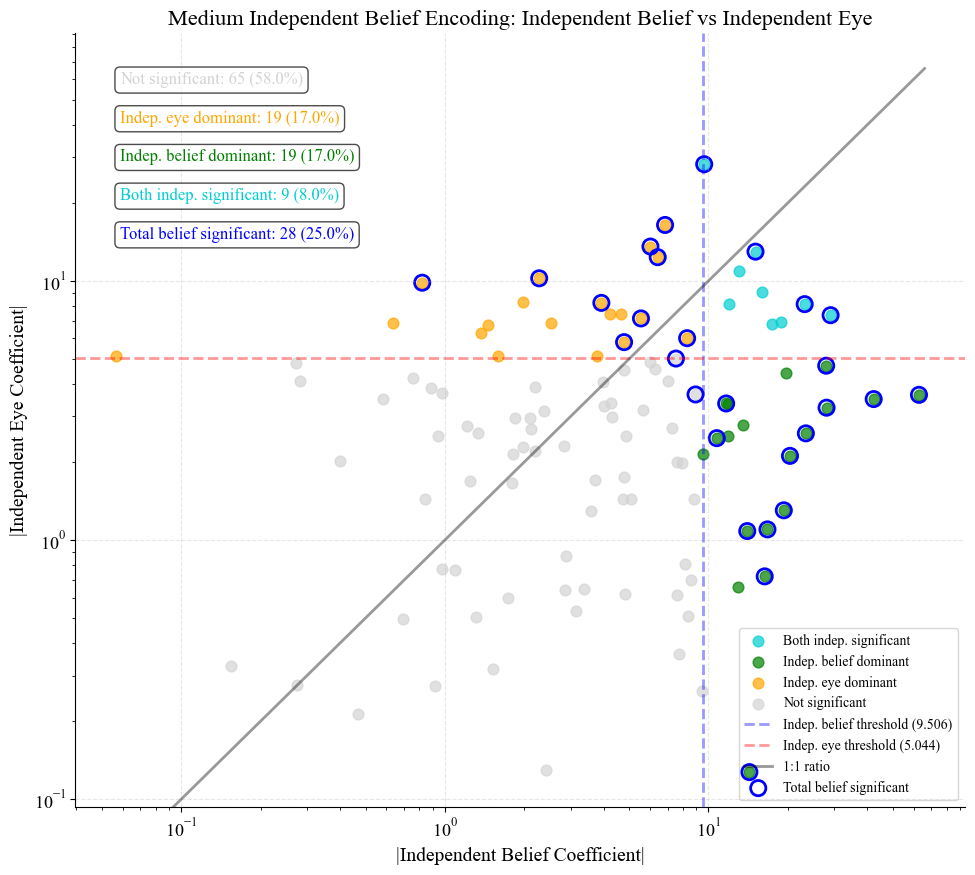

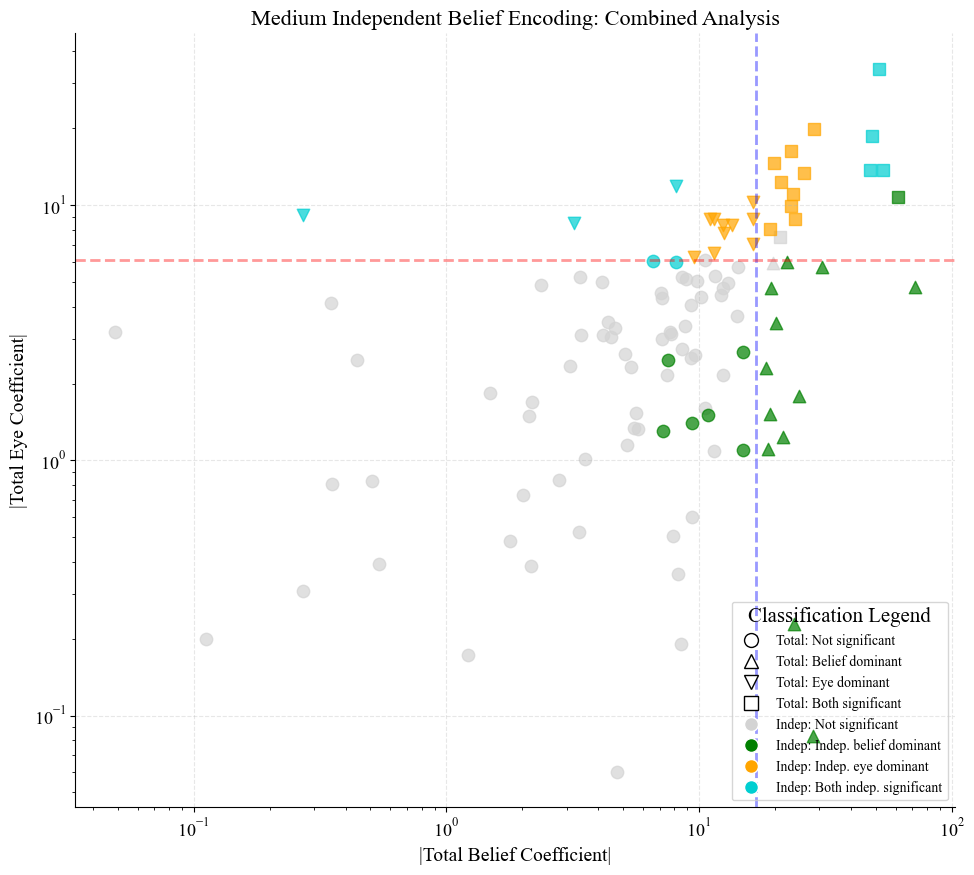

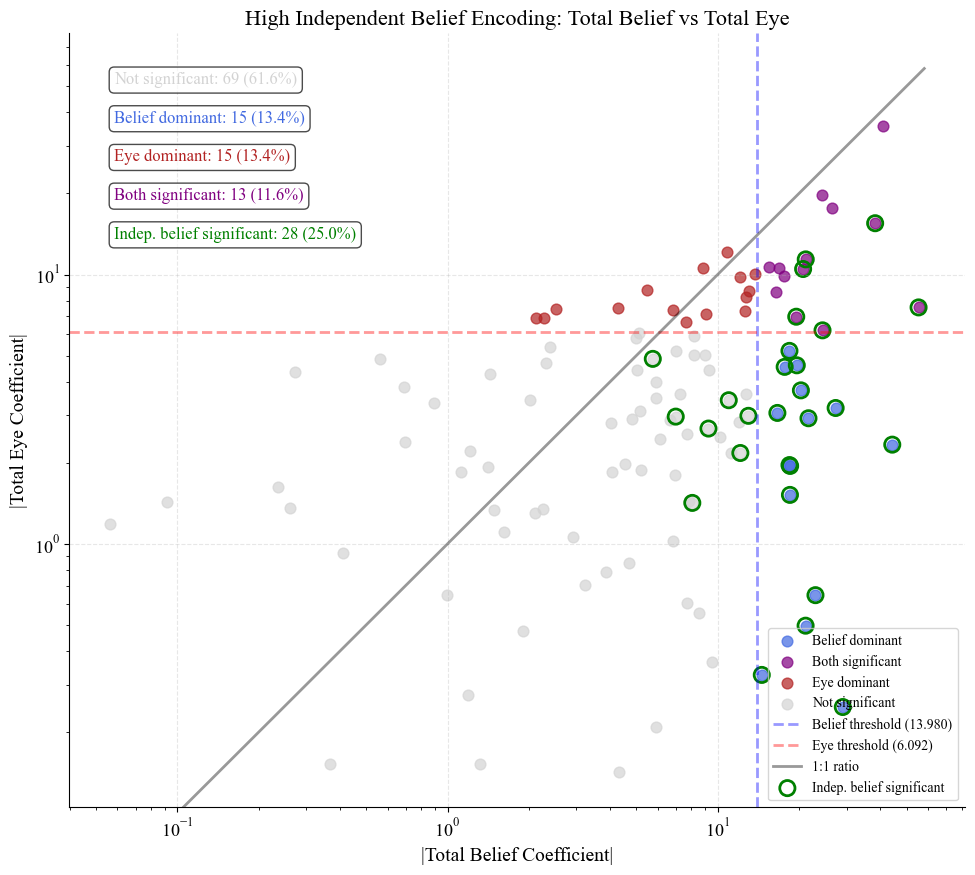

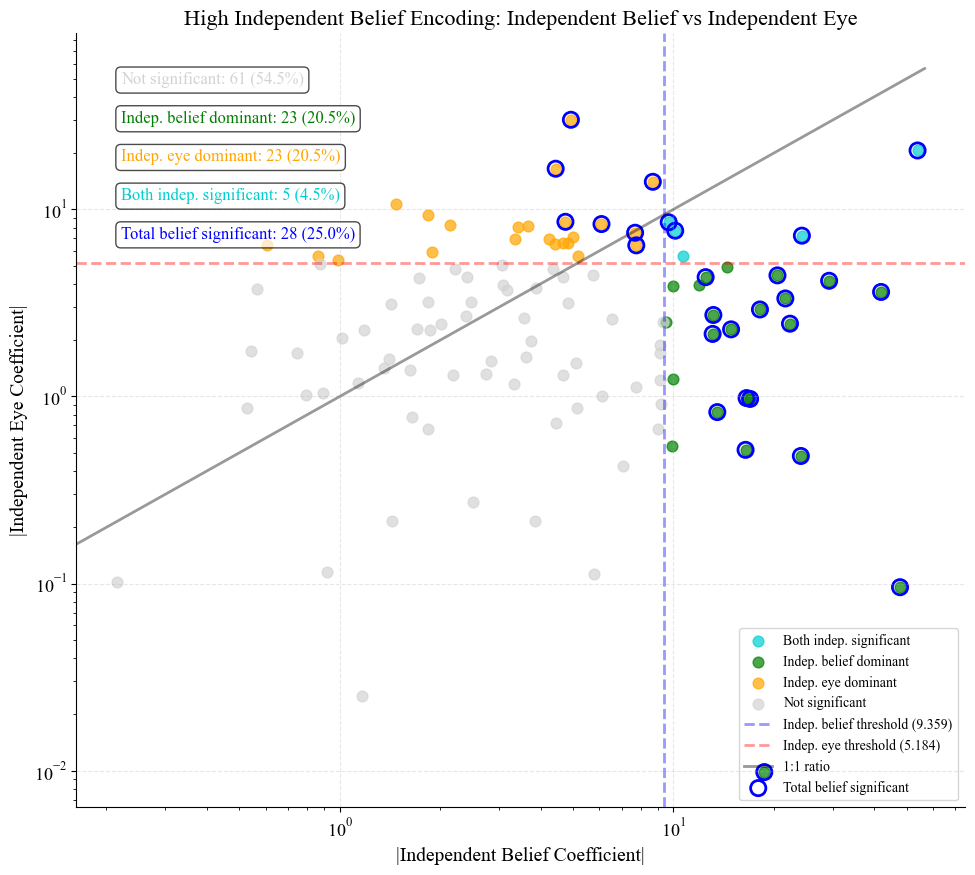

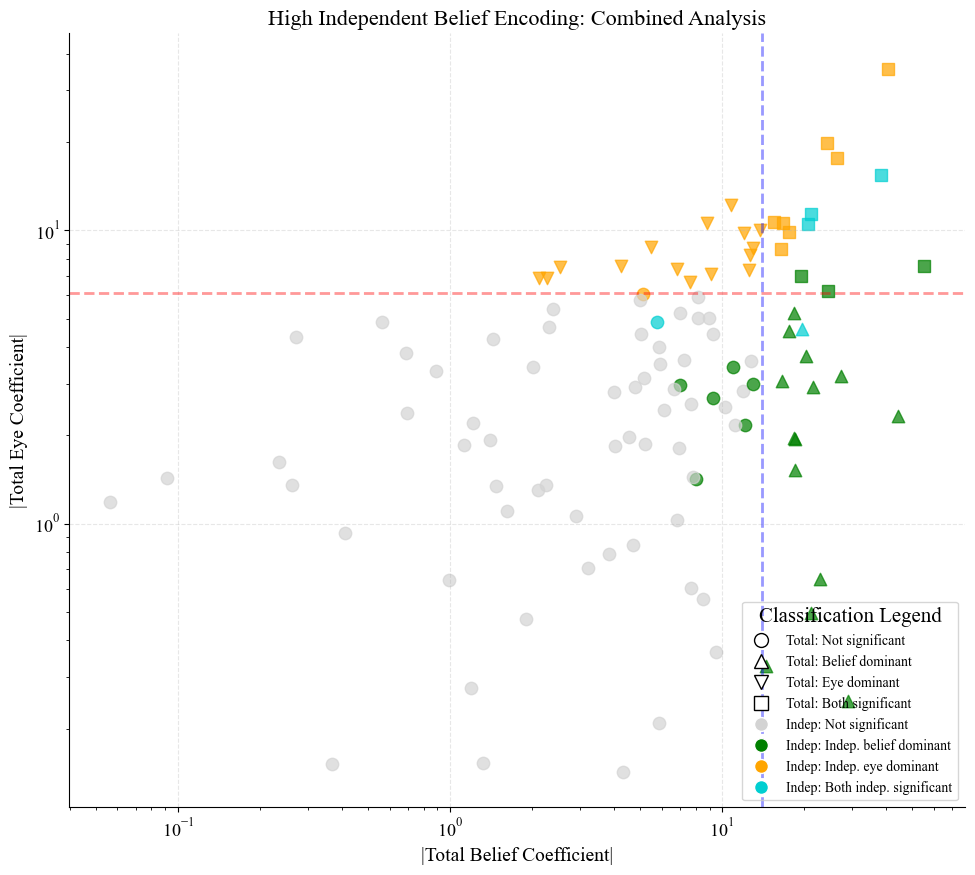

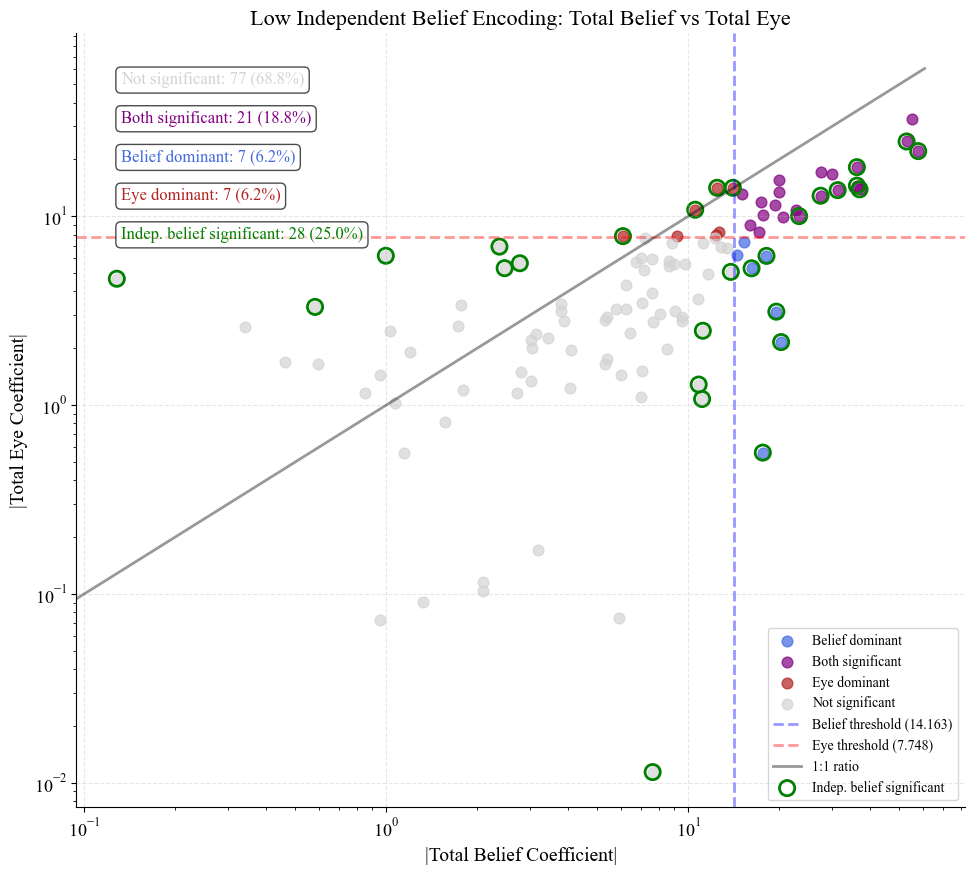

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [68]:
def analyze_neuron_encoding_by_phases(timedf, n_bins=15):
    """
    Create three plots for each phase (low, medium, high):
    1. Total belief vs total eye
    2. Independent belief vs independent eye
    3. Combined analysis
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame with neural, belief, eye, and uncertainty data
    n_bins : int
        Number of bins for time-based analysis
    """
    print("\n--- Neuron Encoding Analysis By Phases ---")
    
    # Extract data
    neural_data = np.vstack(timedf['PPC'].to_numpy())
    belief_data = timedf['belief'].to_numpy()
    eye_data = timedf['eye'].to_numpy().reshape(-1, 1)
    time_ratio = timedf['timeratio'].to_numpy()
    
    # Get number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Analyzing contributions of {n_neurons} neurons")
    
    # First, perform time-binned analysis to identify phases
    print("Performing time-binned analysis to identify phases...")
    
    # Define time bins
    time_bin_edges = np.linspace(0, 1, n_bins+1)
    
    # Initialize arrays to store encoding quality for each time bin
    time_bin_centers = []
    total_belief_r_values = []
    total_eye_r_values = []
    indep_belief_r_values = []
    indep_eye_r_values = []
    
    # Also store bin masks for later use
    bin_masks = {}
    
    for i in range(n_bins):
        bin_start = time_bin_edges[i]
        bin_end = time_bin_edges[i+1]
        
        # Create mask for current bin
        if i == n_bins - 1:
            bin_mask = (time_ratio >= bin_start) & (time_ratio <= bin_end)
        else:
            bin_mask = (time_ratio >= bin_start) & (time_ratio < bin_end)
            
        # Store mask for later use
        bin_masks[i] = bin_mask
        
        # Select data for current bin
        neural_bin = neural_data[bin_mask]
        belief_bin = belief_data[bin_mask]
        eye_bin = eye_data[bin_mask]
        
        n_samples = len(belief_bin)
        if n_samples < 20:  # Skip bins with too few samples
            continue
            
        # Calculate encoding strength for this bin
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Initialize predictions arrays
        belief_pred_total = np.zeros_like(belief_bin)
        eye_pred_total = np.zeros_like(eye_bin)
        eye_pred_independent = np.zeros_like(eye_bin)
        belief_pred_independent = np.zeros_like(belief_bin)
        
        # Perform cross-validation
        for train_idx, test_idx in kf.split(neural_bin):
            X_train, X_test = neural_bin[train_idx], neural_bin[test_idx]
            belief_train, belief_test = belief_bin[train_idx], belief_bin[test_idx]
            eye_train, eye_test = eye_bin[train_idx], eye_bin[test_idx]
            
            # Total belief encoding
            model_total = LinearRegression().fit(X_train, belief_train)
            belief_pred_total[test_idx] = model_total.predict(X_test)
            
            # Total eye encoding
            model_total_eye = LinearRegression().fit(X_train, eye_train)
            eye_pred_total[test_idx] = model_total_eye.predict(X_test)
            
            # Independent belief encoding
            model_eye = LinearRegression().fit(eye_train, X_train)
            X_residual_train = X_train - model_eye.predict(eye_train)
            X_residual_test = X_test - model_eye.predict(eye_test)
            model_indep = LinearRegression().fit(X_residual_train, belief_train)
            belief_pred_independent[test_idx] = model_indep.predict(X_residual_test)
            
            # Independent eye encoding
            model_belief = LinearRegression().fit(belief_train.reshape(-1, 1), X_train)
            X_residual_belief_train = X_train - model_belief.predict(belief_train.reshape(-1, 1))
            X_residual_belief_test = X_test - model_belief.predict(belief_test.reshape(-1, 1))
            model_indep_eye = LinearRegression().fit(X_residual_belief_train, eye_train)
            eye_pred_independent[test_idx] = model_indep_eye.predict(X_residual_belief_test)
        
        # Calculate performance metrics
        r_total_belief, _ = pearsonr(belief_bin, belief_pred_total)
        r_total_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_total.flatten())
        r_indep_belief, _ = pearsonr(belief_bin, belief_pred_independent)
        r_indep_eye, _ = pearsonr(eye_bin.flatten(), eye_pred_independent.flatten())
        
        # Store results
        time_bin_centers.append((bin_start + bin_end) / 2)
        total_belief_r_values.append(r_total_belief)
        total_eye_r_values.append(r_total_eye)
        indep_belief_r_values.append(r_indep_belief)
        indep_eye_r_values.append(r_indep_eye)
        
        print(f"Bin {i+1}: Time={bin_start:.2f}-{bin_end:.2f}, " +
              f"Total Belief r={r_total_belief:.3f}, " +
              f"Total Eye r={r_total_eye:.3f}, " +
              f"Indep Belief r={r_indep_belief:.3f}, " +
              f"Indep Eye r={r_indep_eye:.3f}")
    
    # Identify phases based on independent belief encoding
    # Convert to arrays
    time_bin_centers = np.array(time_bin_centers)
    indep_belief_r_values = np.array(indep_belief_r_values)
    
    # Sort bins by independent belief encoding strength
    sort_idx = np.argsort(indep_belief_r_values)
    
    # Identify phases (low, med, high) based on independent belief encoding
    n_bins_per_phase = len(sort_idx) // 3
    
    # Low phase: bottom third of bins by independent encoding performance
    low_phase_bins = sort_idx[:n_bins_per_phase]
    med_phase_bins = sort_idx[n_bins_per_phase:2*n_bins_per_phase]
    high_phase_bins = sort_idx[2*n_bins_per_phase:]
    
    # Define phases
    phases = {
        'low': {
            'bins': low_phase_bins,
            'name': 'Low Independent Belief Encoding',
            'color': 'salmon'
        },
        'med': {
            'bins': med_phase_bins,
            'name': 'Medium Independent Belief Encoding',
            'color': 'cornflowerblue'
        },
        'high': {
            'bins': high_phase_bins,
            'name': 'High Independent Belief Encoding',
            'color': 'mediumseagreen'
        }
    }
    
    # Print phase information
    for phase_name, phase_info in phases.items():
        phase_bins = phase_info['bins']
        phase_times = [time_bin_centers[i] for i in phase_bins]
        print(f"\n{phase_name.capitalize()} phase bins: {phase_bins}")
        print(f"{phase_name.capitalize()} phase time ratios: {[f'{t:.2f}' for t in phase_times]}")
        
        # Calculate average encoding performance in this phase
        avg_indep_belief = np.mean([indep_belief_r_values[i] for i in phase_bins])
        print(f"Average Independent Belief r: {avg_indep_belief:.3f}")
    
    # Create combined data masks for each phase
    phase_masks = {
        'low': np.zeros_like(time_ratio, dtype=bool),
        'med': np.zeros_like(time_ratio, dtype=bool),
        'high': np.zeros_like(time_ratio, dtype=bool)
    }
    
    for phase_name, phase_info in phases.items():
        for bin_idx in phase_info['bins']:
            phase_masks[phase_name] |= bin_masks.get(bin_idx, np.zeros_like(time_ratio, dtype=bool))
    
    # Calculate neuron coefficients for each phase
    phase_coefficients = {}
    phase_neuron_dfs = {}
    
    # Function to create the three plots for a given phase
    def create_phase_plots(phase_name, neuron_df, n_neurons, threshold_pct=75):
        """Create three plots for a specific phase"""
        
        # Define thresholds for significance
        threshold_total_belief = np.percentile(neuron_df['total_belief_abs'], threshold_pct)
        threshold_total_eye = np.percentile(neuron_df['total_eye_abs'], threshold_pct)
        threshold_indep_belief = np.percentile(neuron_df['indep_belief_abs'], threshold_pct)
        threshold_indep_eye = np.percentile(neuron_df['indep_eye_abs'], threshold_pct)
        
        # Create categorizations
        # For total encoding
        neuron_df['total_category'] = 'Not significant'
        
        # Belief dominant
        belief_dominant_mask = (neuron_df['total_belief_abs'] >= threshold_total_belief) & \
                               (neuron_df['total_eye_abs'] < threshold_total_eye) 
        neuron_df.loc[belief_dominant_mask, 'total_category'] = 'Belief dominant'
        
        # Eye dominant
        eye_dominant_mask = (neuron_df['total_belief_abs'] < threshold_total_belief) & \
                             (neuron_df['total_eye_abs'] >= threshold_total_eye)
        neuron_df.loc[eye_dominant_mask, 'total_category'] = 'Eye dominant'
        
        # Both
        both_mask = (neuron_df['total_belief_abs'] >= threshold_total_belief) & \
                    (neuron_df['total_eye_abs'] >= threshold_total_eye)
        neuron_df.loc[both_mask, 'total_category'] = 'Both significant'
        
        # For independent encoding
        neuron_df['indep_category'] = 'Not significant'
        
        # Independent belief dominant
        indep_belief_dominant_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                                     (neuron_df['indep_eye_abs'] < threshold_indep_eye)
        neuron_df.loc[indep_belief_dominant_mask, 'indep_category'] = 'Indep. belief dominant'
        
        # Independent eye dominant
        indep_eye_dominant_mask = (neuron_df['indep_belief_abs'] < threshold_indep_belief) & \
                                   (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
        neuron_df.loc[indep_eye_dominant_mask, 'indep_category'] = 'Indep. eye dominant'
        
        # Both independent
        indep_both_mask = (neuron_df['indep_belief_abs'] >= threshold_indep_belief) & \
                           (neuron_df['indep_eye_abs'] >= threshold_indep_eye)
        neuron_df.loc[indep_both_mask, 'indep_category'] = 'Both indep. significant'
        
        # Print summary statistics
        print(f"\nNeuron categorization summary for {phase_name} phase:")
        print(f"Total encoding categories:")
        for category, count in neuron_df['total_category'].value_counts().items():
            print(f"  {category}: {count} neurons ({count/n_neurons*100:.1f}%)")
        
        print(f"\nIndependent encoding categories:")
        for category, count in neuron_df['indep_category'].value_counts().items():
            print(f"  {category}: {count} neurons ({count/n_neurons*100:.1f}%)")
        
        # Cross-tabulation of categories
        print(f"\nCross-tabulation of total vs independent categories for {phase_name} phase:")
        cross_tab = pd.crosstab(neuron_df['total_category'], neuron_df['indep_category'])
        print(cross_tab)
        
        # Create figures
        fig1, ax1 = plt.subplots(figsize=(10, 9))  # Total belief vs total eye
        fig2, ax2 = plt.subplots(figsize=(10, 9))  # Independent belief vs independent eye
        fig3, ax3 = plt.subplots(figsize=(10, 9))  # Combined analysis
        
        # Plot 1: Total belief vs total eye
        category_colors = {
            'Not significant': 'lightgray',
            'Belief dominant': 'royalblue',
            'Eye dominant': 'firebrick',
            'Both significant': 'purple',
            'Indep. belief dominant': 'green',
            'Indep. eye dominant': 'orange',
            'Both indep. significant': 'darkturquoise'
        }
        
        # Plot all neurons
        for category, group in neuron_df.groupby('total_category'):
            ax1.scatter(group['total_belief_abs'], group['total_eye_abs'],
                      alpha=0.7, s=60, c=category_colors[category], label=category)
        
        # Add reference lines
        ax1.axvline(threshold_total_belief, color='blue', linestyle='--', alpha=0.4,
                  label=f'Belief threshold ({threshold_total_belief:.3f})')
        ax1.axhline(threshold_total_eye, color='red', linestyle='--', alpha=0.4,
                  label=f'Eye threshold ({threshold_total_eye:.3f})')
        
        # Add ratio reference lines
        max_val = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
        ax1.plot([0, max_val], [0, max_val], 'k-', alpha=0.4, label='1:1 ratio')
        
        # Additionally highlight independent belief neurons
        indep_belief_significant = neuron_df['indep_belief_abs'] >= threshold_indep_belief
        ax1.scatter(neuron_df.loc[indep_belief_significant, 'total_belief_abs'],
                  neuron_df.loc[indep_belief_significant, 'total_eye_abs'],
                  s=120, facecolors='none', edgecolors='green', linewidth=2,
                  label='Indep. belief significant')
        
        # Set labels and title
        ax1.set_xlabel('|Total Belief Coefficient|', fontsize=14)
        ax1.set_ylabel('|Total Eye Coefficient|', fontsize=14)
        ax1.set_title(f'{phases[phase_name]["name"]}: Total Belief vs Total Eye', fontsize=16)
        
        # Add category counts
        text_y_pos = 0.95
        for category, count in neuron_df['total_category'].value_counts().items():
            ax1.text(0.05, text_y_pos, 
                   f"{category}: {count} ({count/n_neurons*100:.1f}%)",
                   transform=ax1.transAxes, 
                   va='top', ha='left', fontsize=12,
                   color=category_colors[category],
                   bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
            text_y_pos -= 0.05
        
        # Add independent belief count
        ax1.text(0.05, text_y_pos,
               f"Indep. belief significant: {sum(indep_belief_significant)} ({sum(indep_belief_significant)/n_neurons*100:.1f}%)",
               transform=ax1.transAxes,
               va='top', ha='left', fontsize=12,
               color='green',
               bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        
        # Use logarithmic scale for better visualization
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        
        # Add grid
        ax1.grid(True, linestyle='--', alpha=0.3)
        
        # Add legend
        ax1.legend(loc='lower right', fontsize=10)
        
        # Plot 2: Independent belief vs independent eye
        # Plot all neurons
        for category, group in neuron_df.groupby('indep_category'):
            ax2.scatter(group['indep_belief_abs'], group['indep_eye_abs'],
                      alpha=0.7, s=60, c=category_colors[category], label=category)
        
        # Add reference lines
        ax2.axvline(threshold_indep_belief, color='blue', linestyle='--', alpha=0.4,
                  label=f'Indep. belief threshold ({threshold_indep_belief:.3f})')
        ax2.axhline(threshold_indep_eye, color='red', linestyle='--', alpha=0.4,
                  label=f'Indep. eye threshold ({threshold_indep_eye:.3f})')
        
        # Add ratio reference lines
        max_val = max(ax2.get_xlim()[1], ax2.get_ylim()[1])
        ax2.plot([0, max_val], [0, max_val], 'k-', alpha=0.4, label='1:1 ratio')
        
        # Additionally highlight total belief neurons
        total_belief_significant = neuron_df['total_belief_abs'] >= threshold_total_belief
        ax2.scatter(neuron_df.loc[total_belief_significant, 'indep_belief_abs'],
                  neuron_df.loc[total_belief_significant, 'indep_eye_abs'],
                  s=120, facecolors='none', edgecolors='blue', linewidth=2,
                  label='Total belief significant')
        
        # Set labels and title
        ax2.set_xlabel('|Independent Belief Coefficient|', fontsize=14)
        ax2.set_ylabel('|Independent Eye Coefficient|', fontsize=14)
        ax2.set_title(f'{phases[phase_name]["name"]}: Independent Belief vs Independent Eye', fontsize=16)
        
        # Add category counts
        text_y_pos = 0.95
        for category, count in neuron_df['indep_category'].value_counts().items():
            ax2.text(0.05, text_y_pos, 
                   f"{category}: {count} ({count/n_neurons*100:.1f}%)",
                   transform=ax2.transAxes, 
                   va='top', ha='left', fontsize=12,
                   color=category_colors[category],
                   bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
            text_y_pos -= 0.05
        
        # Add total belief count
        ax2.text(0.05, text_y_pos,
               f"Total belief significant: {sum(total_belief_significant)} ({sum(total_belief_significant)/n_neurons*100:.1f}%)",
               transform=ax2.transAxes,
               va='top', ha='left', fontsize=12,
               color='blue',
               bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
        
        # Use logarithmic scale for better visualization
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        
        # Add grid
        ax2.grid(True, linestyle='--', alpha=0.3)
        
        # Add legend
        ax2.legend(loc='lower right', fontsize=10)
        
        # Plot 3: Combined analysis
        # Define a colormap based on independent classification
        indep_cmap = {
            'Not significant': 'lightgray',
            'Indep. belief dominant': 'green',
            'Indep. eye dominant': 'orange',
            'Both indep. significant': 'darkturquoise'
        }
        
        # Create markers by total categories
        marker_map = {
            'Not significant': 'o',  # circle
            'Belief dominant': '^',  # triangle up
            'Eye dominant': 'v',     # triangle down
            'Both significant': 's'  # square
        }
        
        # Plot each neuron
        for _, neuron in neuron_df.iterrows():
            ax3.scatter(neuron['total_belief_abs'], neuron['total_eye_abs'],
                      s=80, 
                      marker=marker_map[neuron['total_category']], 
                      c=indep_cmap[neuron['indep_category']],
                      alpha=0.7)
        
        # Add threshold lines
        ax3.axvline(threshold_total_belief, color='blue', linestyle='--', alpha=0.4)
        ax3.axhline(threshold_total_eye, color='red', linestyle='--', alpha=0.4)
        
        # Set labels and title
        ax3.set_xlabel('|Total Belief Coefficient|', fontsize=14)
        ax3.set_ylabel('|Total Eye Coefficient|', fontsize=14)
        ax3.set_title(f'{phases[phase_name]["name"]}: Combined Analysis', fontsize=16)
        
        # Add custom legend
        # For total categories (markers)
        from matplotlib.lines import Line2D
        
        legend_elements = []
        for category, marker in marker_map.items():
            legend_elements.append(
                Line2D([0], [0], marker=marker, color='black', linestyle='',
                      markerfacecolor='white', markersize=10, label=f'Total: {category}')
            )
        
        # For independent categories (colors)
        for category, color in indep_cmap.items():
            legend_elements.append(
                Line2D([0], [0], marker='o', color='white', linestyle='',
                      markerfacecolor=color, markersize=10, label=f'Indep: {category}')
            )
        
        ax3.legend(handles=legend_elements, loc='lower right', fontsize=10, 
                  title='Classification Legend')
        
        # Add grid
        ax3.grid(True, linestyle='--', alpha=0.3)
        
        # Use logarithmic scale
        ax3.set_xscale('log')
        ax3.set_yscale('log')
        
        # Adjust layout for all figures
        for fig in [fig1, fig2, fig3]:
            fig.tight_layout()
        
        return [fig1, fig2, fig3]
    
    # Process each phase
    all_figures = []
    
    for phase_name, phase_mask in phase_masks.items():
        # Skip if no data in this phase
        if np.sum(phase_mask) < 20:
            print(f"Skipping {phase_name} phase - insufficient data")
            continue
            
        print(f"\nCalculating coefficients for {phase_name} phase...")
        
        # Extract data for this phase
        neural_phase = neural_data[phase_mask]
        belief_phase = belief_data[phase_mask]
        eye_phase = eye_data[phase_mask]
        
        # Calculate total belief coefficients
        model_total_belief = LinearRegression().fit(neural_phase, belief_phase)
        total_belief_coefs = model_total_belief.coef_
        
        # Calculate total eye coefficients
        model_total_eye = LinearRegression().fit(neural_phase, eye_phase)
        total_eye_coefs = model_total_eye.coef_[0]  # Flatten
        
        # Calculate independent belief coefficients
        model_eye = LinearRegression().fit(eye_phase, neural_phase)
        neural_residuals_after_eye = neural_phase - model_eye.predict(eye_phase)
        
        model_indep_belief = LinearRegression().fit(neural_residuals_after_eye, belief_phase)
        indep_belief_coefs = model_indep_belief.coef_
        
        # Calculate independent eye coefficients
        model_belief = LinearRegression().fit(belief_phase.reshape(-1, 1), neural_phase)
        neural_residuals_after_belief = neural_phase - model_belief.predict(belief_phase.reshape(-1, 1))
        
        model_indep_eye = LinearRegression().fit(neural_residuals_after_belief, eye_phase)
        indep_eye_coefs = model_indep_eye.coef_[0]  # Flatten
        
        # Store coefficients
        phase_coefficients[phase_name] = {
            'total_belief': total_belief_coefs,
            'total_eye': total_eye_coefs,
            'indep_belief': indep_belief_coefs,
            'indep_eye': indep_eye_coefs
        }
        
        # Create DataFrame for this phase
        neuron_df = pd.DataFrame({
            'neuron_idx': np.arange(n_neurons),
            'total_belief_coef': total_belief_coefs,
            'total_eye_coef': total_eye_coefs,
            'indep_belief_coef': indep_belief_coefs,
            'indep_eye_coef': indep_eye_coefs,
            'total_belief_abs': np.abs(total_belief_coefs),
            'total_eye_abs': np.abs(total_eye_coefs),
            'indep_belief_abs': np.abs(indep_belief_coefs),
            'indep_eye_abs': np.abs(indep_eye_coefs)
        })
        
        phase_neuron_dfs[phase_name] = neuron_df
        
        # Create plots for this phase
        phase_figures = create_phase_plots(phase_name, neuron_df, n_neurons)
        all_figures.extend(phase_figures)
        
        # Save figures
        for i, fig in enumerate(phase_figures):
            plot_type = ['total', 'independent', 'combined'][i]
            plt.figure(fig.number)
            plt.savefig(f'neuron_{plot_type}_{phase_name}_phase.png', dpi=300, bbox_inches='tight')
    
    return all_figures, phase_neuron_dfs

# Run the analysis
print("\nRunning Neuron Encoding Analysis By Phases...")
all_figures, phase_neuron_dfs = analyze_neuron_encoding_by_phases(timedf)

# Display all figures
for fig in all_figures:
    plt.figure(fig.number)
    plt.show()